# [LAB-08] 5. EDA 파이프라인 - 연습문제

> ⚠️ **변수 유형 결정에 대한 수업상 약속**
>
> `bedrooms`(1~6) · `bathrooms`(1~4) · `stories`(1~4) · `parking`(0~3)은
> 고유값이 4~6개뿐인 **정수 이산값**이라 서열형 범주로 다룰 수도 있다.
>
> 그러나 이 실습에서는 **연속형으로 유지**한다.
> - 상관분석 · T검정 · ANOVA **세 가지 검정을 모두 다뤄보기 위한** 의도적 선택이다.
> - 범주형으로 바꾸면 상관분석 대상이 `area` 하나만 남는다.
> - 실무에서는 희소 수준(`bathrooms=4`는 1건)을 병합한 뒤 범주형 전환을 검토할 수 있다.

## #01. 준비작업

### 1. 라이브러리 참조

In [14]:
from jussam import load_data
from helpers import *
from IPython.display import display, Markdown

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 품질 점검 완료 데이터 셋 가져오기

- **LAB-05**에서 저장해 둔 데이터 셋과 기술통계량을 한번에 로드한다.

In [2]:
origin = load_data("housing_qtcheck")
num_desc = load_data("housing_numerical_summary")
cat_desc = load_data("housing_categorical_summary")

📚 주택 가격 데이터셋의 품질 검사 완료 버전 (출처: 자체 정제)


📚 주택 가격 데이터셋의 연속형 변수에 대한 기술 통계량 (출처: 자체 작업)
📚 주택 가격 데이터셋의 범주형 변수에 대한 기술 통계량 (출처: 자체 작업)


### 3. 타입 변환 (명목형 확정)

- 명목형 기술통계량 표의 컬럼명이 명목형 변수 목록이다.

In [3]:
df = my_qtcheck.set_type(origin, as_category=cat_desc.columns)

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   price             545 non-null    int64   
 1   area              545 non-null    int64   
 2   bedrooms          545 non-null    int64   
 3   bathrooms         545 non-null    int64   
 4   stories           545 non-null    int64   
 5   mainroad          545 non-null    category
 6   guestroom         545 non-null    category
 7   basement          545 non-null    category
 8   hotwaterheating   545 non-null    category
 9   airconditioning   545 non-null    category
 10  parking           545 non-null    int64   
 11  prefarea          545 non-null    category
 12  furnishingstatus  545 non-null    category
dtypes: category(7), int64(6)
memory usage: 29.6 KB


### 4. 변수 유형 분류

In [4]:
# 종속변수
target = "price"
# 종속변수 연속형 여부
target_is_continuous = True

# 명목형 변수
nominal_cols = my_qtcheck.get_categorical_column_names(df)
# 연속형 변수
continuous_cols = my_qtcheck.get_number_column_names(df)

if target_is_continuous:
    # 연속형 변수 이름에서 종속변수 항목 제거
    continuous_cols.remove(target)
else:
    # 명목형 변수 이름에서 종속변수 항목 제거
    nominal_cols.remove(target)

print("종속변수 :", target)
print("종속변수 유형: " + ("연속형" if target_is_continuous else "명목형"))
print("명목형   :", nominal_cols)
print("연속형   :", continuous_cols)

종속변수 : price
종속변수 유형: 연속형
명목형   : ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']
연속형   : ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']


### 5. 컬럼 의미를 정리한 딕셔너리

In [5]:
column_means = {
    "price":            "주택 매매 가격 (인도 루피)", # ₹ 1.75M ~ 13.3M
    "area":             "주택 면적 (sq.ft)",          # 1,650 ~ 16,200
    "bedrooms":         "침실 수",                    # 1 ~ 6
    "bathrooms":        "욕실 수",                    # 1 ~ 4
    "stories":          "층수",                       # 1 ~ 4
    "mainroad":         "도로 접근성",                # yes, no
    "guestroom":        "게스트룸 유무",              # yes, no
    "basement":         "지하실 유무",                # yes, no
    "hotwaterheating":  "온수 난방",                  # yes, no
    "airconditioning":  "에어컨 유무",                # yes, no
    "parking":          "주차 가능 차량 수",          # 0 ~ 3
    "prefarea":         "선호 지역 여부",             # yes, no
    "furnishingstatus": "가구 비치 상태"              # furnished / semi / unfurnished
}

### 6. 서열척도 적용 (필요에 따라 수행)

In [6]:
# 서열척도를 적용할 변수와 순서를 정의한다. (낮은 등급 → 높은 등급)
# -> 도메인 지식이 필요한 부분이므로 #01(준비작업)에서만 수정한다.
# -> 서열척도 대상이 없는 데이터셋이라면 제외하면 된다
ordinal_map = {
    # 가구 비치 상태는 없음 → 일부 → 완비 순서를 갖는다.
    # -> 기본 정렬은 알파벳순(furnished, semi-furnished, unfurnished)이라 순서가 뒤집혀 있다.
    "furnishingstatus": ["unfurnished", "semi-furnished", "furnished"],
}

# yes/no 2범주 변수(mainroad, guestroom, basement, hotwaterheating,
# airconditioning, prefarea)는 기본 정렬이 이미 no → yes 이므로 재지정하지 않는다.

# 정의된 내용에 따라 순서를 재지정한다.
# -> 데이터셋에 없는 컬럼은 건너뛰므로 다른 데이터셋에서도 오류가 나지 않는다.
for col, order in ordinal_map.items():
    if col in df.columns:
        df[col] = df[col].cat.reorder_categories(order, ordered=True)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   price             545 non-null    int64   
 1   area              545 non-null    int64   
 2   bedrooms          545 non-null    int64   
 3   bathrooms         545 non-null    int64   
 4   stories           545 non-null    int64   
 5   mainroad          545 non-null    category
 6   guestroom         545 non-null    category
 7   basement          545 non-null    category
 8   hotwaterheating   545 non-null    category
 9   airconditioning   545 non-null    category
 10  parking           545 non-null    int64   
 11  prefarea          545 non-null    category
 12  furnishingstatus  545 non-null    category
dtypes: category(7), int64(6)
memory usage: 29.7 KB


### 7. EDA 범위 정리

| 종속유형      | 독립유형      | 분석 유형 | 대상 변수                     | 적용 여부 | 비고               |
|-----------|-----------|-------|---------------------------|-------|------------------|
| 연속형       | 연속형       | 상관분석  | 연속형 독립변수 5종 → price       | ✅ 적용  | 종속·설명 모두 연속형     |
| 연속형       | 명목형(2집단)  | T검정   | 2범주 명목형 6종 → price         | ✅ 적용  | yes/no 변수 6종     |
| 연속형       | 명목형(3집단+) | ANOVA | furnishingstatus → price   | ✅ 적용  | 3집단 이상 명목형 1종    |
| 명목형(2집단)  | 연속형       | T검정   | —                         | ❌ 미적용 | 종속변수 타입이 연속형     |
| 명목형(2집단)  | 명목형(2집단)  | 교차분석  | —                         | ❌ 미적용 | 종속변수 타입이 연속형     |
| 명목형(2집단)  | 명목형(3집단+) | 교차분석  | —                         | ❌ 미적용 | 종속변수 타입이 연속형     |
| 명목형(3집단+) | 연속형       | ANOVA | —                         | ❌ 미적용 | 종속변수 타입이 연속형     |
| 명목형(3집단+) | 명목형(2집단)  | 교차분석  | —                         | ❌ 미적용 | 종속변수 타입이 연속형     |
| 명목형(3집단+) | 명목형(3집단+) | 교차분석  | —                         | ❌ 미적용 | 종속변수 타입이 연속형     |

- 종속변수 `price`가 **연속형**이므로 상위 3개 행만 후보가 되고, 그 중 해당 독립유형 변수가 실제로 존재하는 행만 적용된다.
- 연속형 독립변수 5종: `area`, `bedrooms`, `bathrooms`, `stories`, `parking`
- 2범주 명목형 6종: `mainroad`, `guestroom`, `basement`, `hotwaterheating`, `airconditioning`, `prefarea`
- 3범주 명목형 1종: `furnishingstatus`


## #02. 단변량 분석

### 1. 연속형 종속변수에 대한 단변량 분석

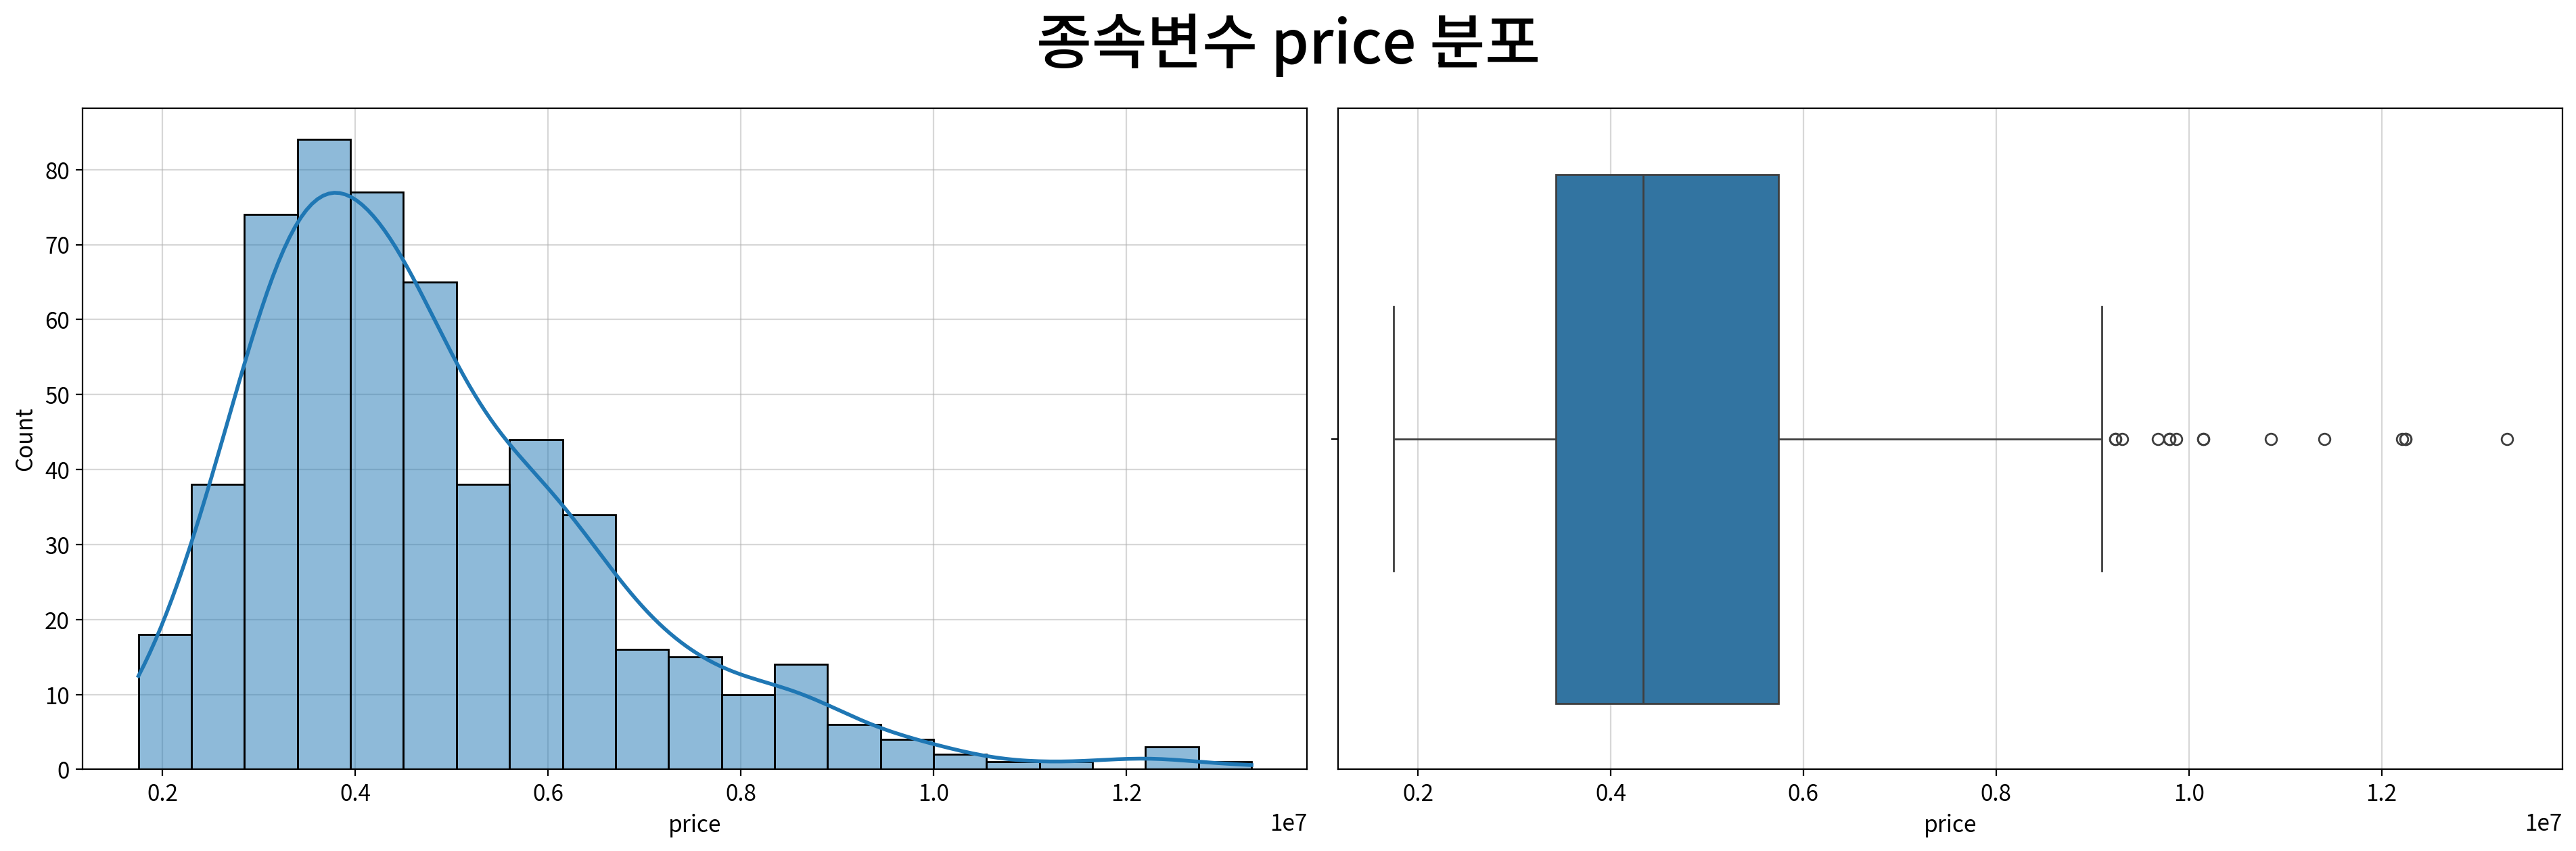

,price
count,545.000
mean,4766729.248
std,1870439.616
min,1750000.000
25%,3430000.000
50%,4340000.000
75%,5740000.000
max,13300000.000
rel_diff,0.098
rdiff_flag,similar


In [7]:
# 1행 2열 서브플롯 구성
# -> 그래프 크기는 서브플롯 중 하나의 크기(전체 크기는 가로 960 x 2가 됨)
fig, ax = my_plot.init(rows=1, cols=2, 
            title=f"종속변수 {target} 분포", width=960, height=640)
my_plot.histplot(data=df, x=target, kde=True, ax=ax[0])
my_plot.boxplot(data=df, x=target, ax=ax[1])
my_plot.show()

# 연속형 변수 기술통계량에서 종속변수에 대한 부분만 추출
num_desc[num_desc.index == target].T

#### 💡 인사이트

| 점검 항목 | `price` 관찰값 |
|---|---|
| 분포 모양 | 왜도 **+1.212 (우편향)**, 첨도 1.960 (뾰족함) |
| 봉우리 수 | 단봉 |
| 이상치 | 상단 15건(2.8%) / 하단 0건 |
| 이산점(군집) | 없음 |

- **로그 변환 후 모델 투입** (`log_need = log1p`)

### 2. 연속형 독립변수에 대한 단변량 분석

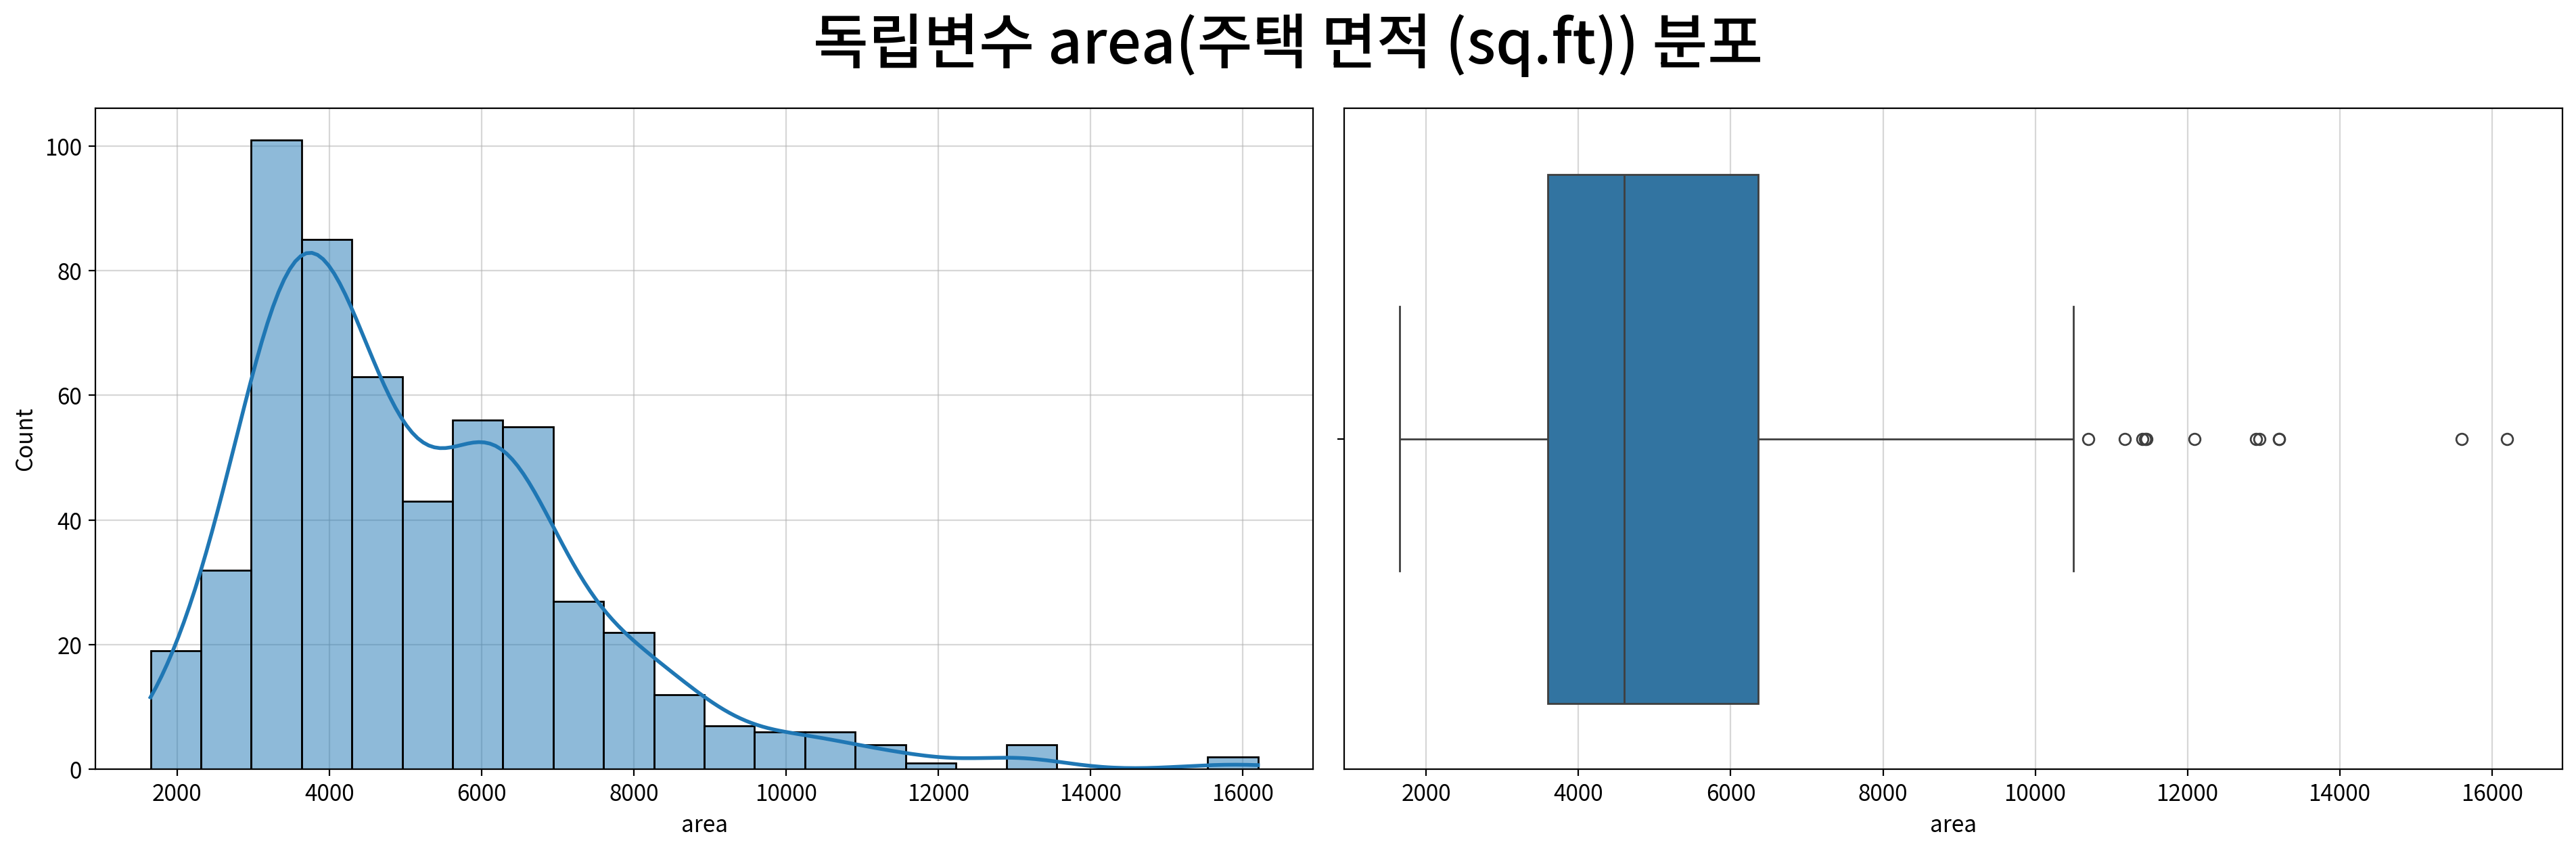

,area
count,545.000
mean,5150.541
std,2170.141
min,1650.000
25%,3600.000
50%,4600.000
75%,6360.000
max,16200.000
rel_diff,0.120
rdiff_flag,diff


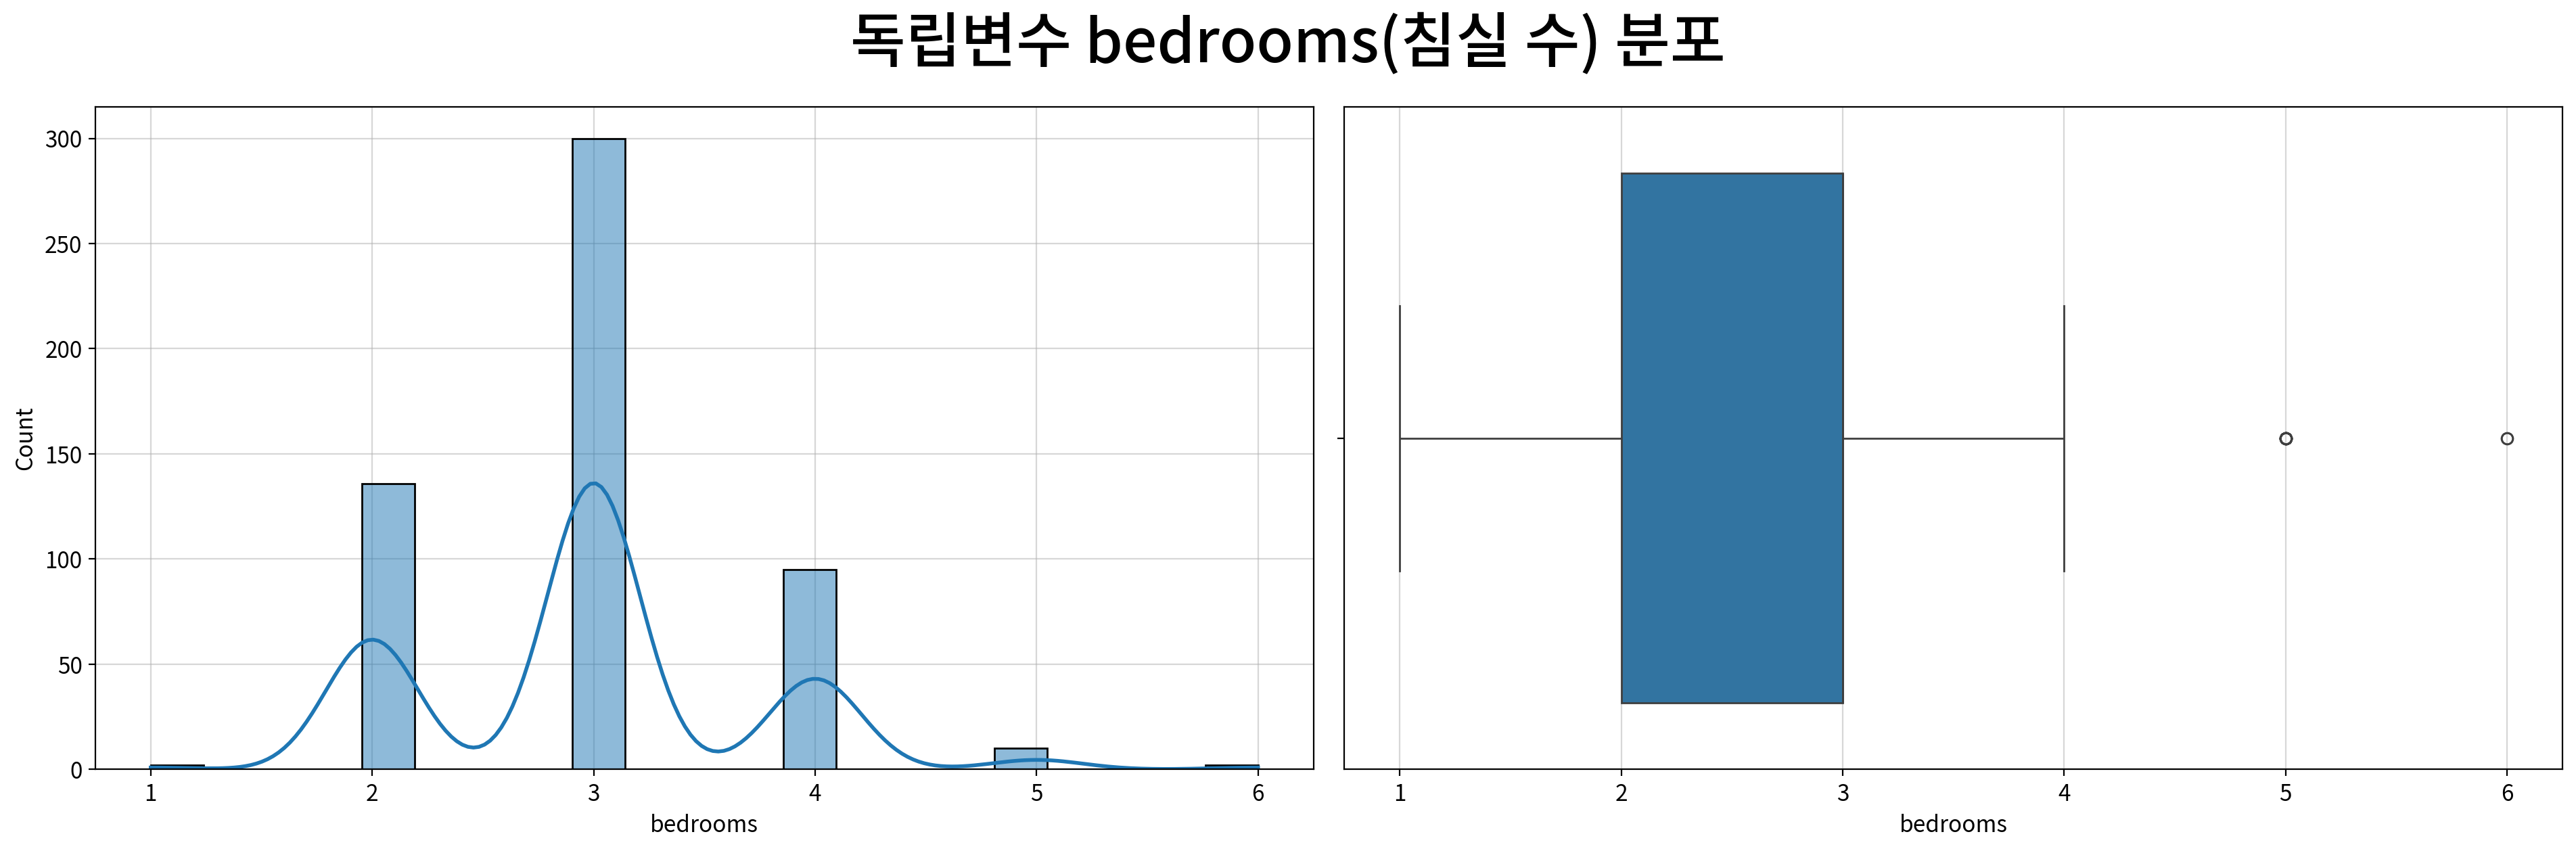

,bedrooms
count,545.000
mean,2.965
std,0.738
min,1.000
25%,2.000
50%,3.000
75%,3.000
max,6.000
rel_diff,0.012
rdiff_flag,similar


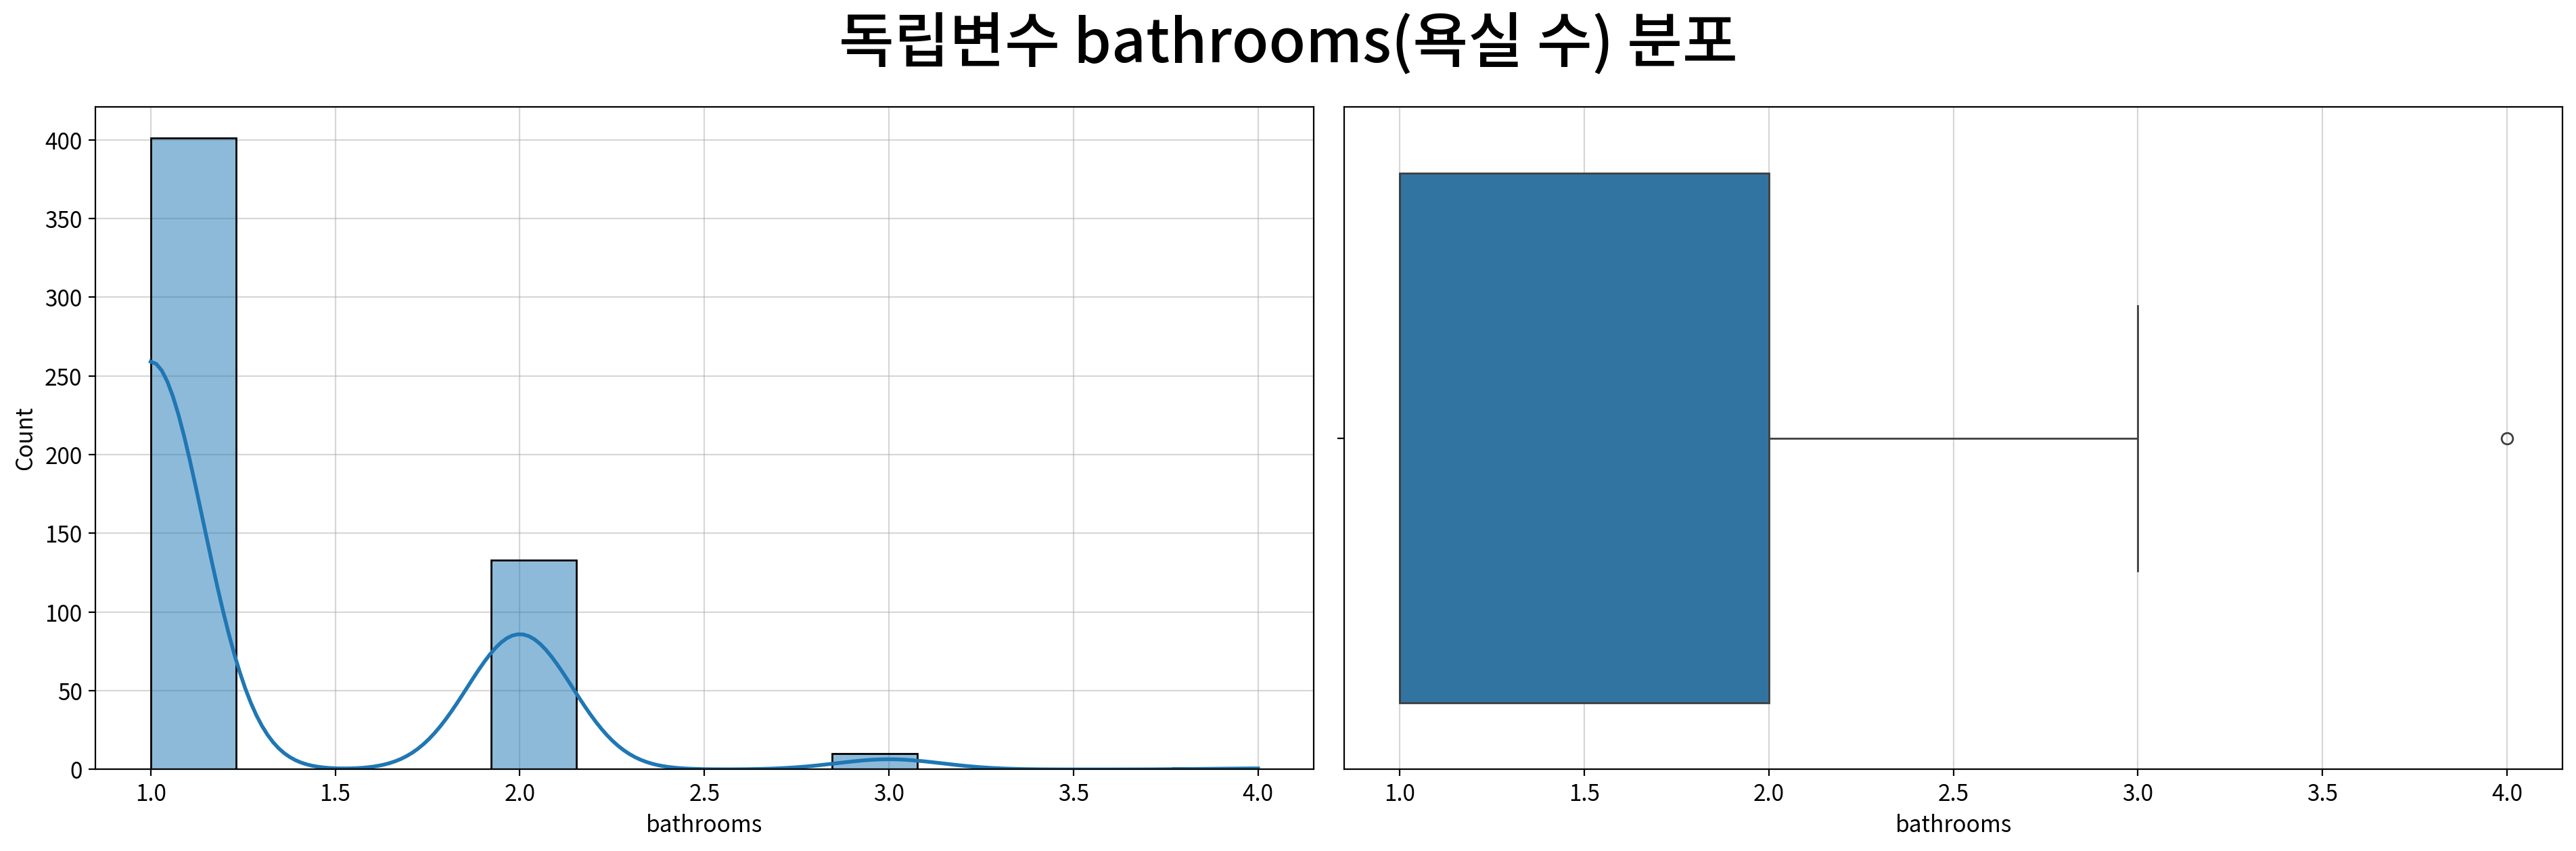

,bathrooms
count,545.000
mean,1.286
std,0.502
min,1.000
25%,1.000
50%,1.000
75%,2.000
max,4.000
rel_diff,0.286
rdiff_flag,diff


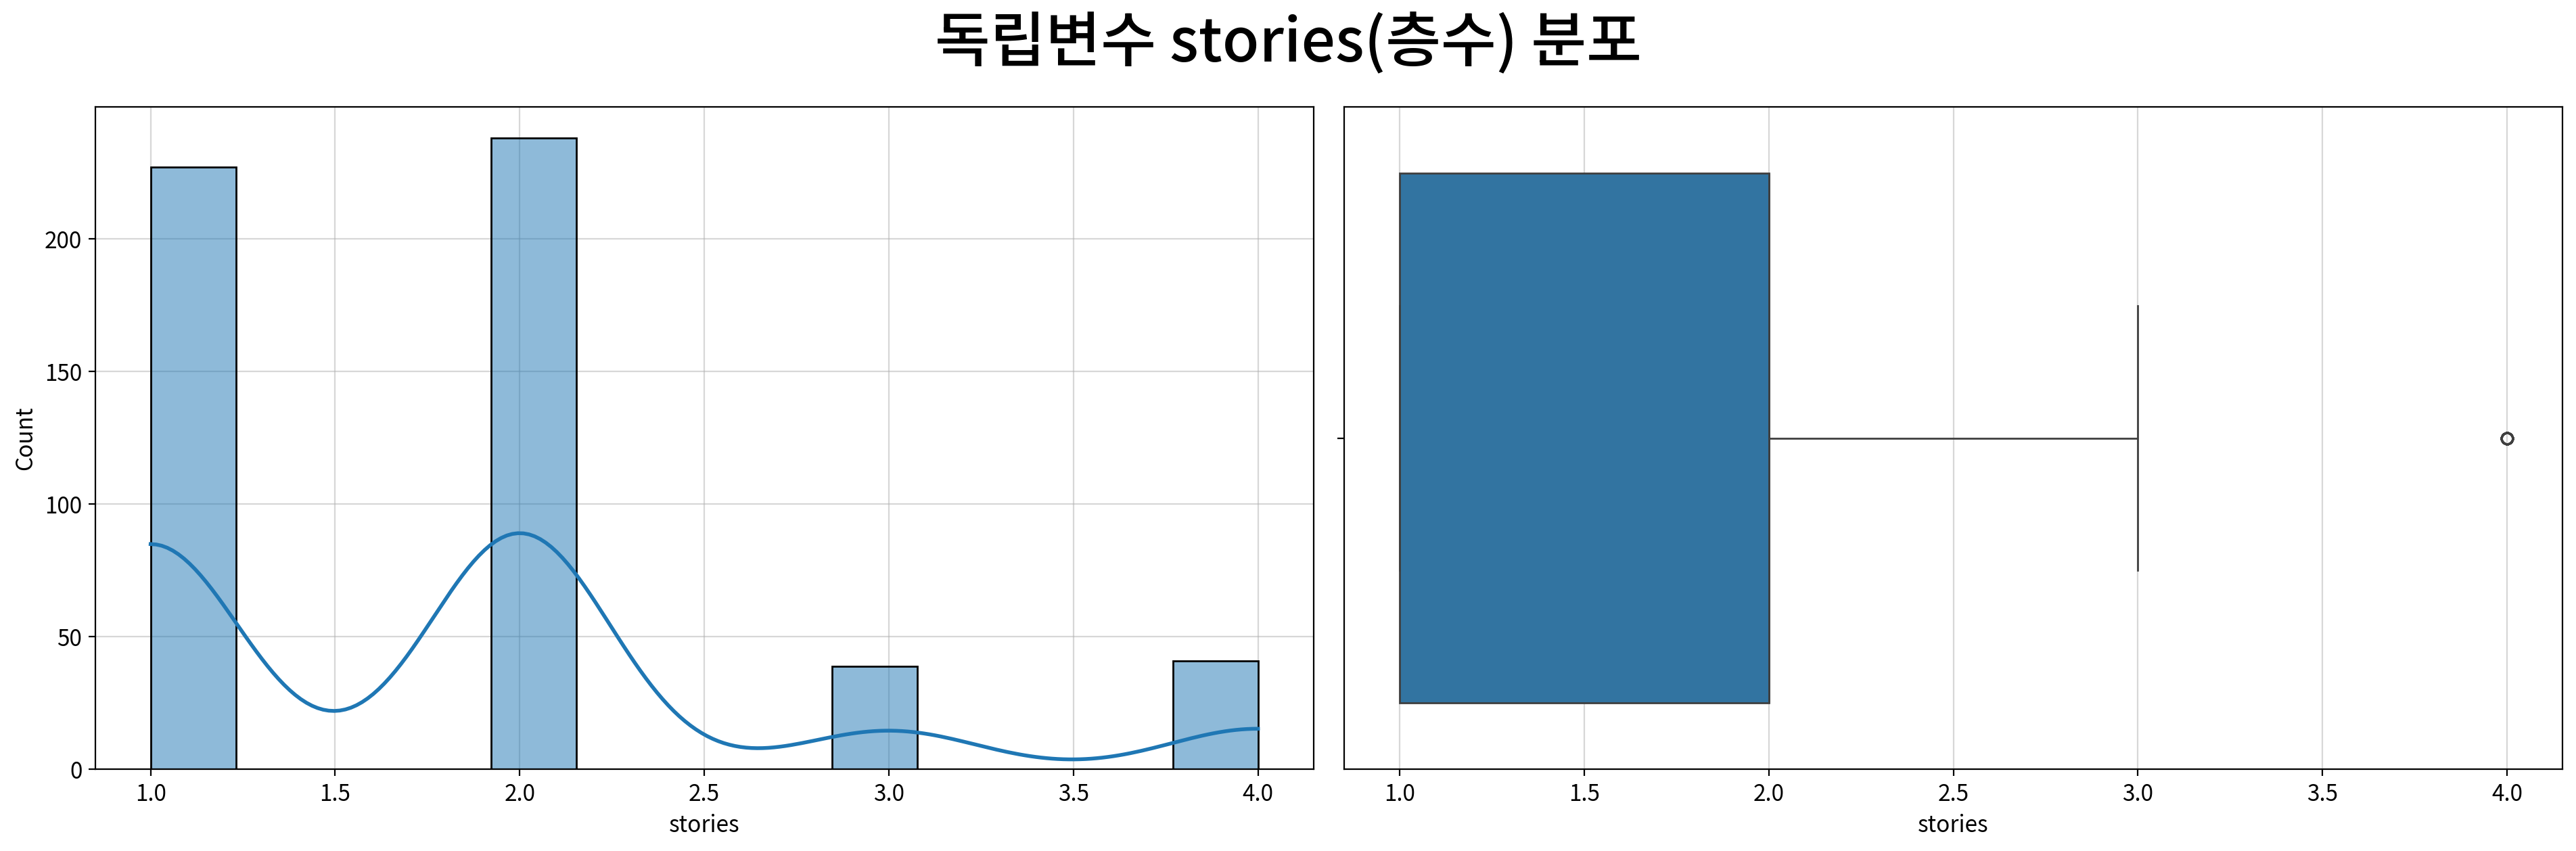

,stories
count,545.000
mean,1.806
std,0.867
min,1.000
25%,1.000
50%,2.000
75%,2.000
max,4.000
rel_diff,0.097
rdiff_flag,similar


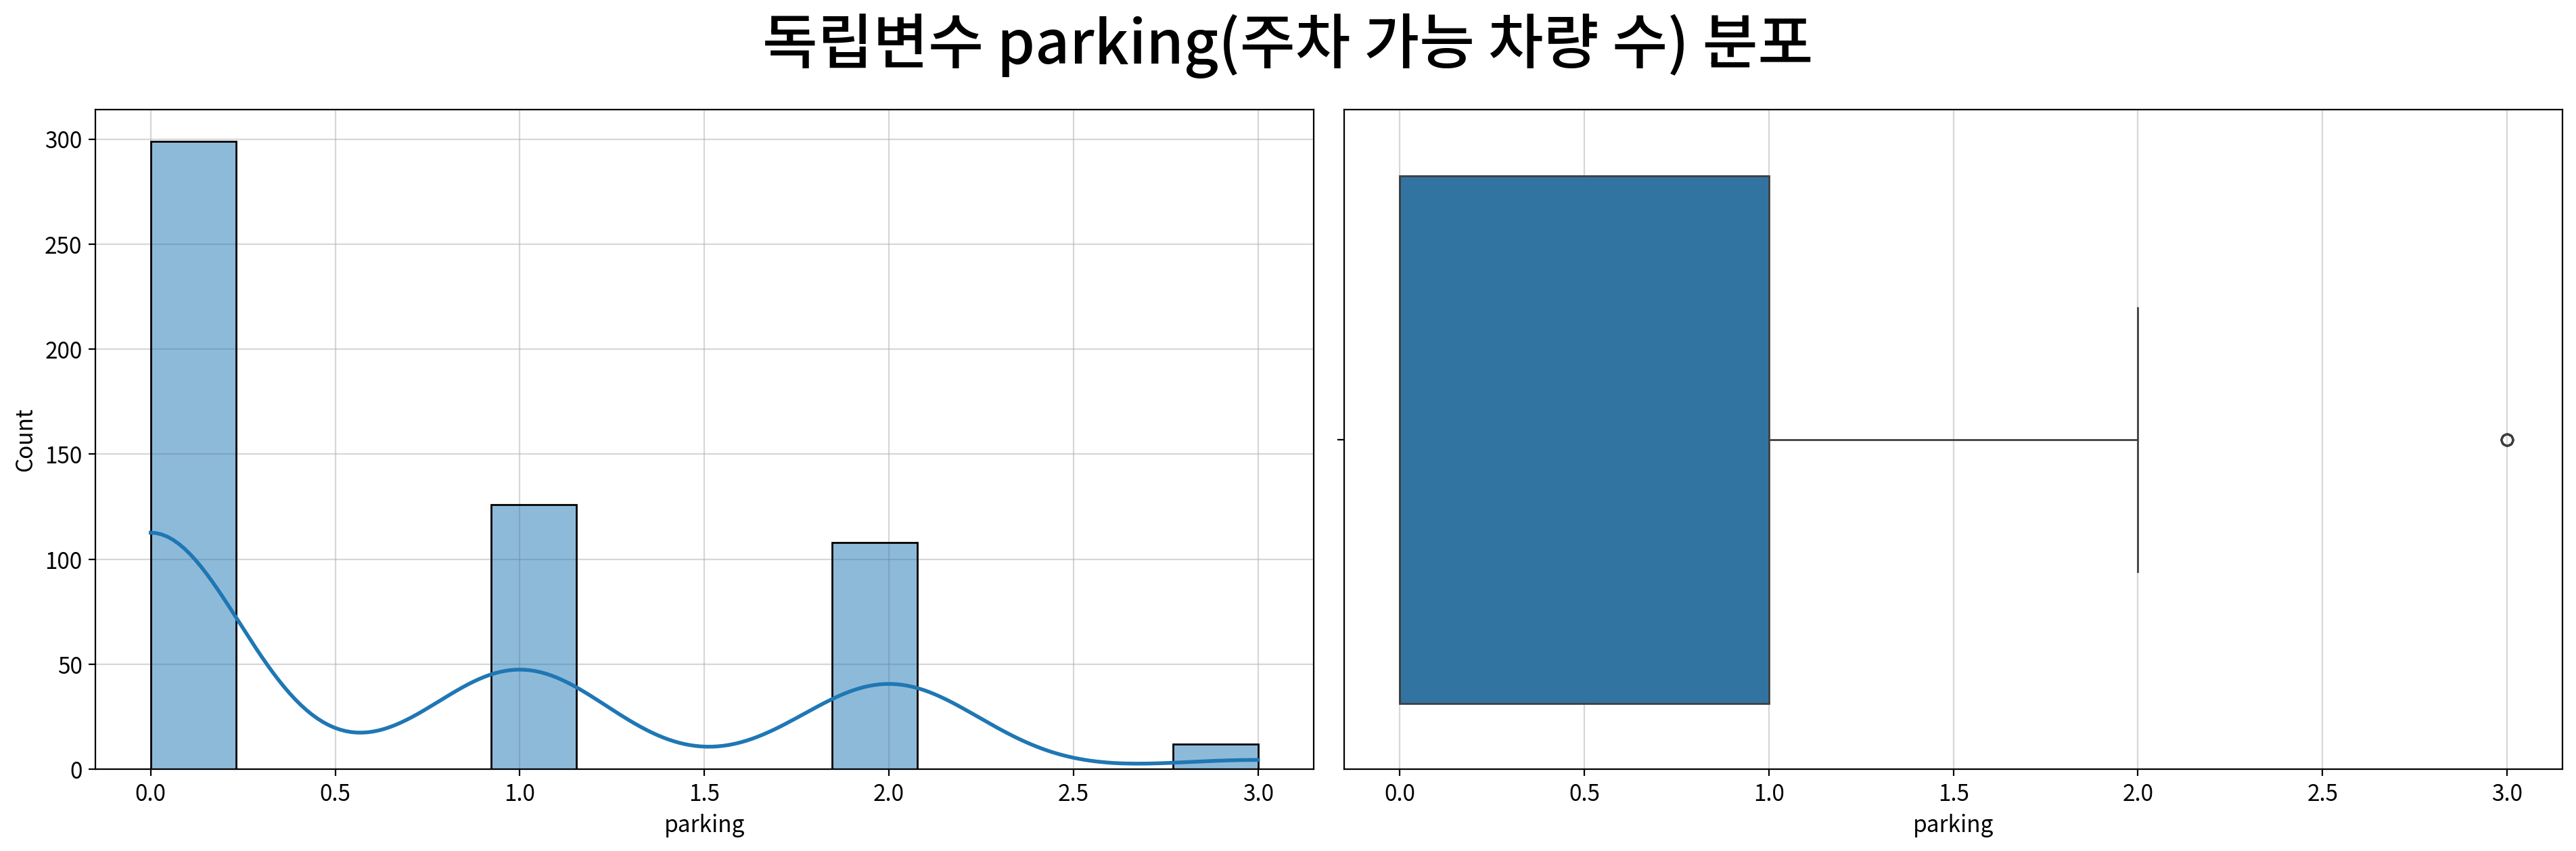

,parking
count,545.000
mean,0.694
std,0.862
min,0.000
25%,0.000
50%,0.000
75%,1.000
max,3.000
rel_diff,inf
rdiff_flag,large_diff


In [8]:
for f in continuous_cols:
    fig, ax = my_plot.init(rows=1, cols=2, width=960, height=640,
                title=f"독립변수 {f}({column_means[f]}) 분포")
    my_plot.histplot(data=df, x=f, kde=True, ax=ax[0])
    my_plot.boxplot(data=df, x=f, ax=ax[1])
    my_plot.show()

    display(num_desc[num_desc.index == f].T)

#### 💡 인사이트

| 변수 | 분포 모양(왜도) | 봉우리 수 | 이상치 | 이산점(군집) | 판단·조치 |
|---|---|---|---|---|---|
| `area` | 우편향 (+1.32) | 다봉 | 12건 (2.2%) | 없음 (연속) | **로그 변환**(log1p) |
| `bedrooms` | 대칭 (+0.50) | 단봉 (3개 최빈) | 12건 (2.2%) | **정수 1~6** | 변환 불필요 |
| `bathrooms` | 강한 우편향 (+1.59) | 단봉 (1개 최빈) | 1건 (0.2%) | **정수 1~4** (1~2가 98%) | 변환 불필요(이산) |
| `stories` | 우편향 (+1.08) | 단봉 (1~2층 집중) | **41건 (7.5%)** | **정수 1~4** | 변환 불필요(이산) |
| `parking` | 우편향 (+0.84) | 단봉 (0대 최빈) | 12건 (2.2%) | **정수 0~3** | 변환 불필요 |

- **`area`만 실질적인 연속형**이고, 나머지 4종은 **범위가 좁은 정수 이산값**이다. 이상치로 잡힌 건수도 대부분 "값이 큰 소수 범주"일 뿐 오류값이 아니다.
- `bathrooms`·`stories`는 왜도상 `log_need = log1p`로 표시되지만 **이산값 4단계에 불과해 변환 실익이 없다.**

### 3. 명목형 독립변수에 대한 단변량 분석

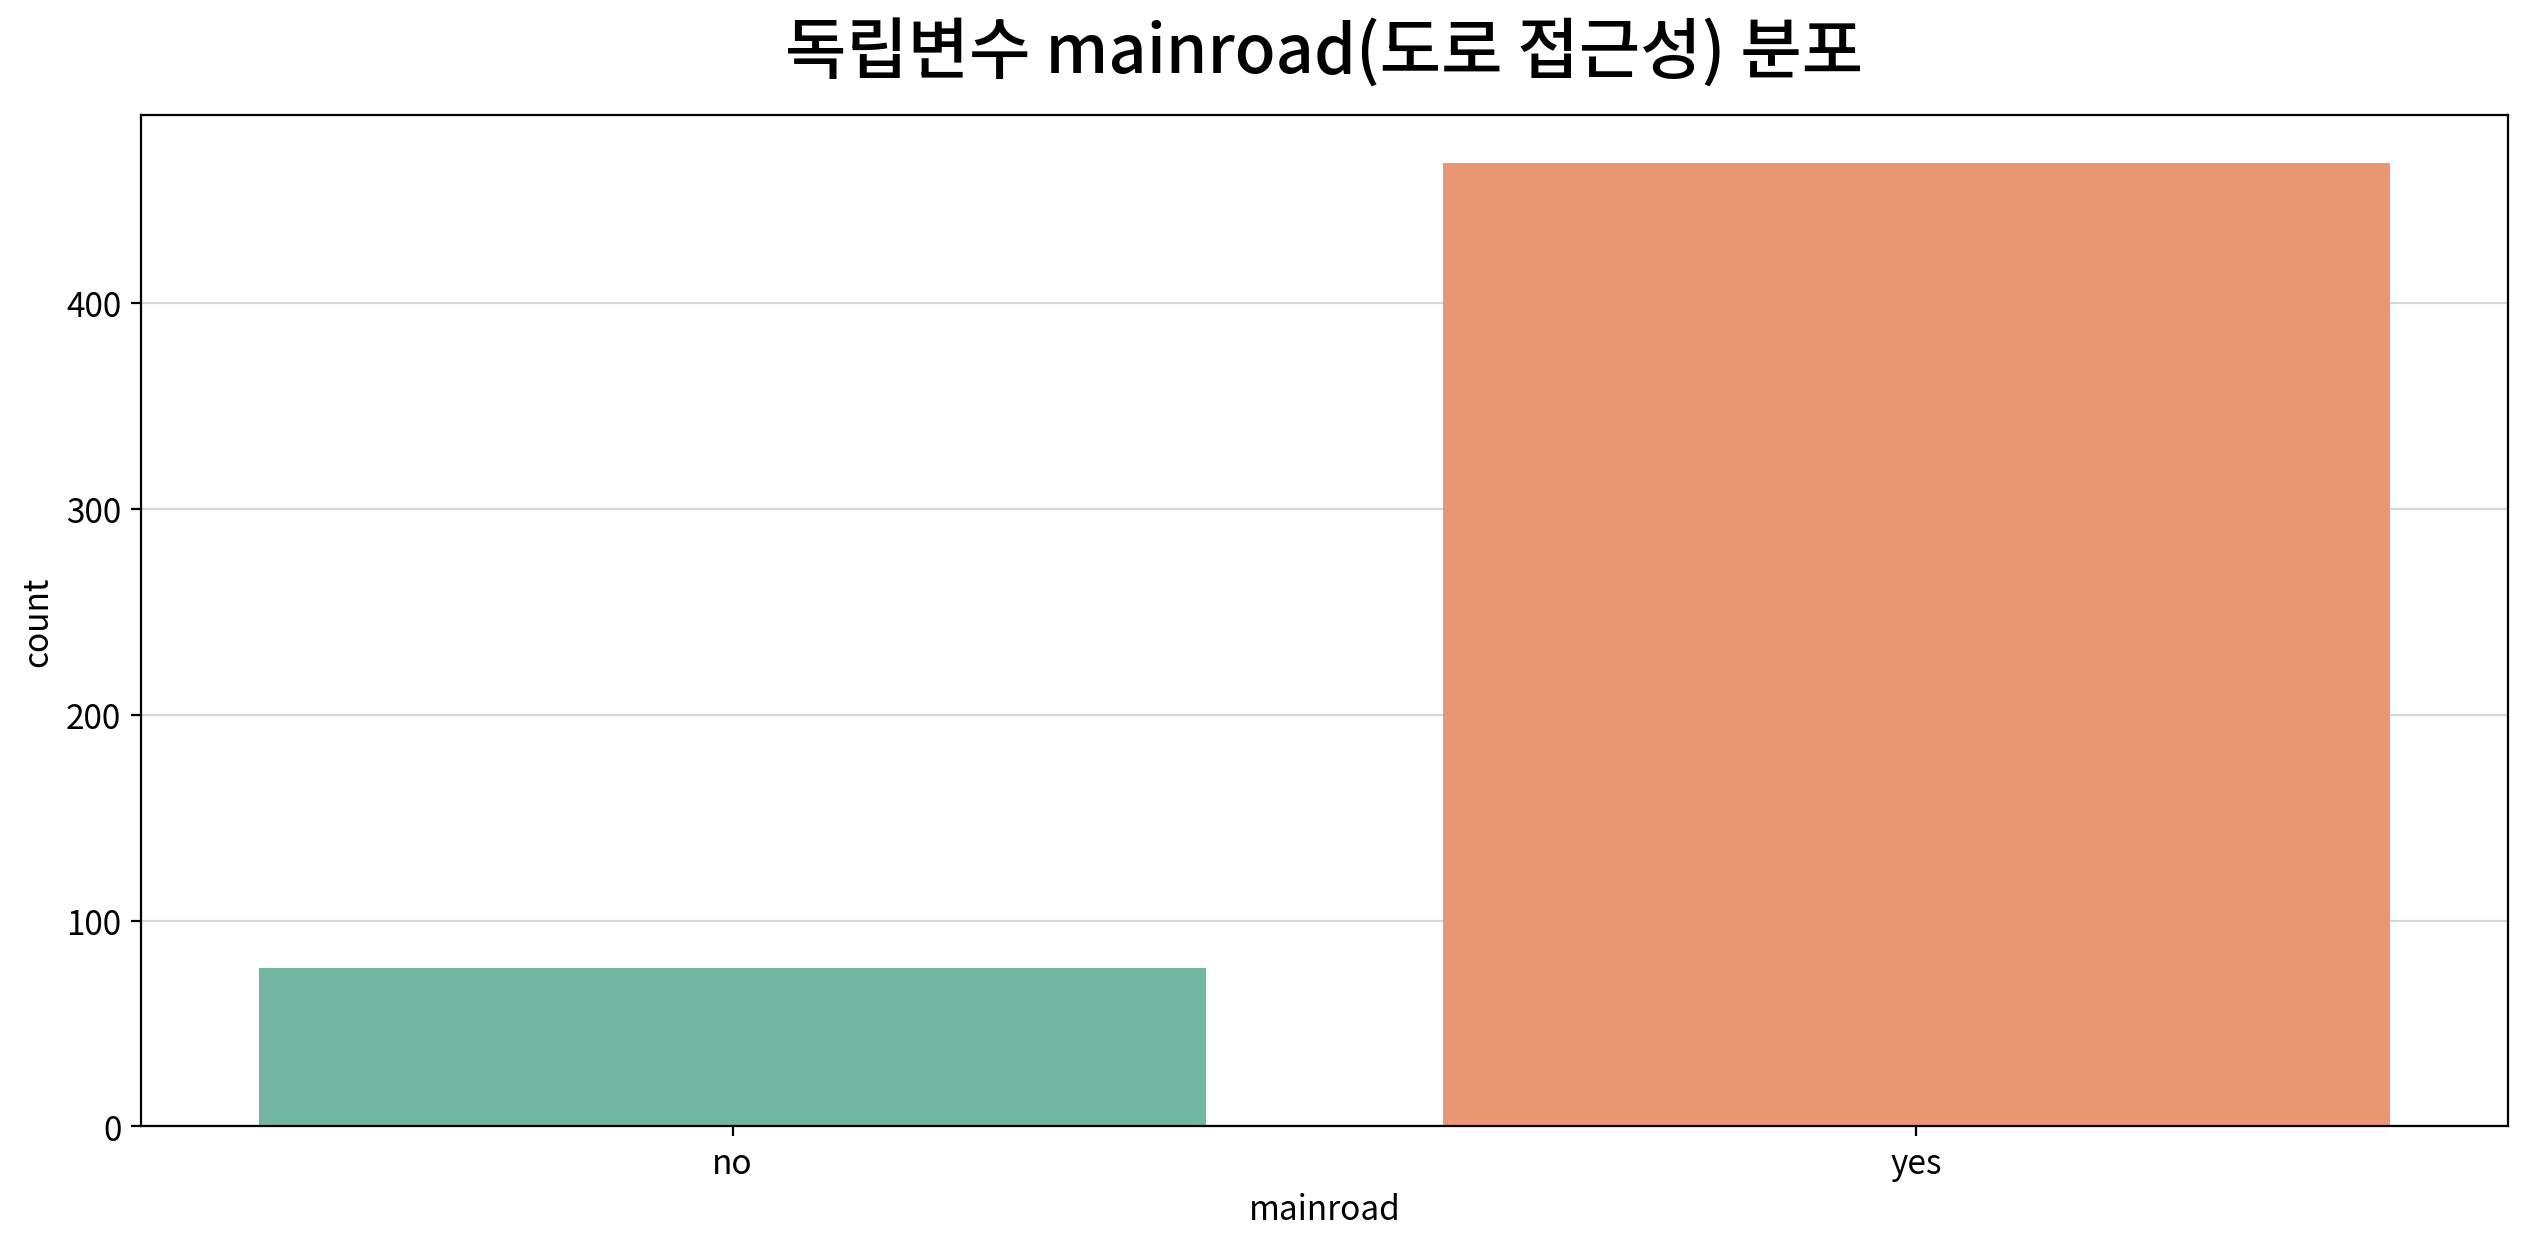

,count,unique,top,freq
mainroad,545,2,yes,468


,빈도,비율
mainroad,,
yes,468,0.859
no,77,0.141


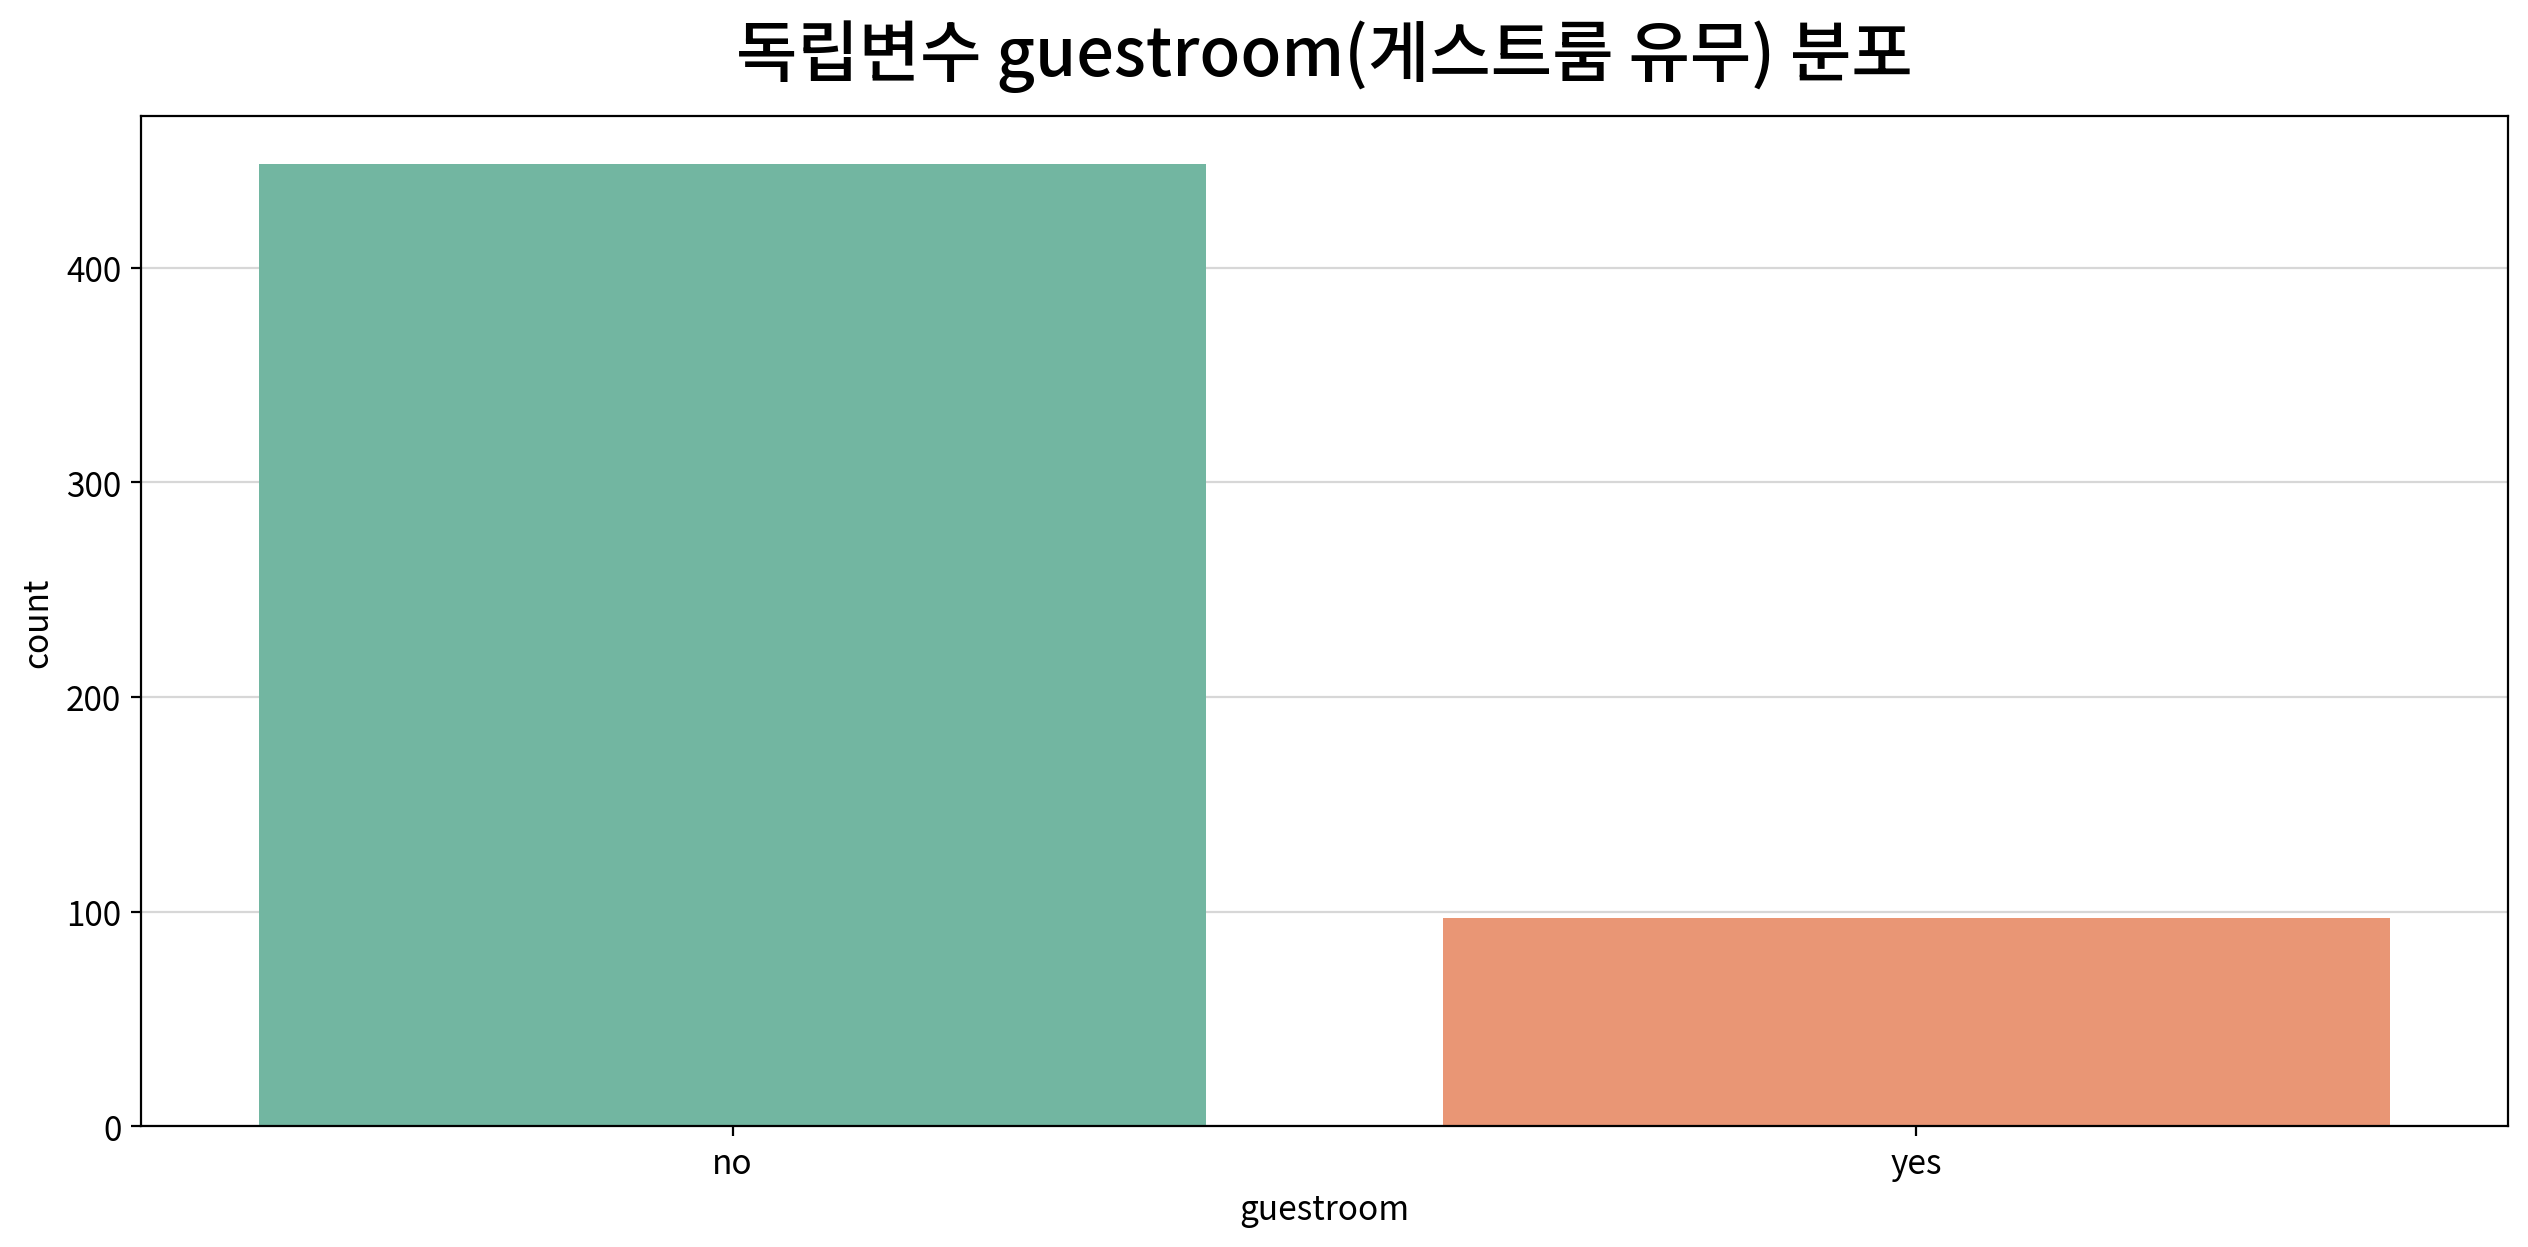

,count,unique,top,freq
guestroom,545,2,no,448


,빈도,비율
guestroom,,
no,448,0.822
yes,97,0.178


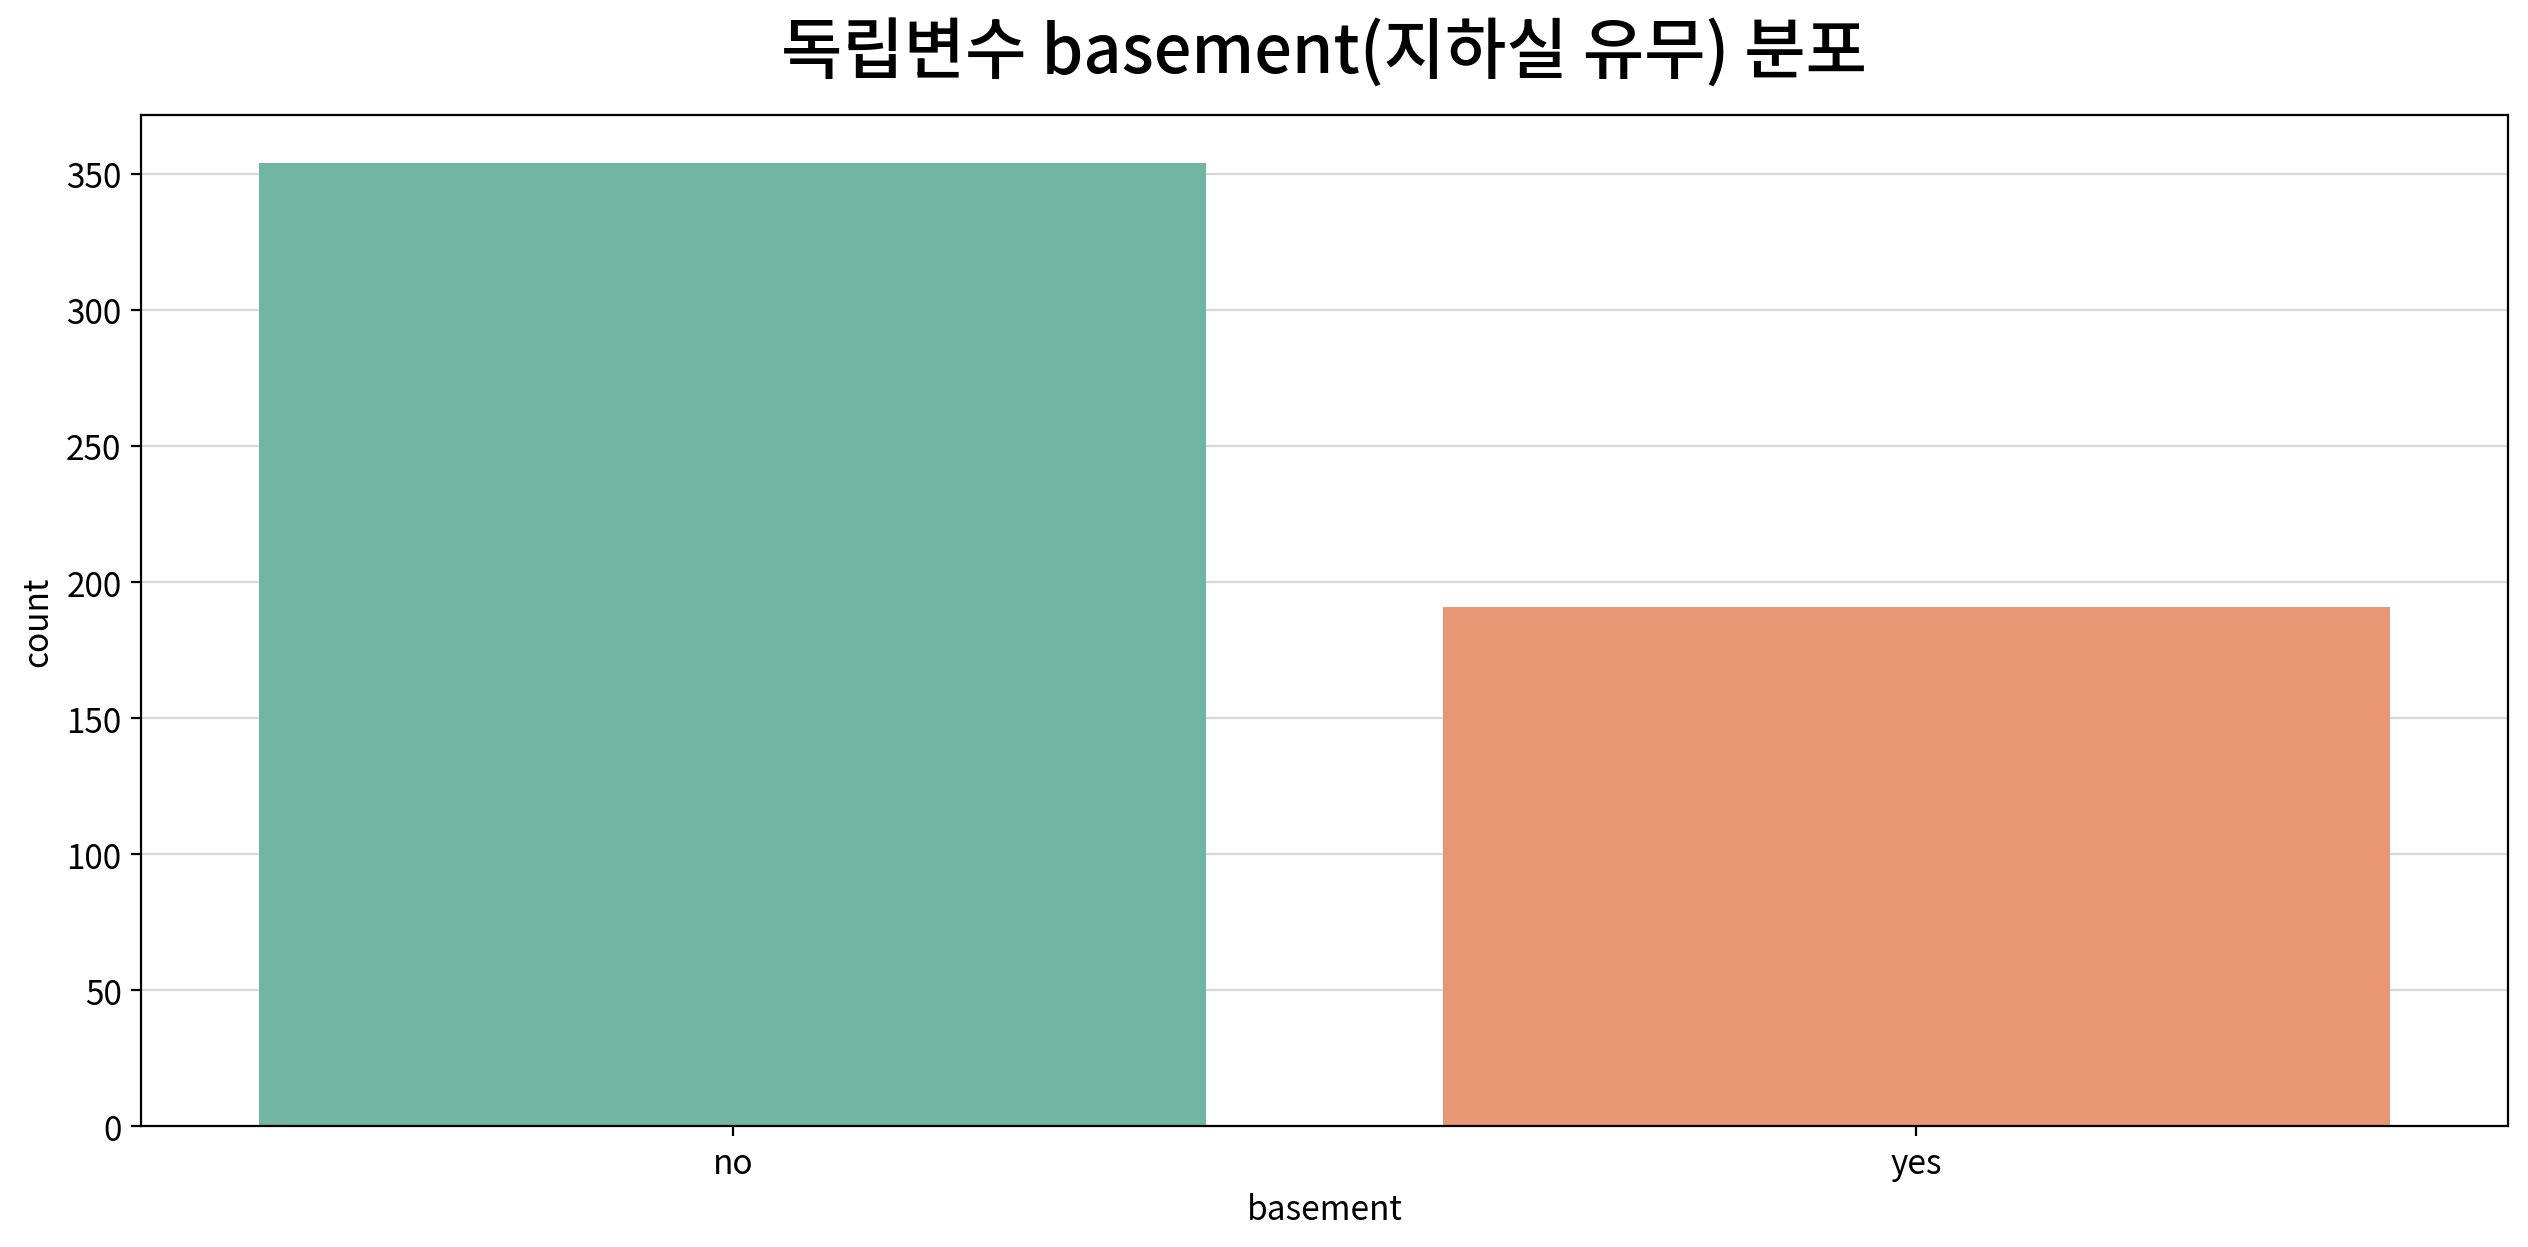

,count,unique,top,freq
basement,545,2,no,354


,빈도,비율
basement,,
no,354,0.650
yes,191,0.350


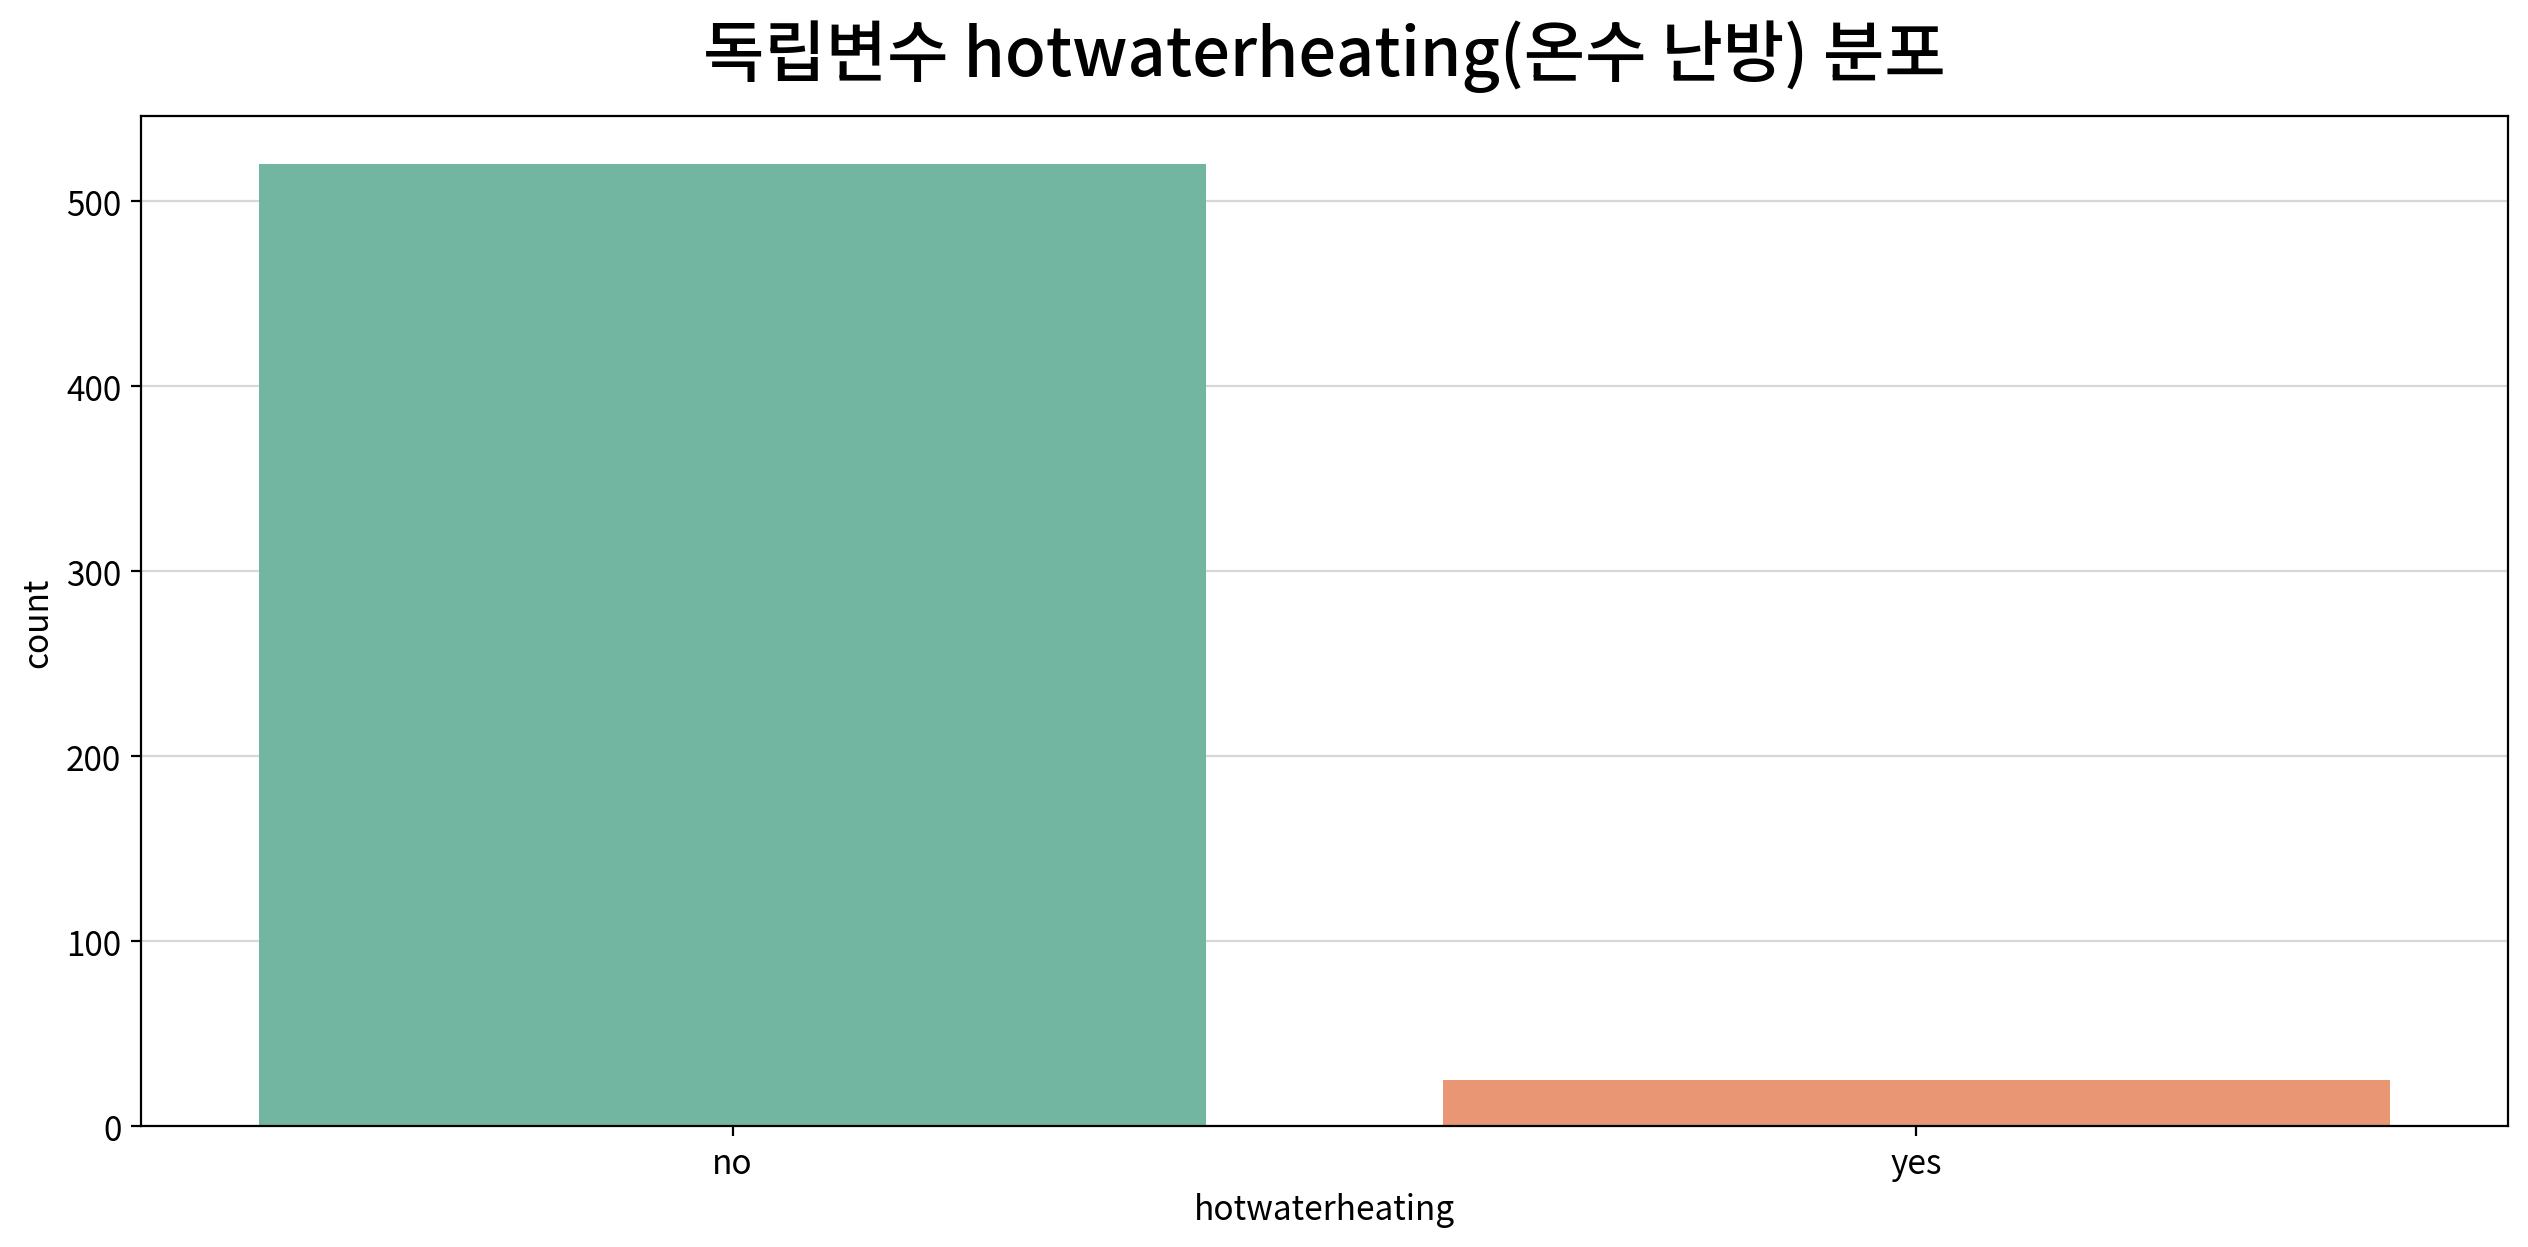

,count,unique,top,freq
hotwaterheating,545,2,no,520


,빈도,비율
hotwaterheating,,
no,520,0.954
yes,25,0.046


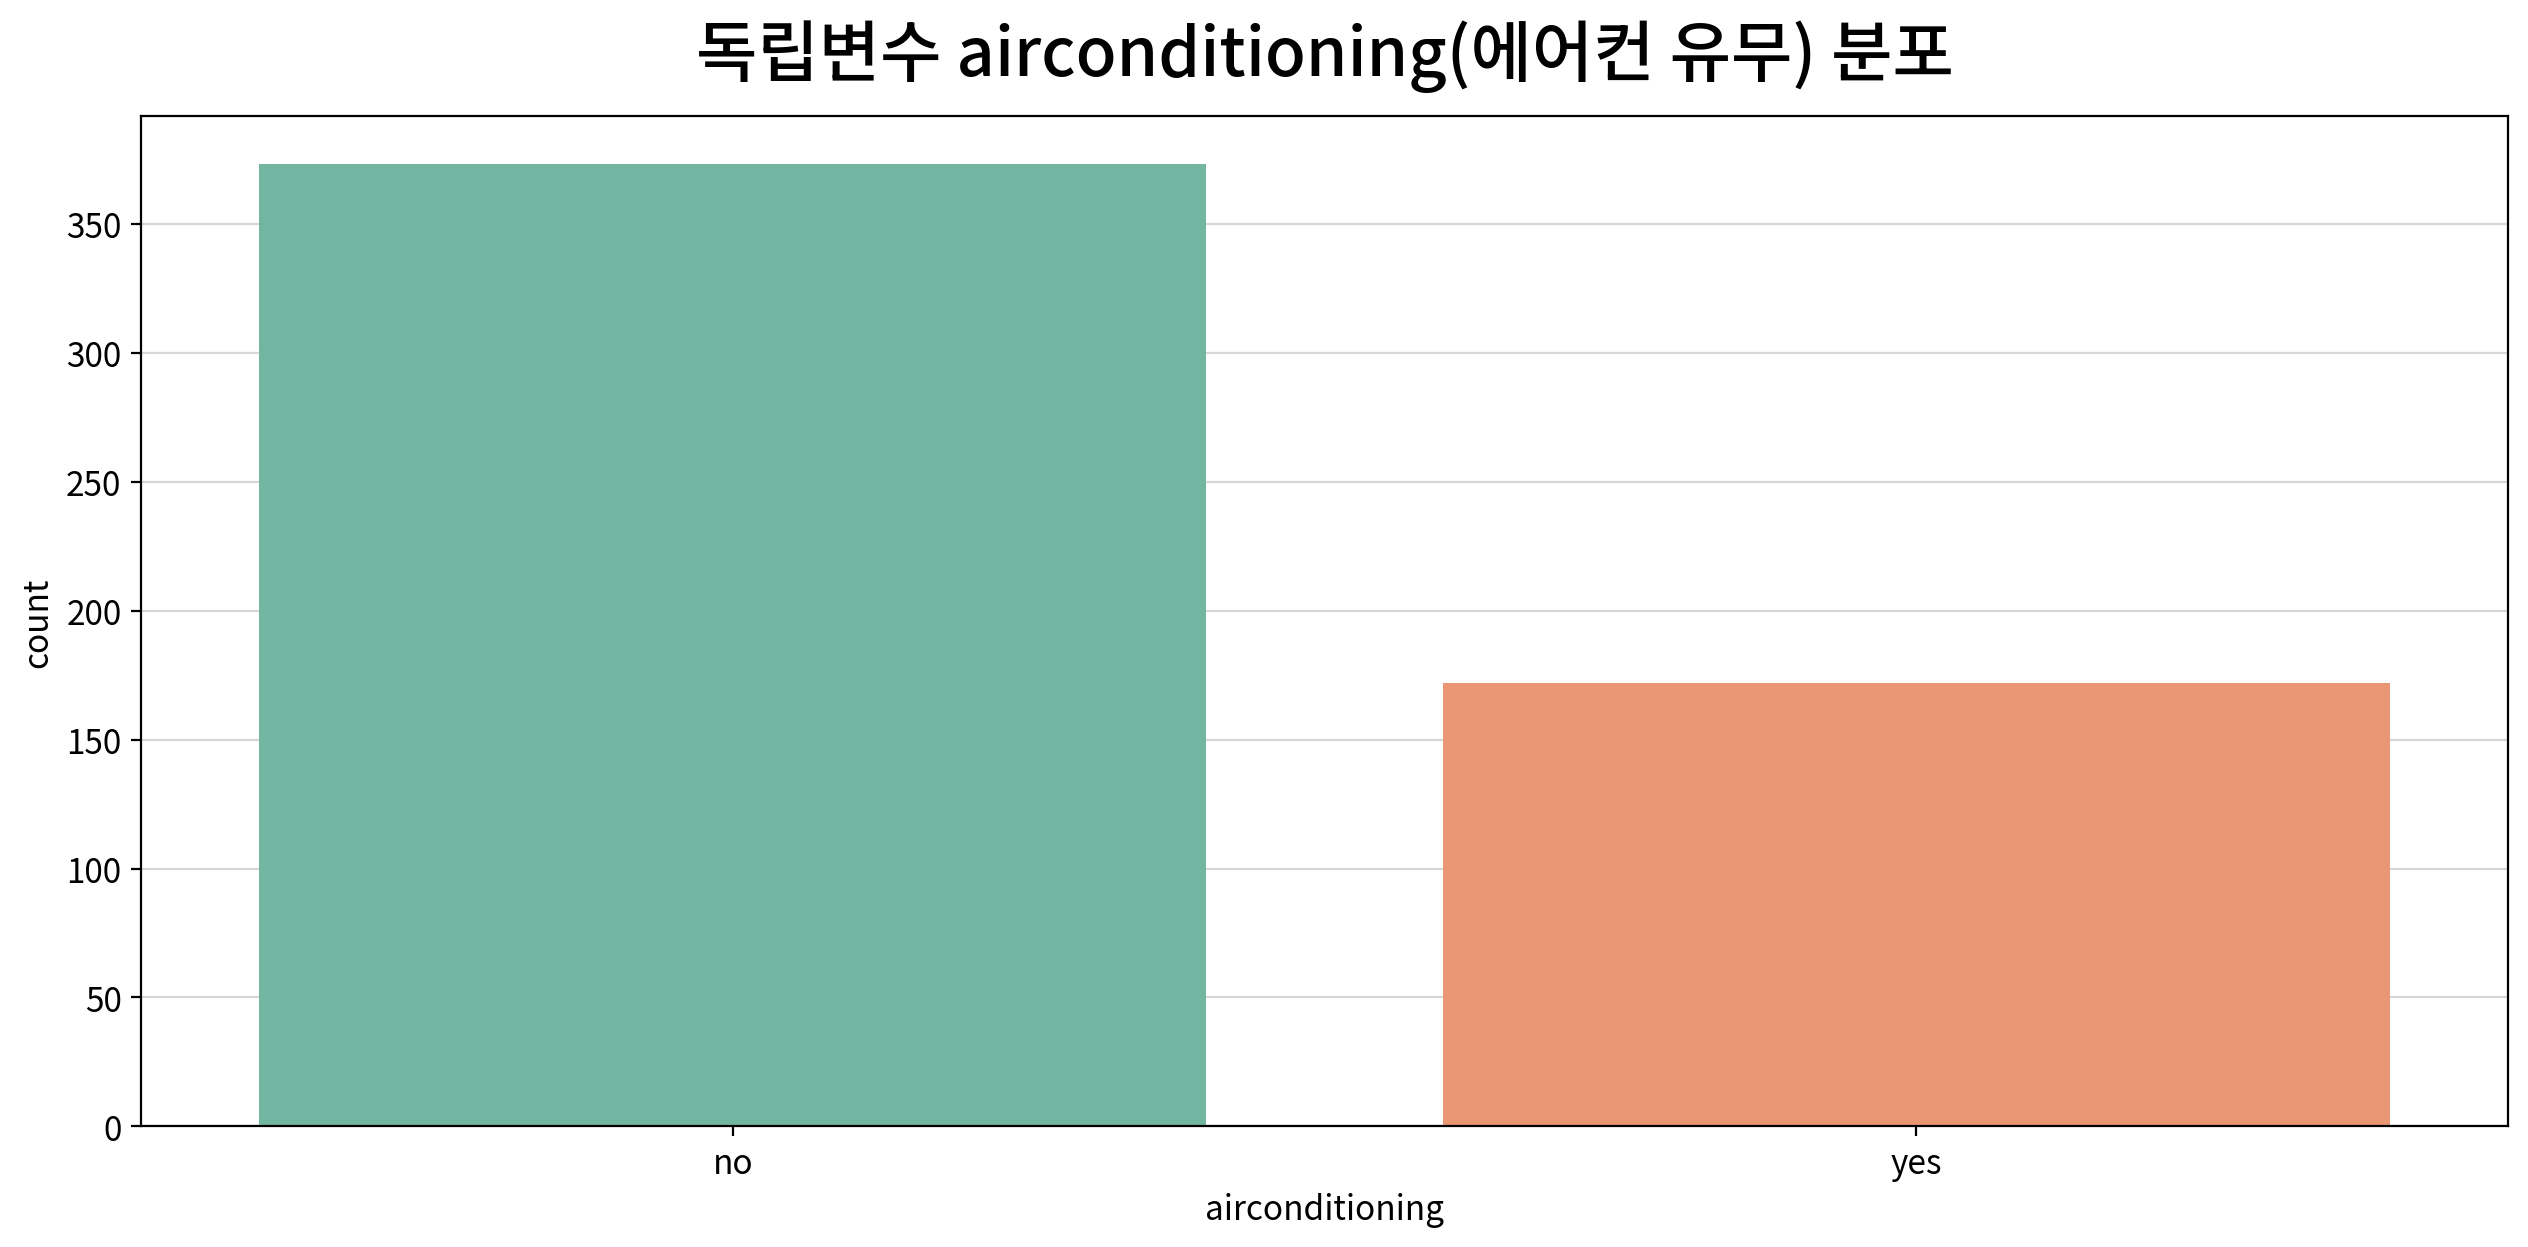

,count,unique,top,freq
airconditioning,545,2,no,373


,빈도,비율
airconditioning,,
no,373,0.684
yes,172,0.316


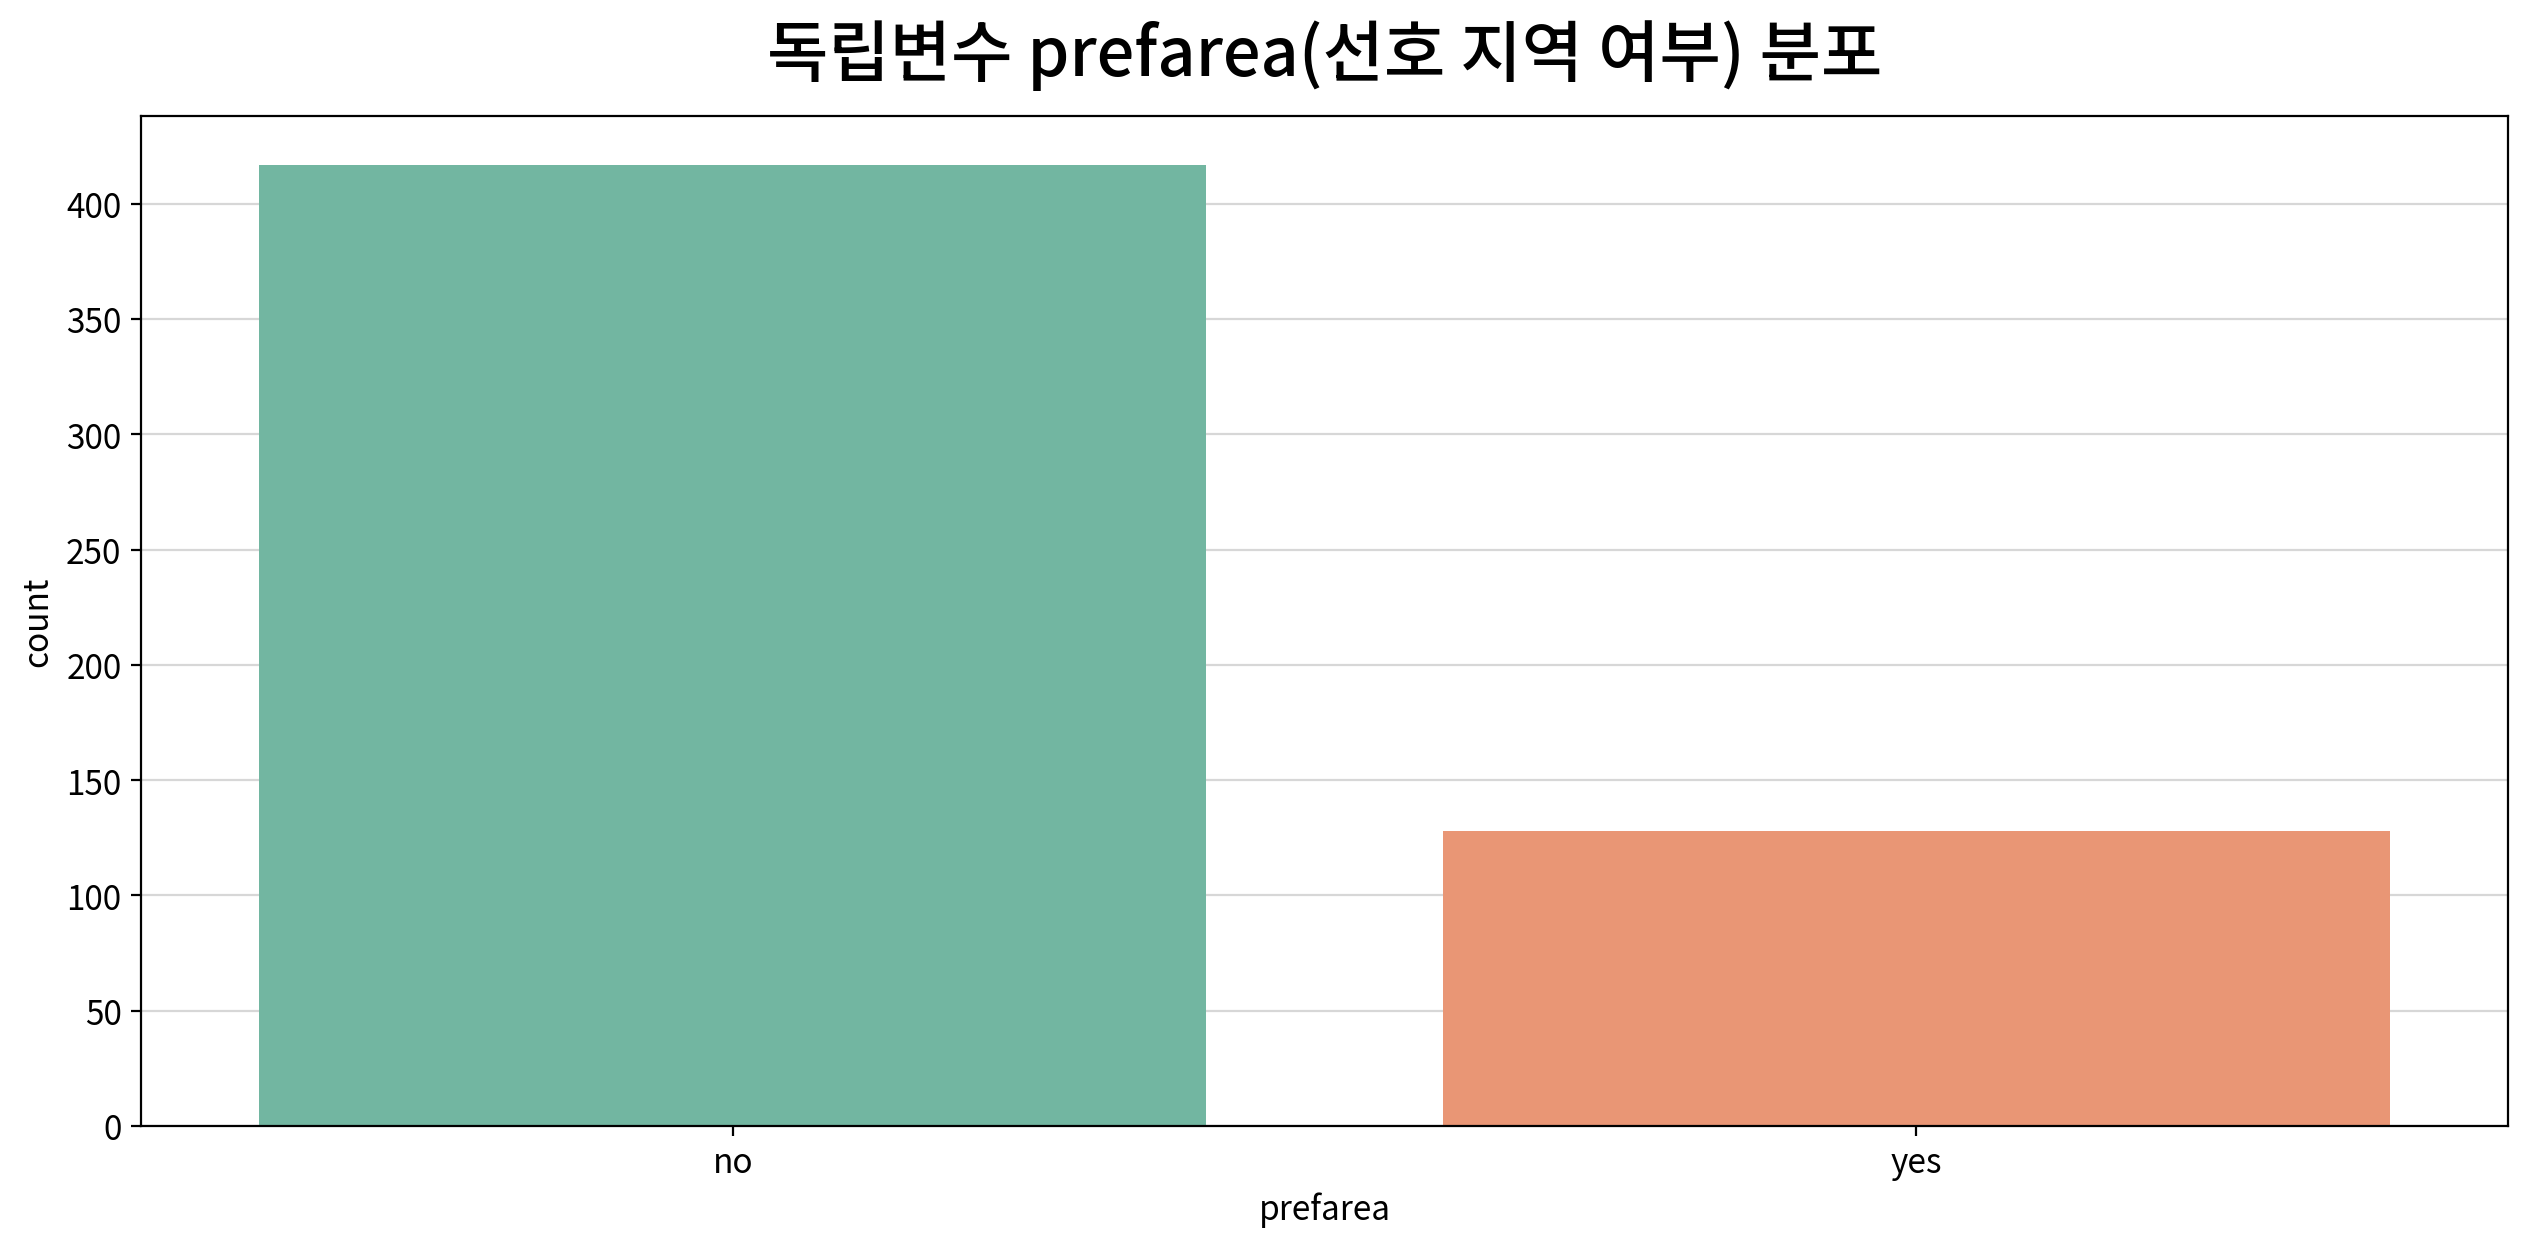

,count,unique,top,freq
prefarea,545,2,no,417


,빈도,비율
prefarea,,
no,417,0.765
yes,128,0.235


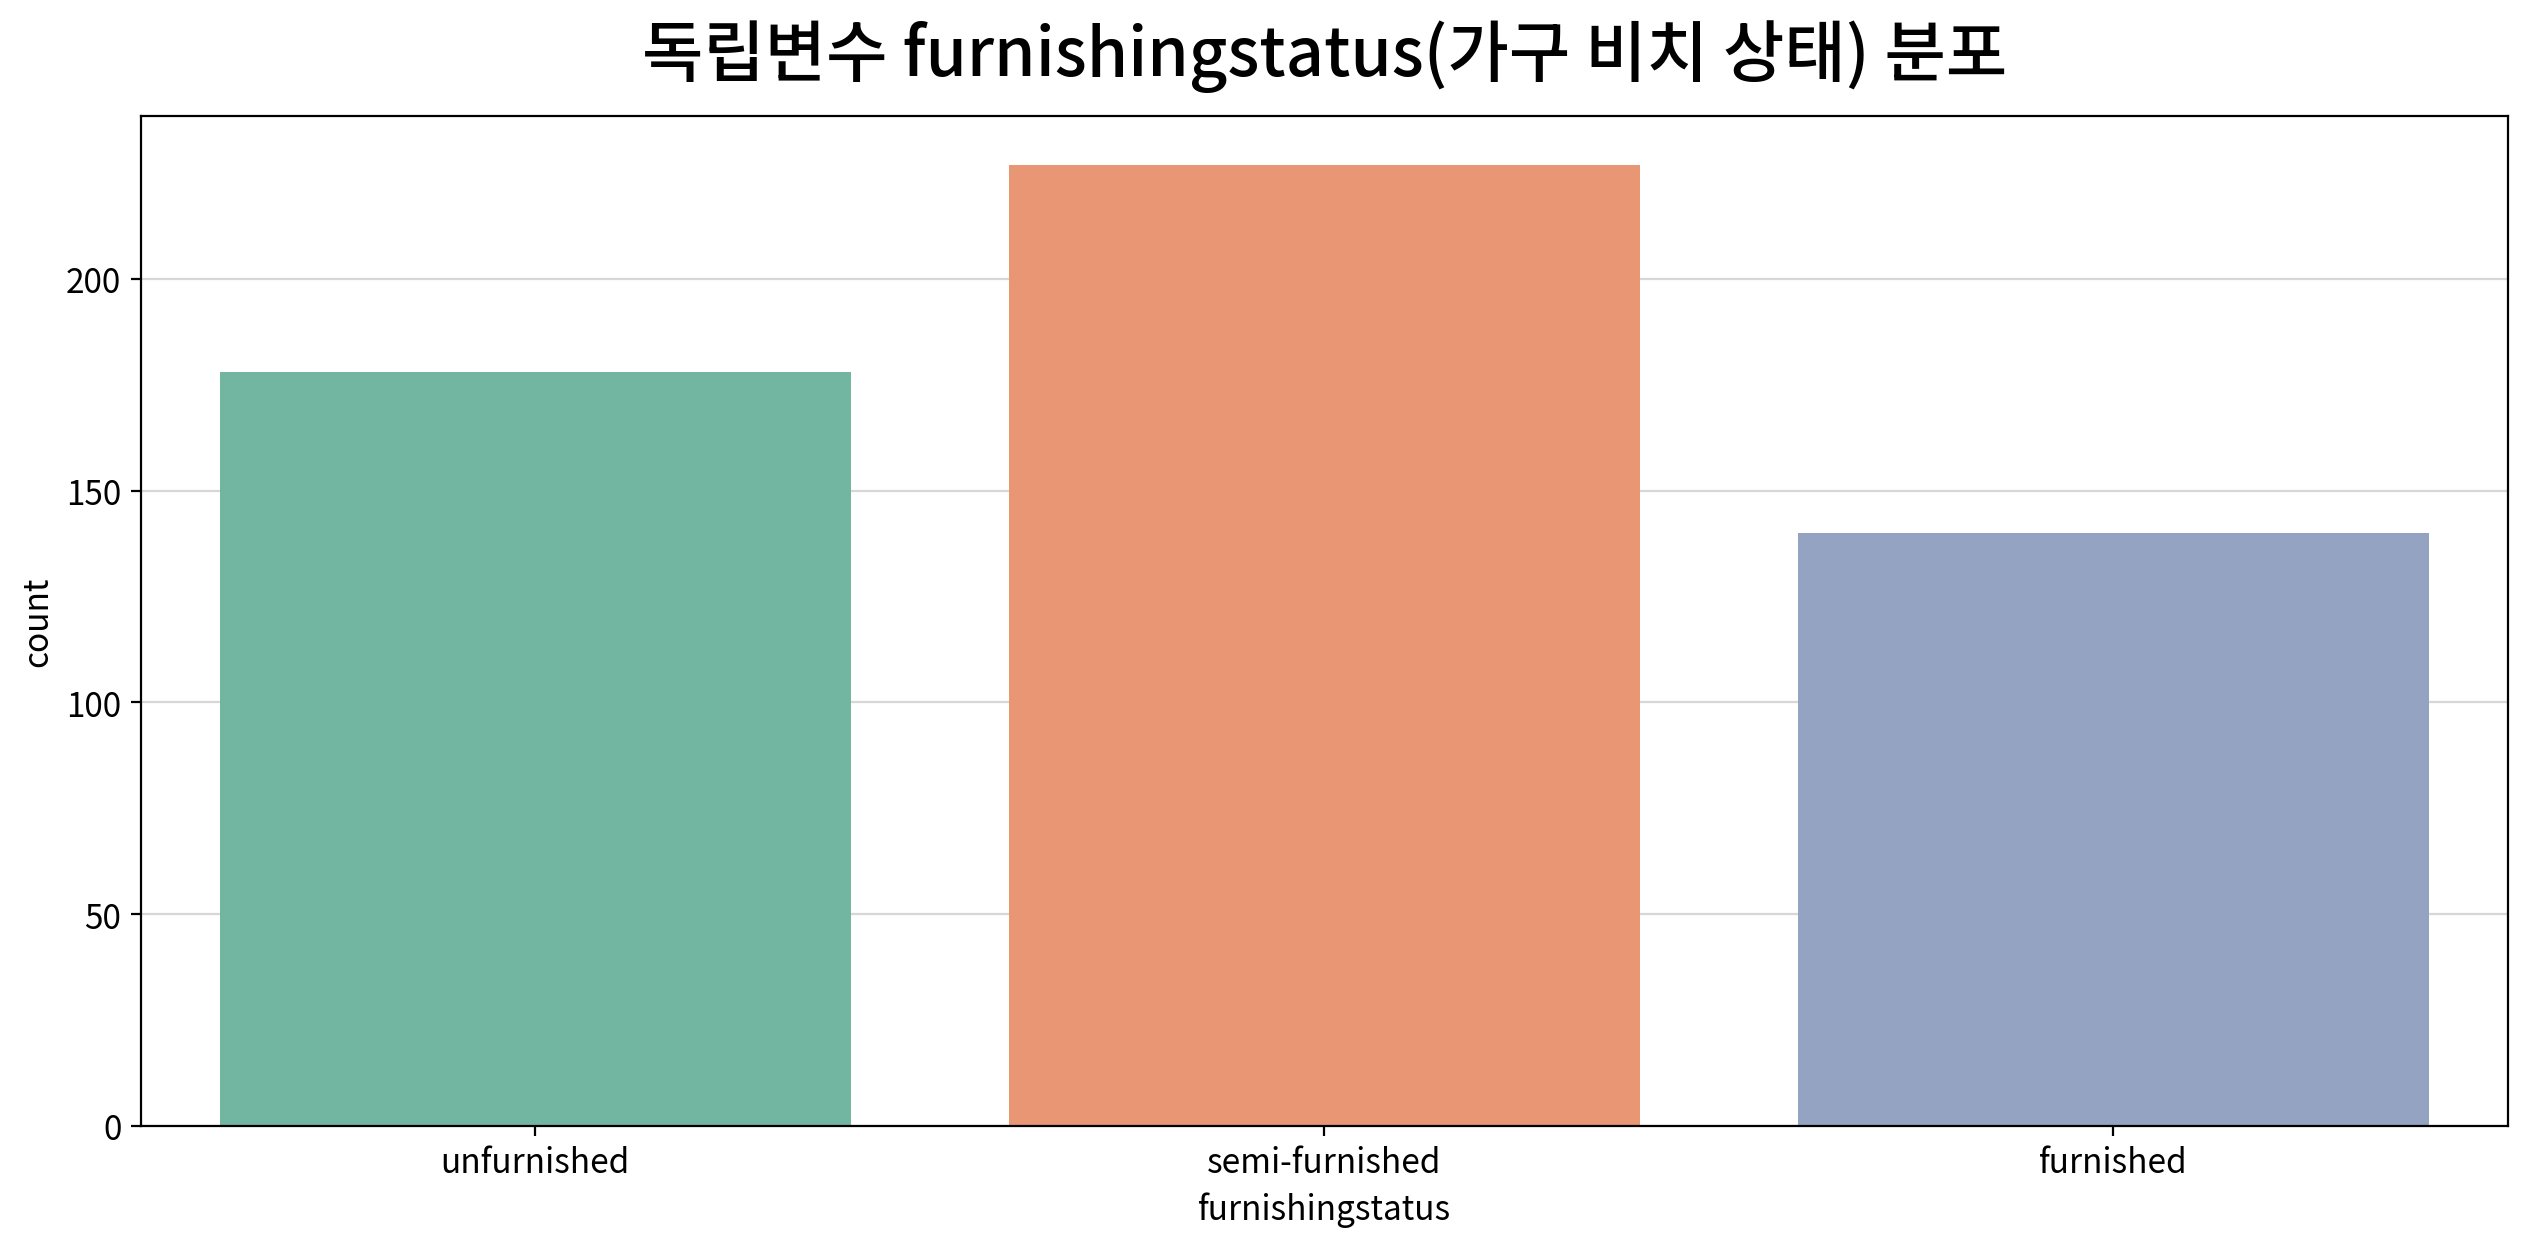

,count,unique,top,freq
furnishingstatus,545,3,semi-furnished,227


,빈도,비율
furnishingstatus,,
semi-furnished,227,0.417
unfurnished,178,0.327
furnished,140,0.257


In [9]:
for n in nominal_cols:
    # 명목형 분포는 카운트 플롯으로 처리한다.
    my_plot.countplot(data=df, x=n, hue=n, palette="Set2", title=f"독립변수 {n}({column_means[n]}) 분포")

    # 명목형 기술통계량
    display(cat_desc[[n]].T)

    # 추가적으로 빈도표 생성
    freq = df[n].value_counts().rename("빈도").to_frame()
    # value_counts(normalize=True)
    # --> 전체 고유값의 개수(빈도수) 대신 전체 데이터의 비율을 계산
    freq["비율"] = df[n].value_counts(normalize=True)
    display(freq)

#### 💡 인사이트

| 변수 | 범주 수 | 최빈 범주(비율) | 최소 범주(비율) | 균형 여부 | 판단·조치 |
|---|---|---|---|---|---|
| `mainroad` | 2 | yes 468 (85.9%) | no 77 (14.1%) | 불균형 | 2집단 → **T검정** 대상 |
| `guestroom` | 2 | no 448 (82.2%) | yes 97 (17.8%) | 불균형 | 2집단 → **T검정** 대상 |
| `basement` | 2 | no 354 (65.0%) | yes 191 (35.0%) | 비교적 균형 | 2집단 → **T검정** 대상 |
| `hotwaterheating` | 2 | no 520 (95.4%) | **yes 25 (4.6%)** | **심한 불균형** | 2집단 → **T검정** 대상 (해석 주의) |
| `airconditioning` | 2 | no 373 (68.4%) | yes 172 (31.6%) | 비교적 균형 | 2집단 → **T검정** 대상 |
| `prefarea` | 2 | no 417 (76.5%) | yes 128 (23.5%) | 불균형 | 2집단 → **T검정** 대상 |
| `furnishingstatus` | 3 | semi-furnished 227 (41.7%) | furnished 140 (25.7%) | 균형 | 3집단 이상 → **ANOVA** 대상 |

- `hotwaterheating`은 **yes가 25건뿐**이라 검정 결과가 불안정할 수 있다 → 유의하게 나와도 **표본 수를 함께 언급**해야 한다.

## #03. 이변량 분석

### 1. 상관분석 (x: 연속형 독립변수 → y: 연속형 종속변수)

#### ▶︎ area(주택 면적 (sq.ft)) → price

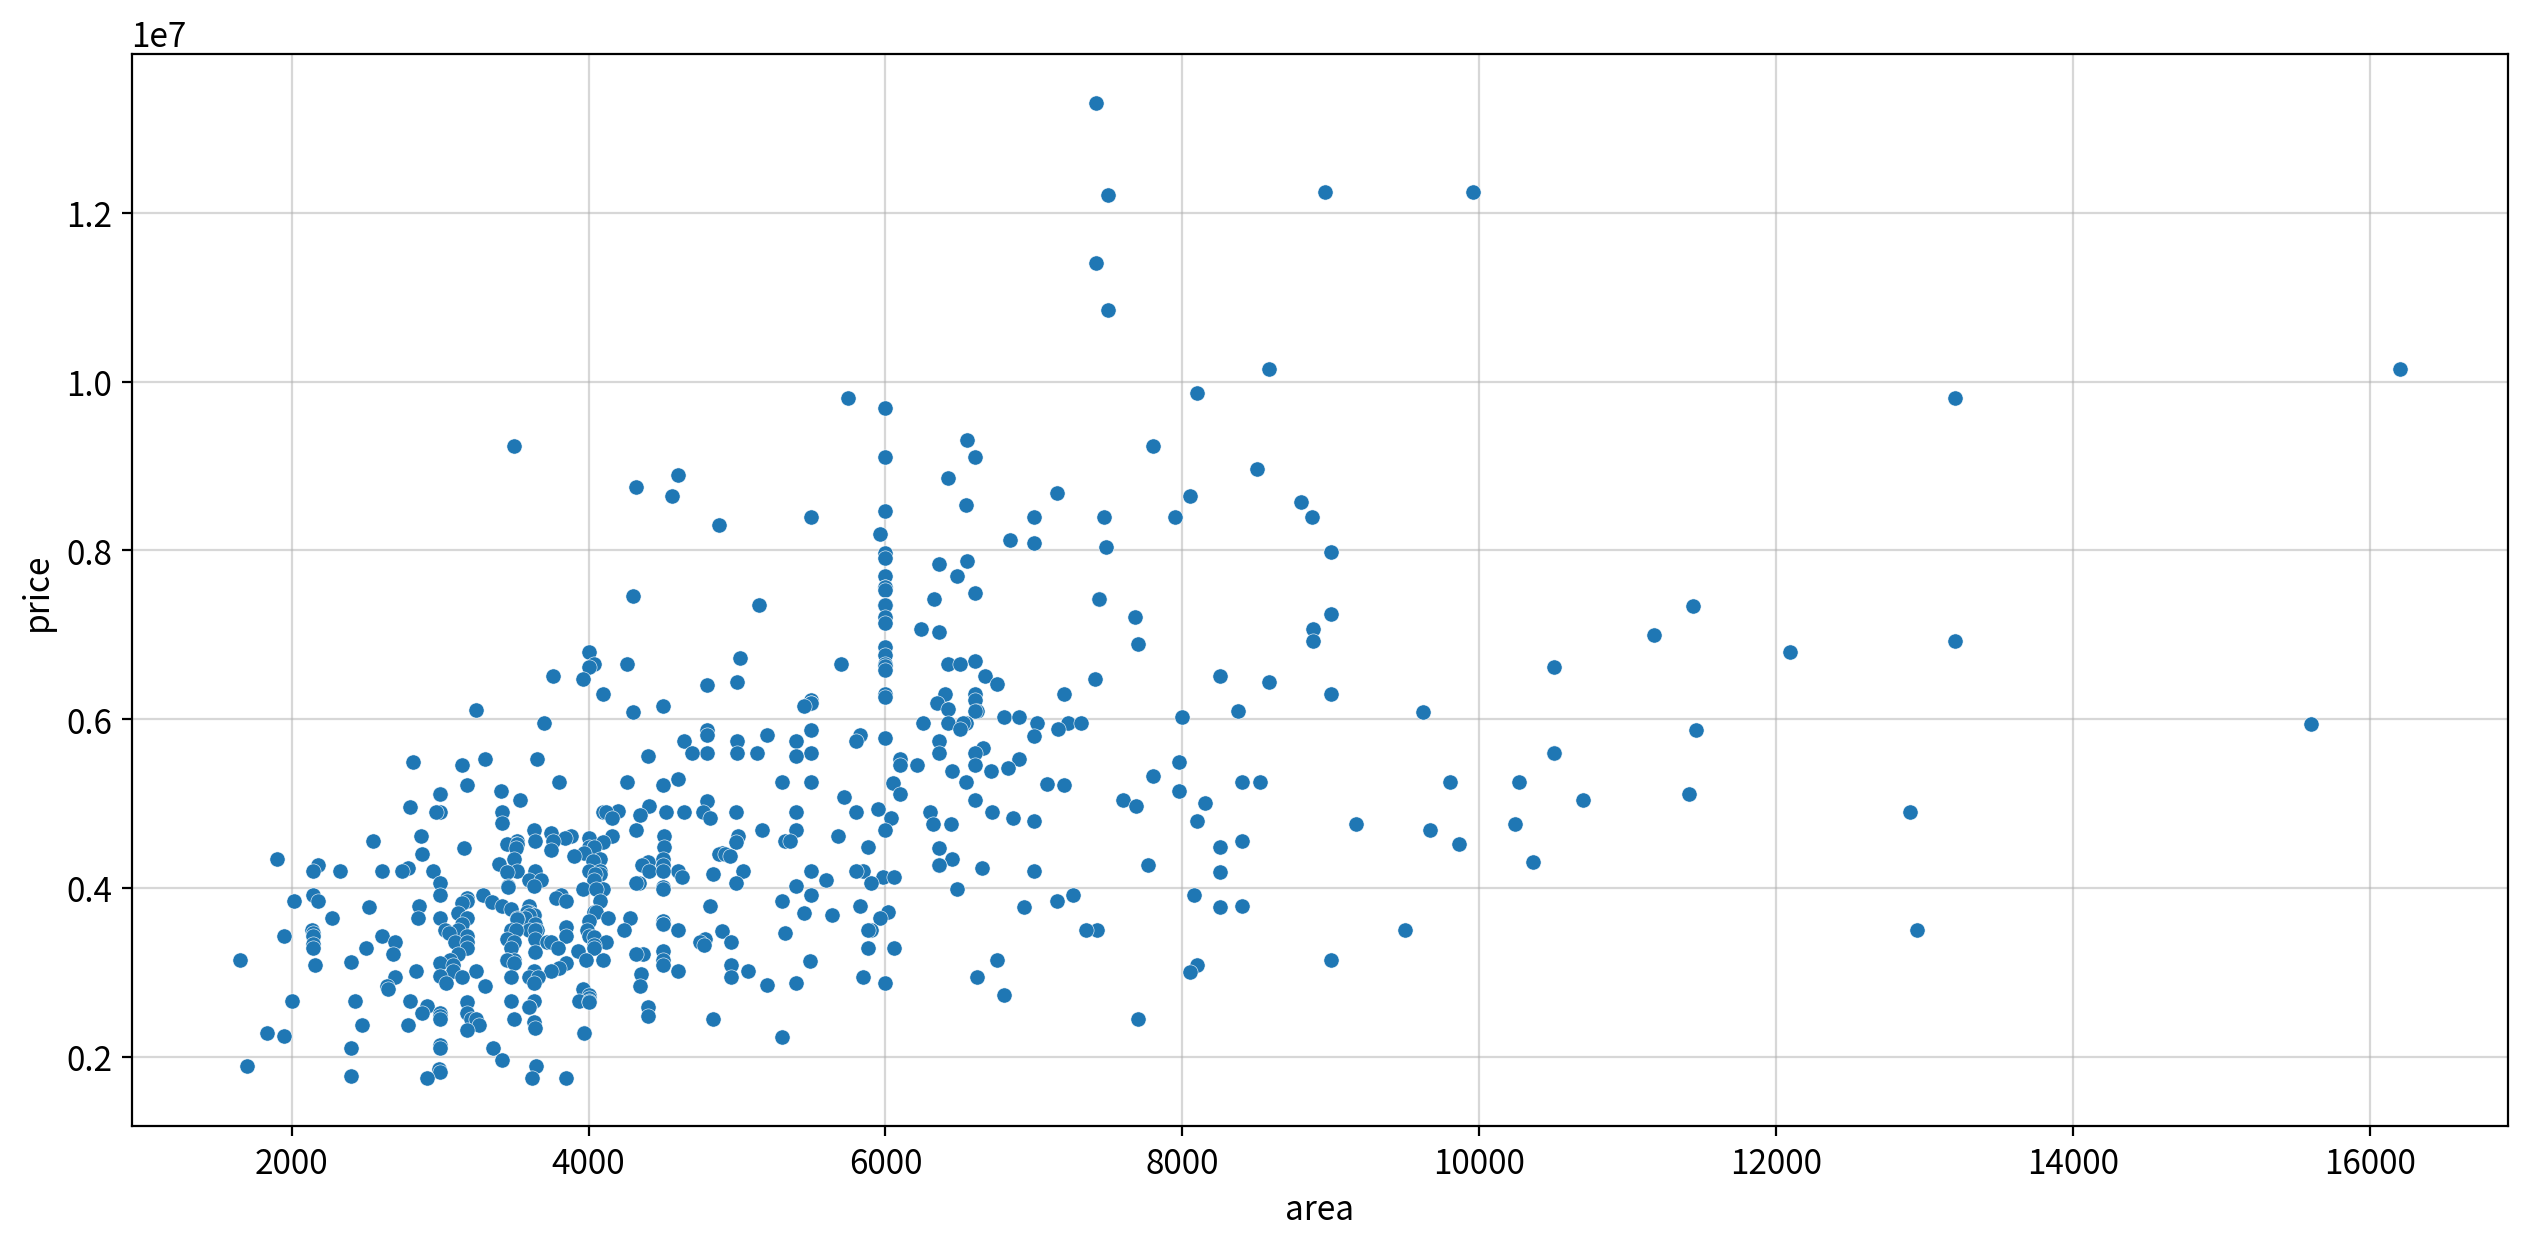

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
area,price,Spearman,0.603,0.000,Moderate,True,False,False,False,False,True


#### ▶︎ bedrooms(침실 수) → price

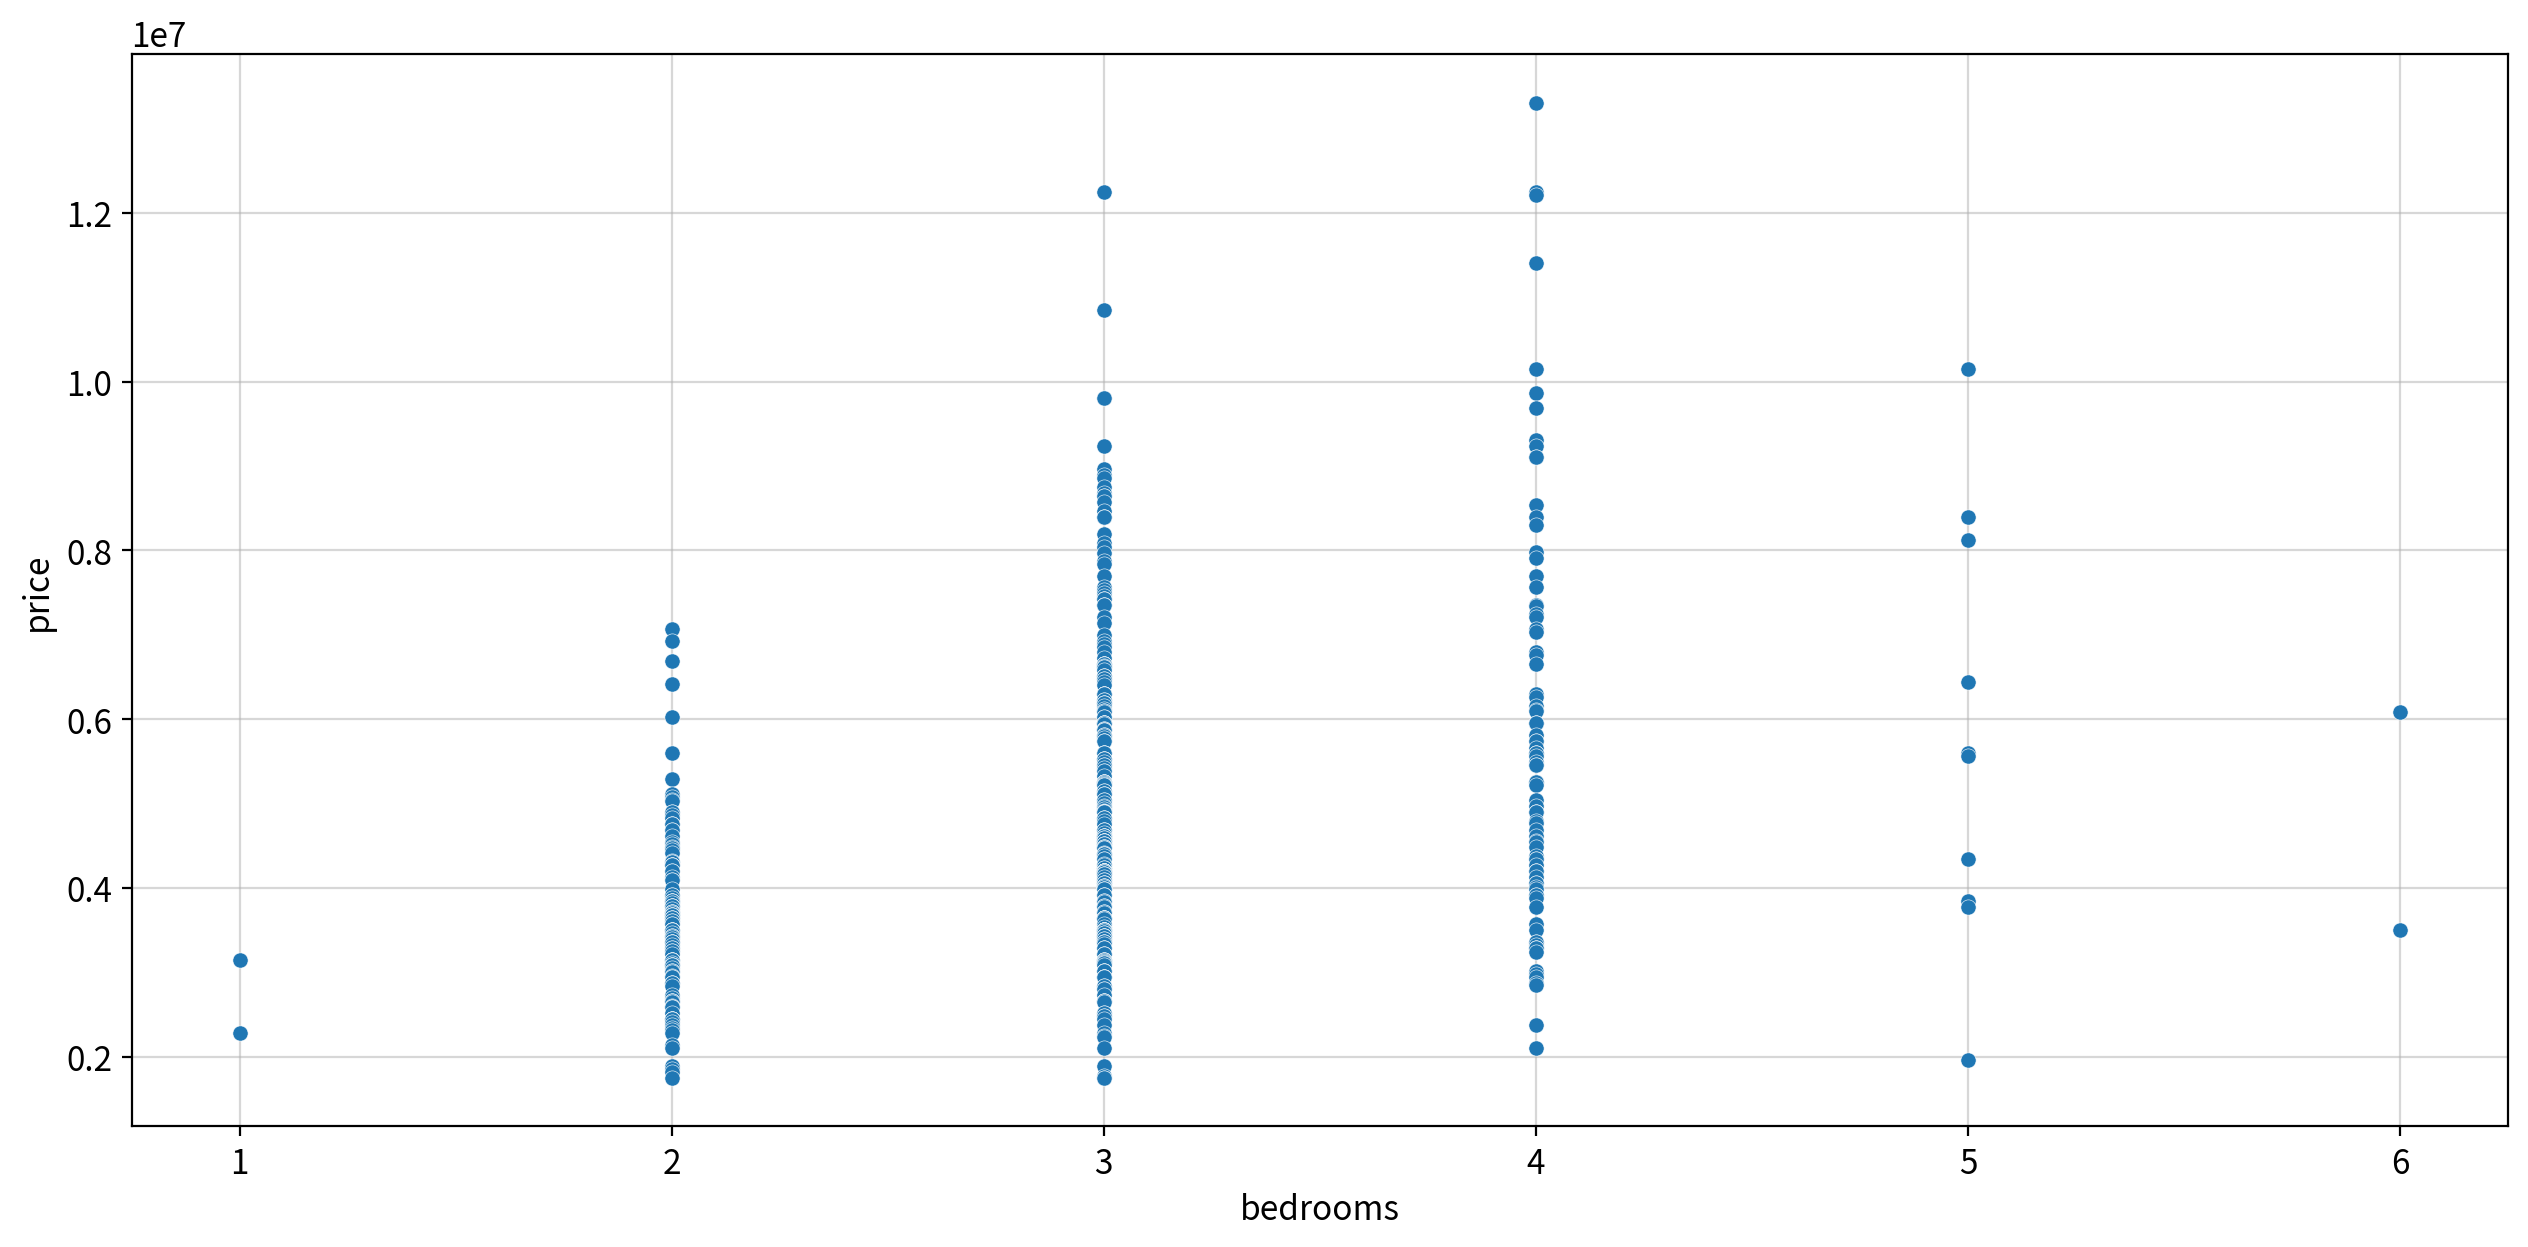

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
bedrooms,price,Spearman,0.391,0.000,Moderate,True,False,False,False,False,True


#### ▶︎ bathrooms(욕실 수) → price

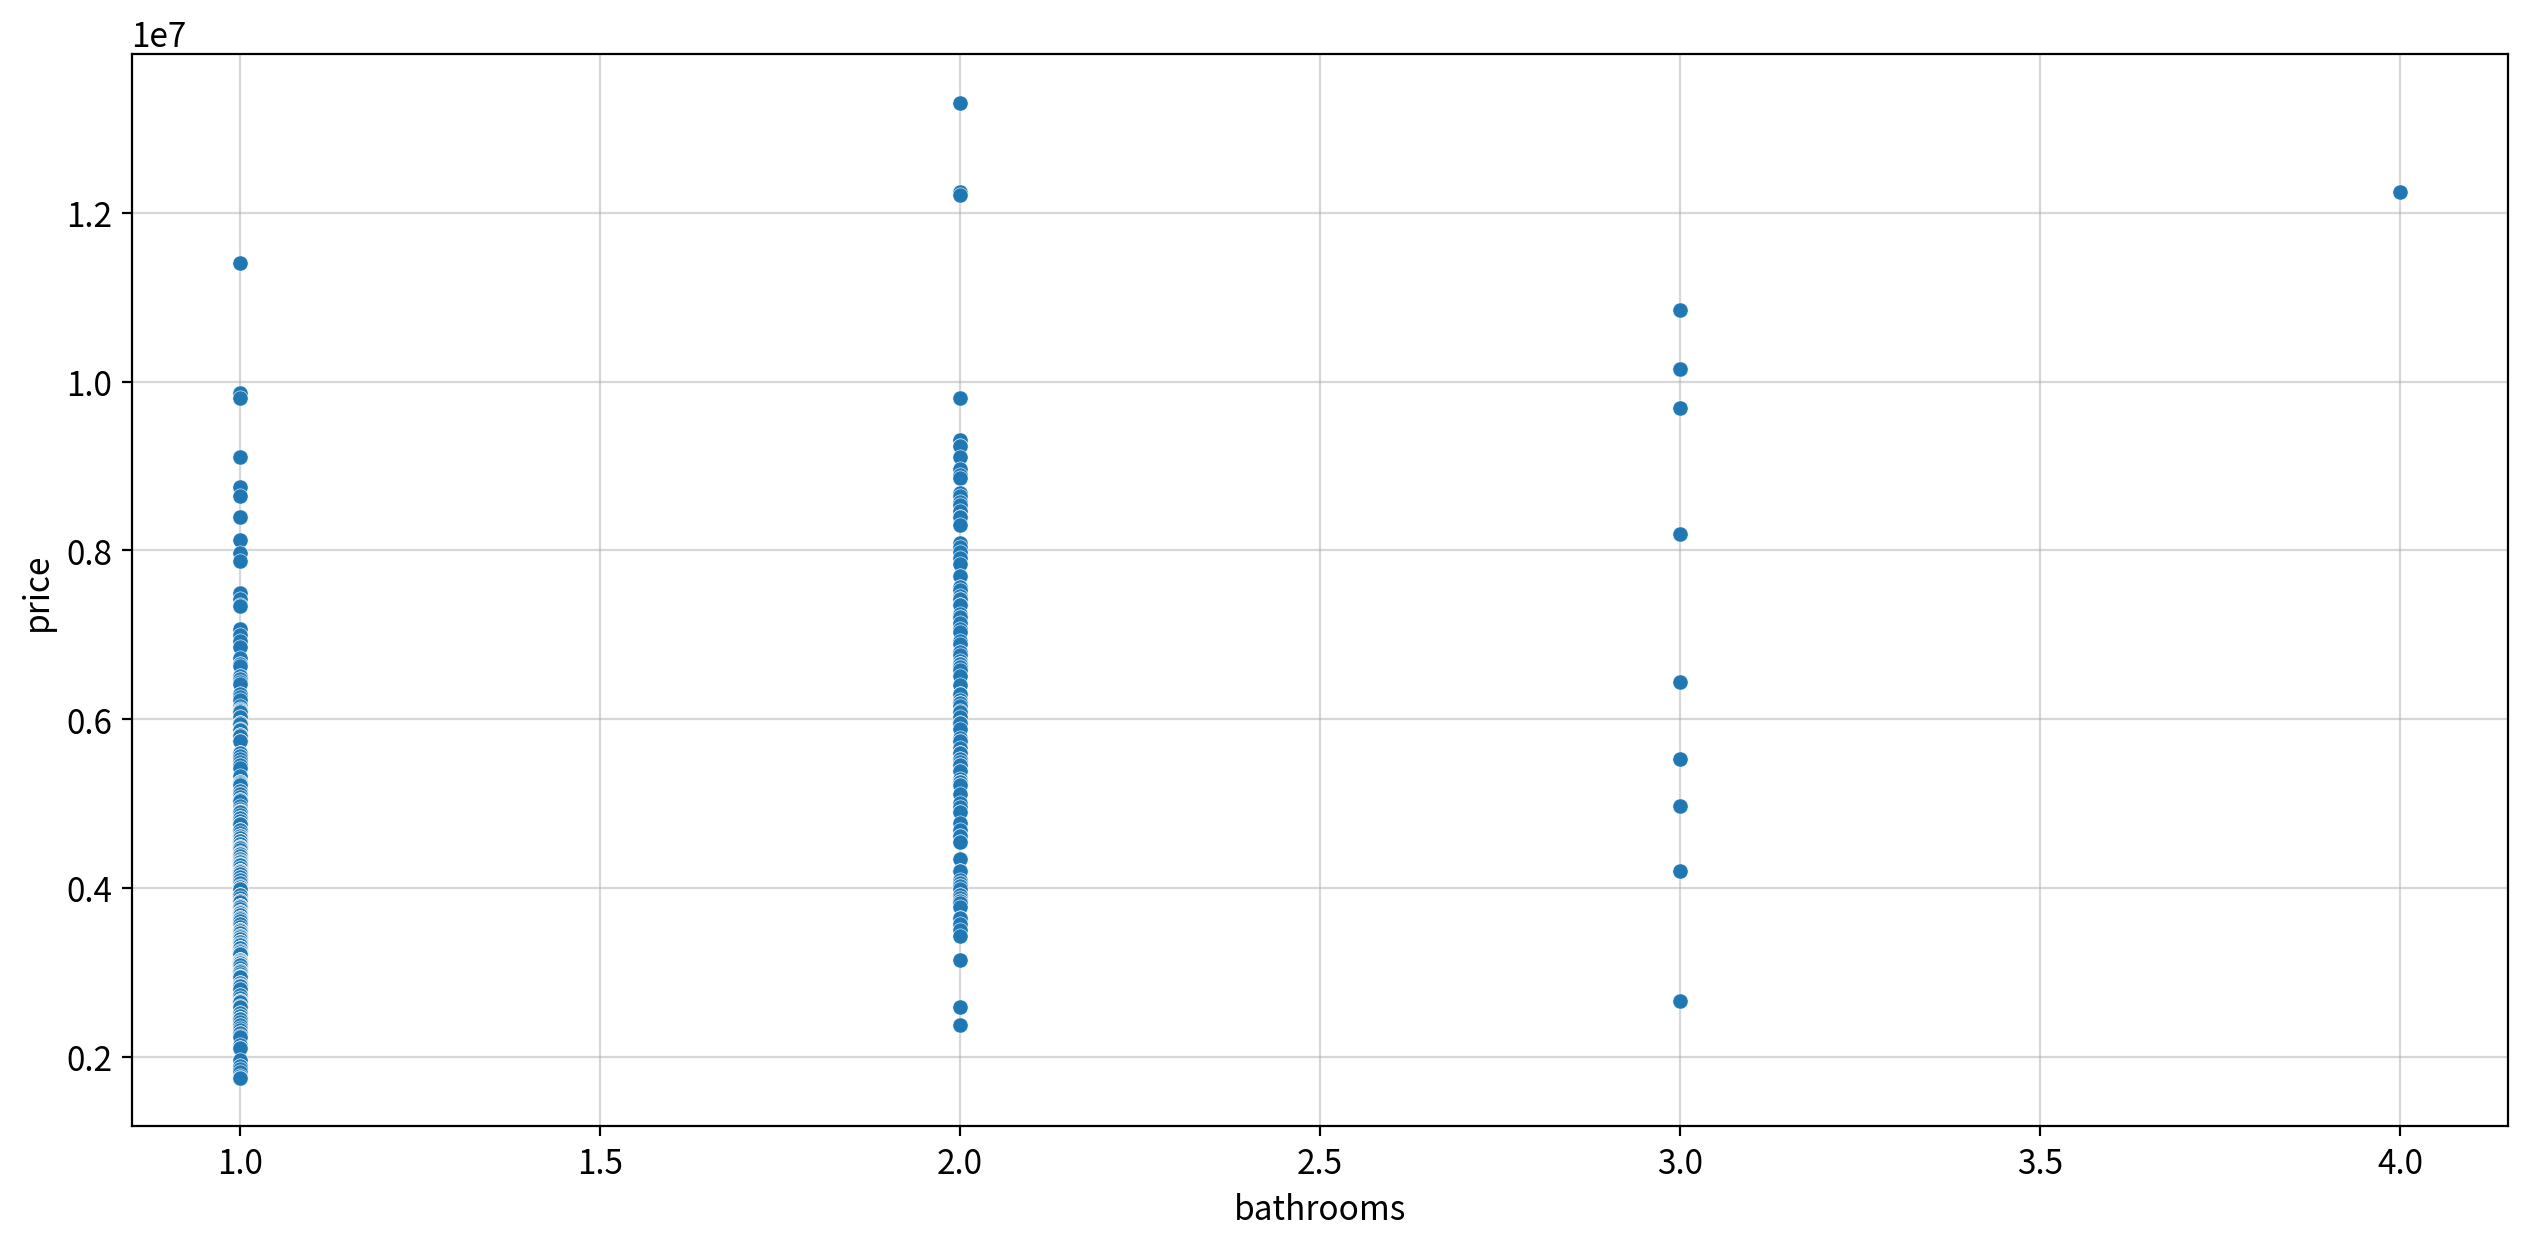

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
bathrooms,price,Spearman,0.480,0.000,Moderate,True,False,False,True,False,True


#### ▶︎ stories(층수) → price

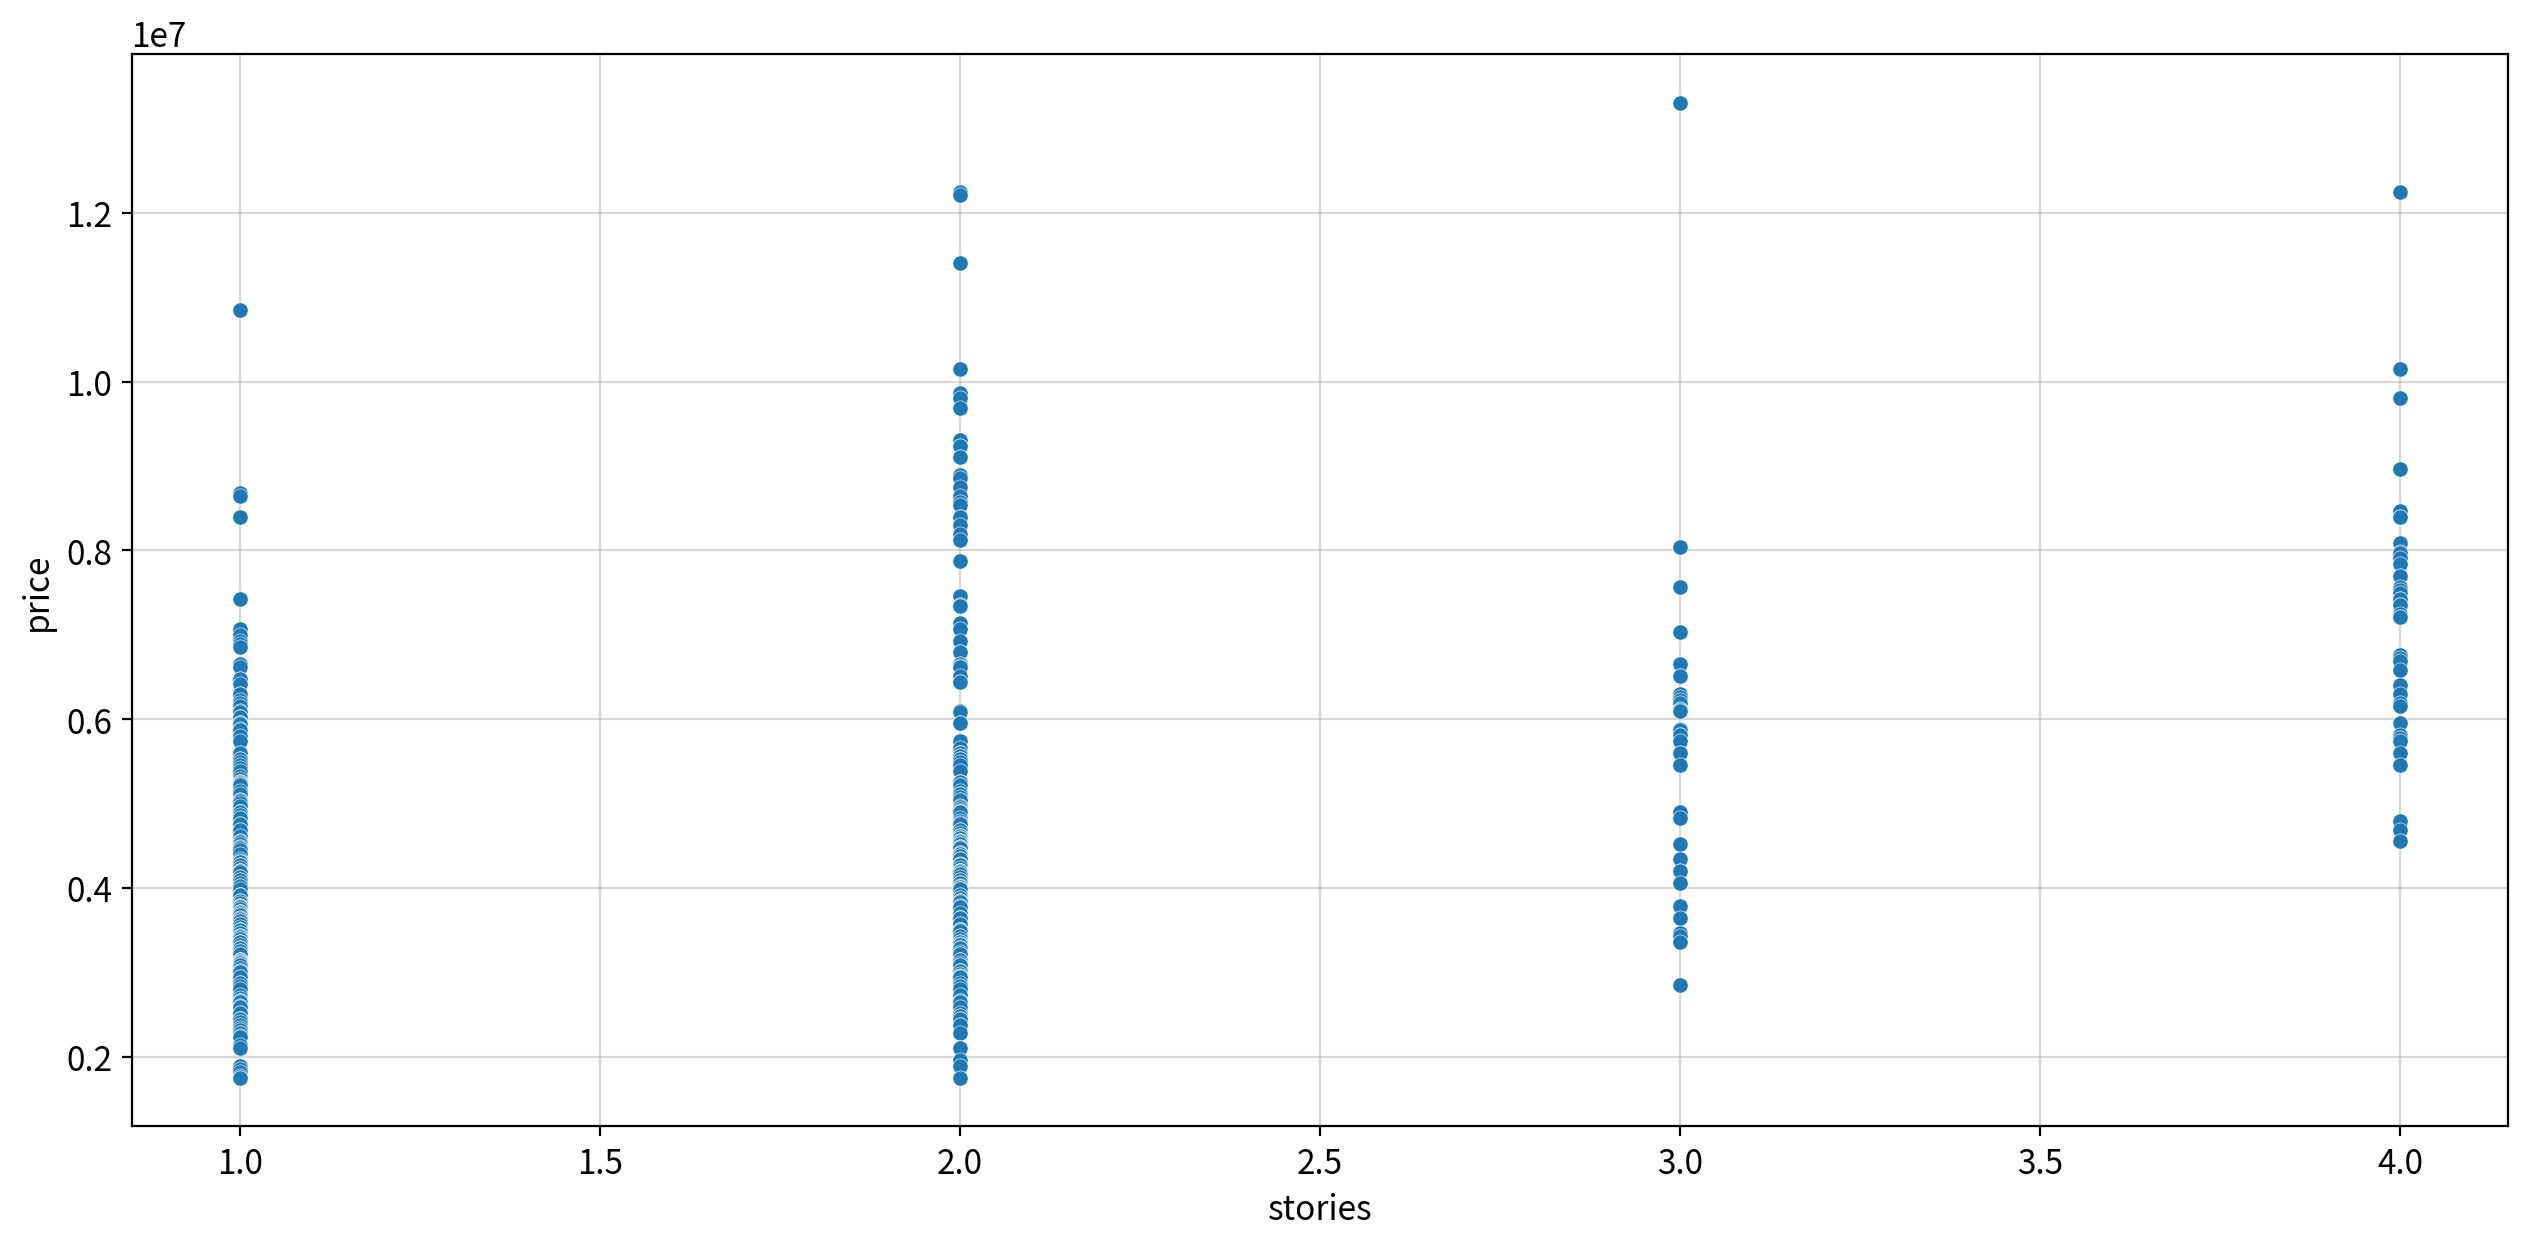

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
stories,price,Spearman,0.363,0.000,Moderate,True,False,False,False,True,True


#### ▶︎ parking(주차 가능 차량 수) → price

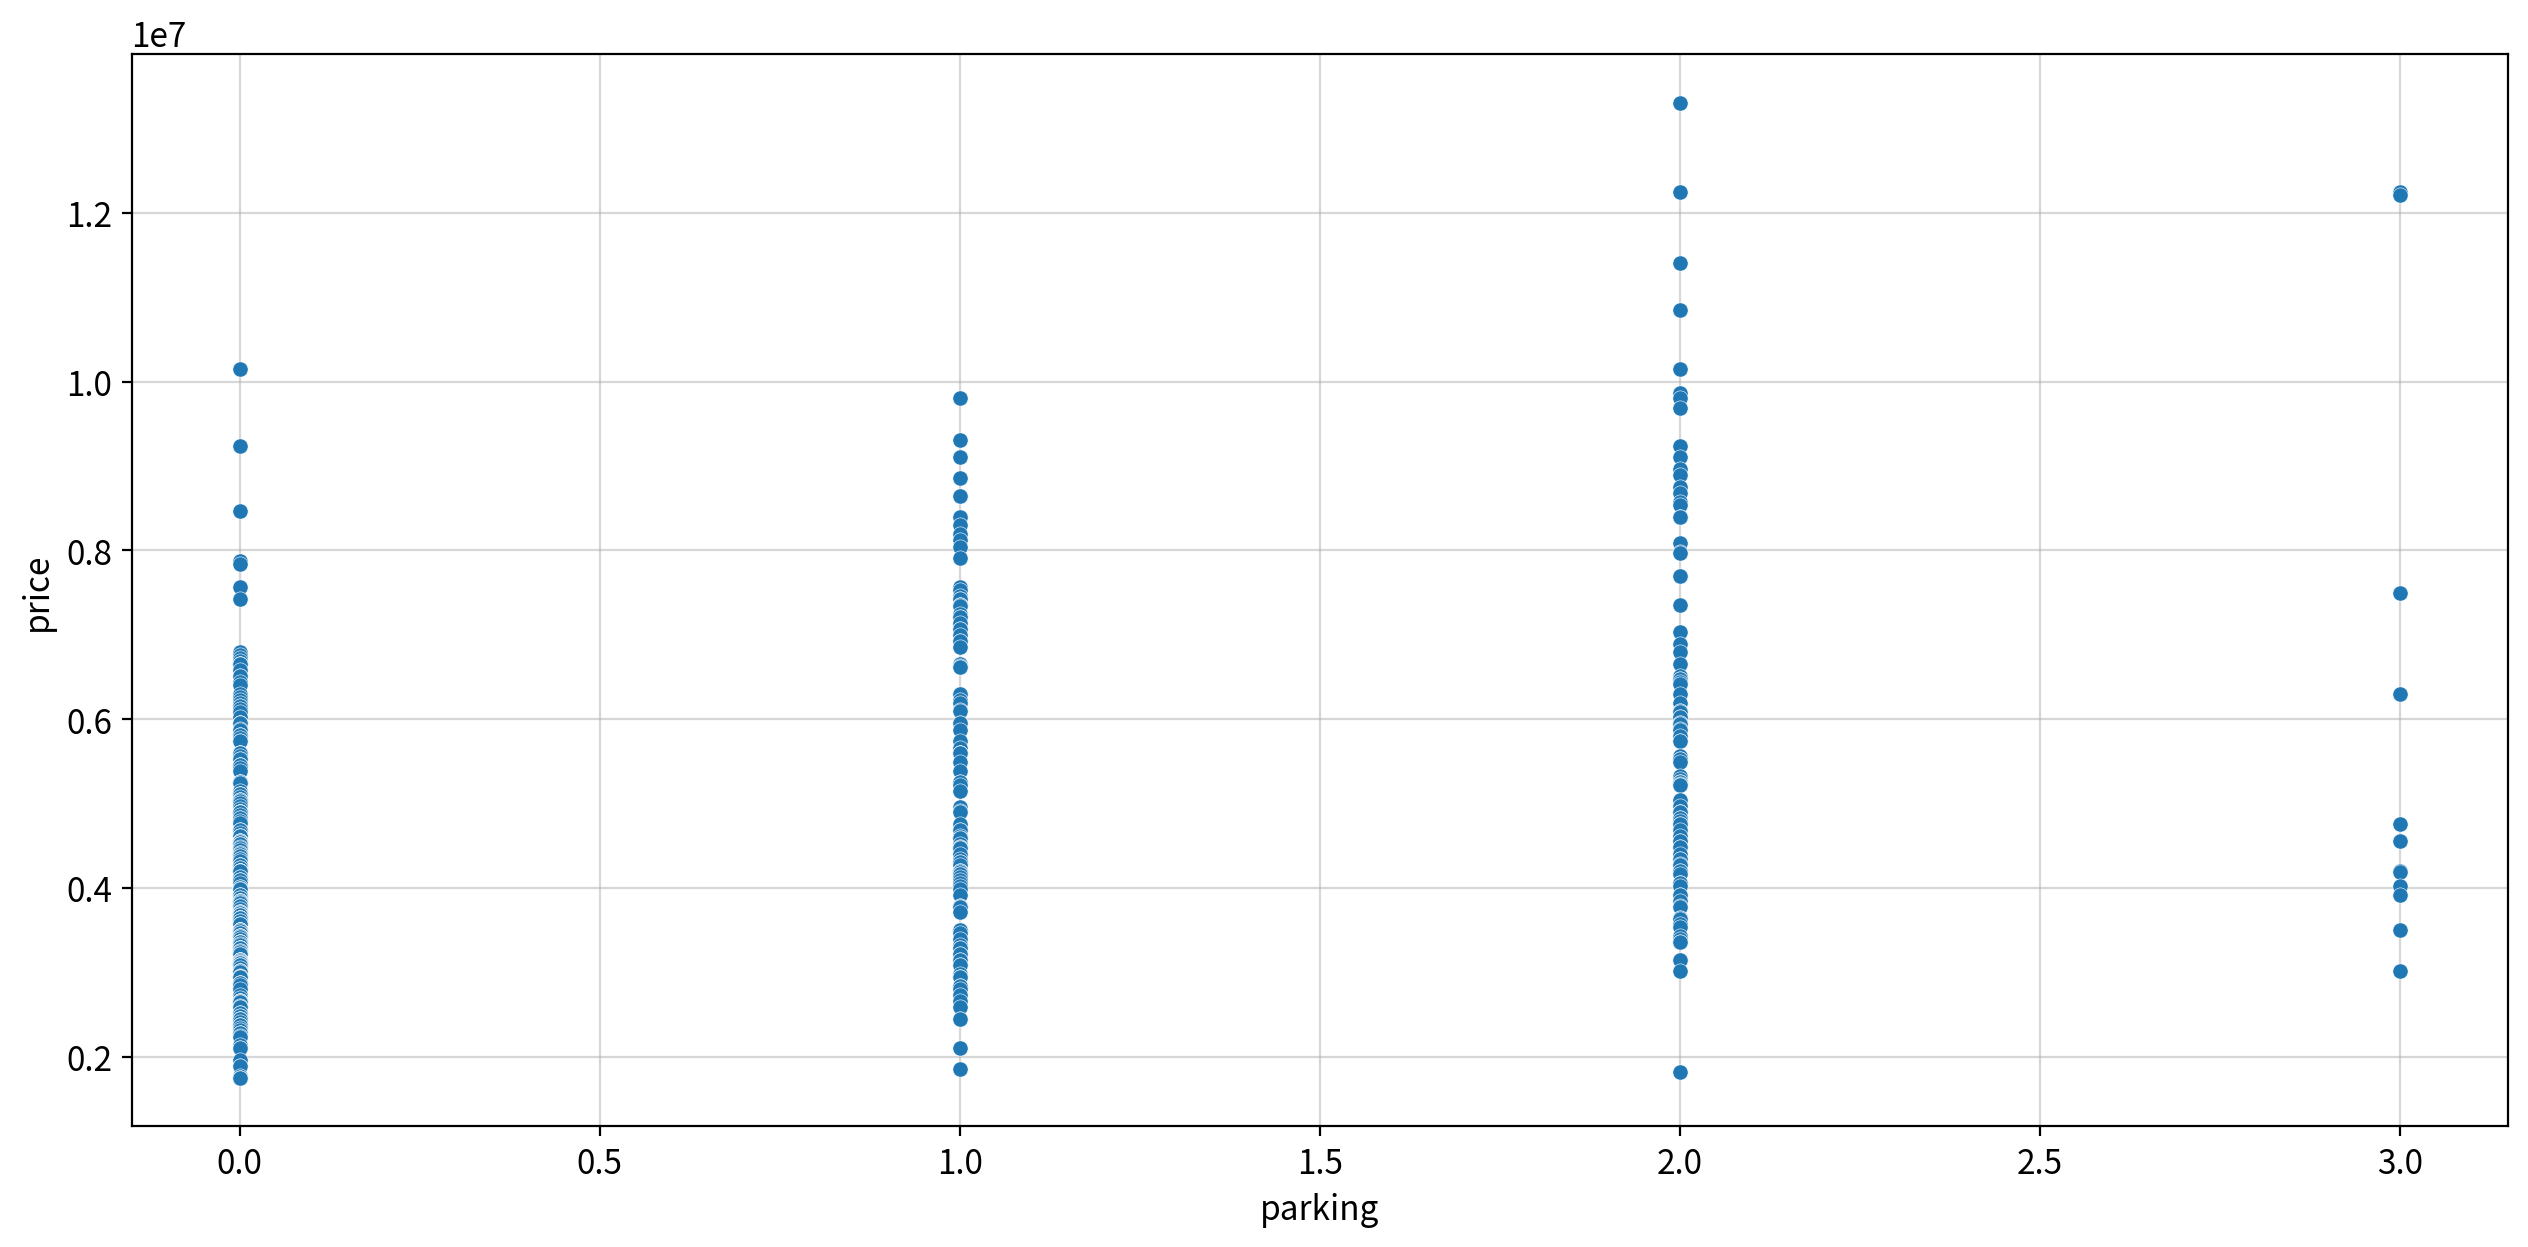

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
parking,price,Spearman,0.365,0.000,Moderate,True,False,False,False,False,True


In [10]:
# 연속형 독립변수 이름을 탐색하면서 반복
for f in continuous_cols:
    # 빈 줄 출력용
    print()

    # 분석 단위 제목 출력
    display(Markdown(f"#### ▶︎ {f}({column_means[f]}) → {target}"))

    # 시각화
    my_plot.scatterplot(data=df, x=f, y=target, outline=False,
                        # 데이터 밀도에 따라 외곽선 굵기와 점 크기 조절
                        linewidth=0.2, size=30)
    
    # my_stats는 시각화까지 일괄처리 한다.
    display(my_stats.correlation(df, x=f, y=target, plot=False))

#### 💡 인사이트

- 종속·독립 모두 정규성 미충족 → 전 변수 **Spearman(ρ)** 으로 판정되었다.

| 변수 | 단조성 (ρ) | 강도 | 특이 신호 | 채택 여부 |
|---|---|---|---|---|
| `area` | +0.603 | Moderate | 비선형 | ✅ **채택 (최우선)** |
| `bathrooms` | +0.480 | Moderate | 선형 | ✅ 채택 |
| `bedrooms` | +0.391 | Moderate | 비선형 | ✅ 채택 |
| `parking` | +0.365 | Moderate | 비선형 | ✅ 채택 |
| `stories` | +0.363 | Moderate | 비선형 / **영향력 있는 이상치** | ✅ 채택 |

- 5종 모두 p<0.05 이고 ρ가 0.36~0.60 → **제외할 만큼 약한 변수가 없다.**
- 다이아몬드처럼 압도적인 단일 설명 변수는 없고 `area`가 가장 높다.

### 2. T-Test (x: 2집단 명목형 독립변수 → y: 종속변수)

- 2개의 고유값만 존재하는 명목형 독립변수에 대해서만 검정을 수행한다.
  - 2개의 고유값만 존재하는 명목형이 없을 경우 출력 결과가 없을 수 있다.

#### ▶︎ mainroad(도로 접근성) → price

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

no vs. yes: Mann-Whitney-Wilcoxon test two-sided, P_val:2.138e-15 U_stat=7.860e+03


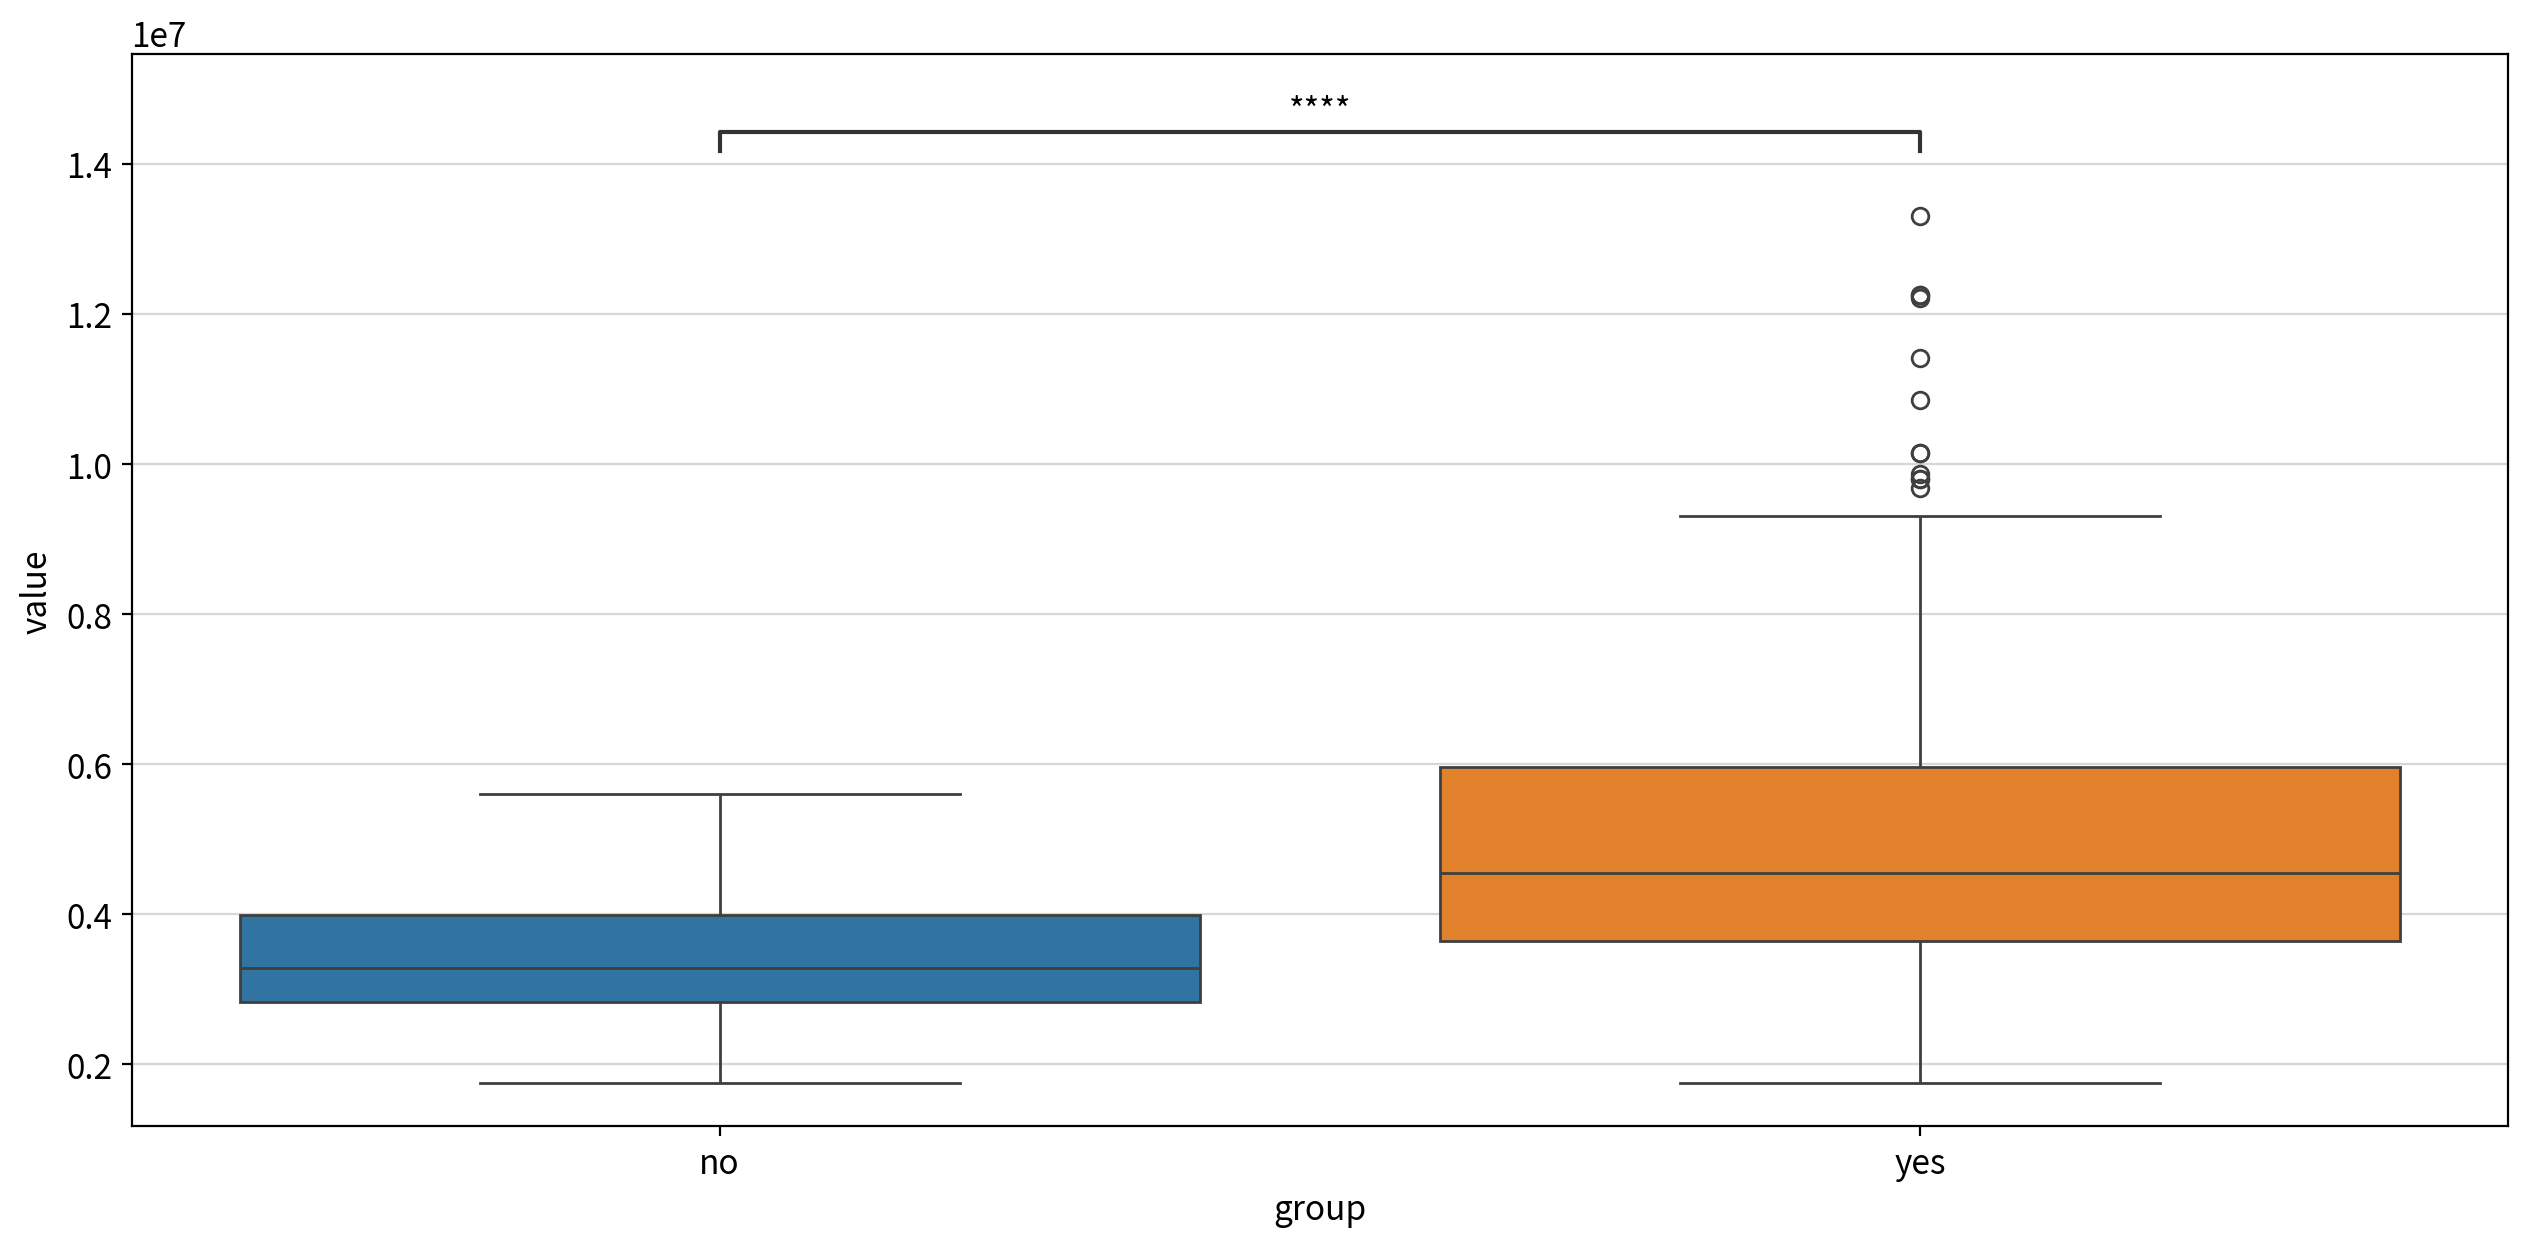

statistic  p-value  significant    result
test                alternative                                           
Mann-Whitney U test two-sided     7860.000    0.000         True  no ≠ yes
                    less          7860.000    0.000         True  no < yes
                    greater       7860.000    1.000        False  no ≤ yes

#### ▶︎ guestroom(게스트룸 유무) → price

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

no vs. yes: Mann-Whitney-Wilcoxon test two-sided, P_val:2.624e-12 U_stat=1.189e+04


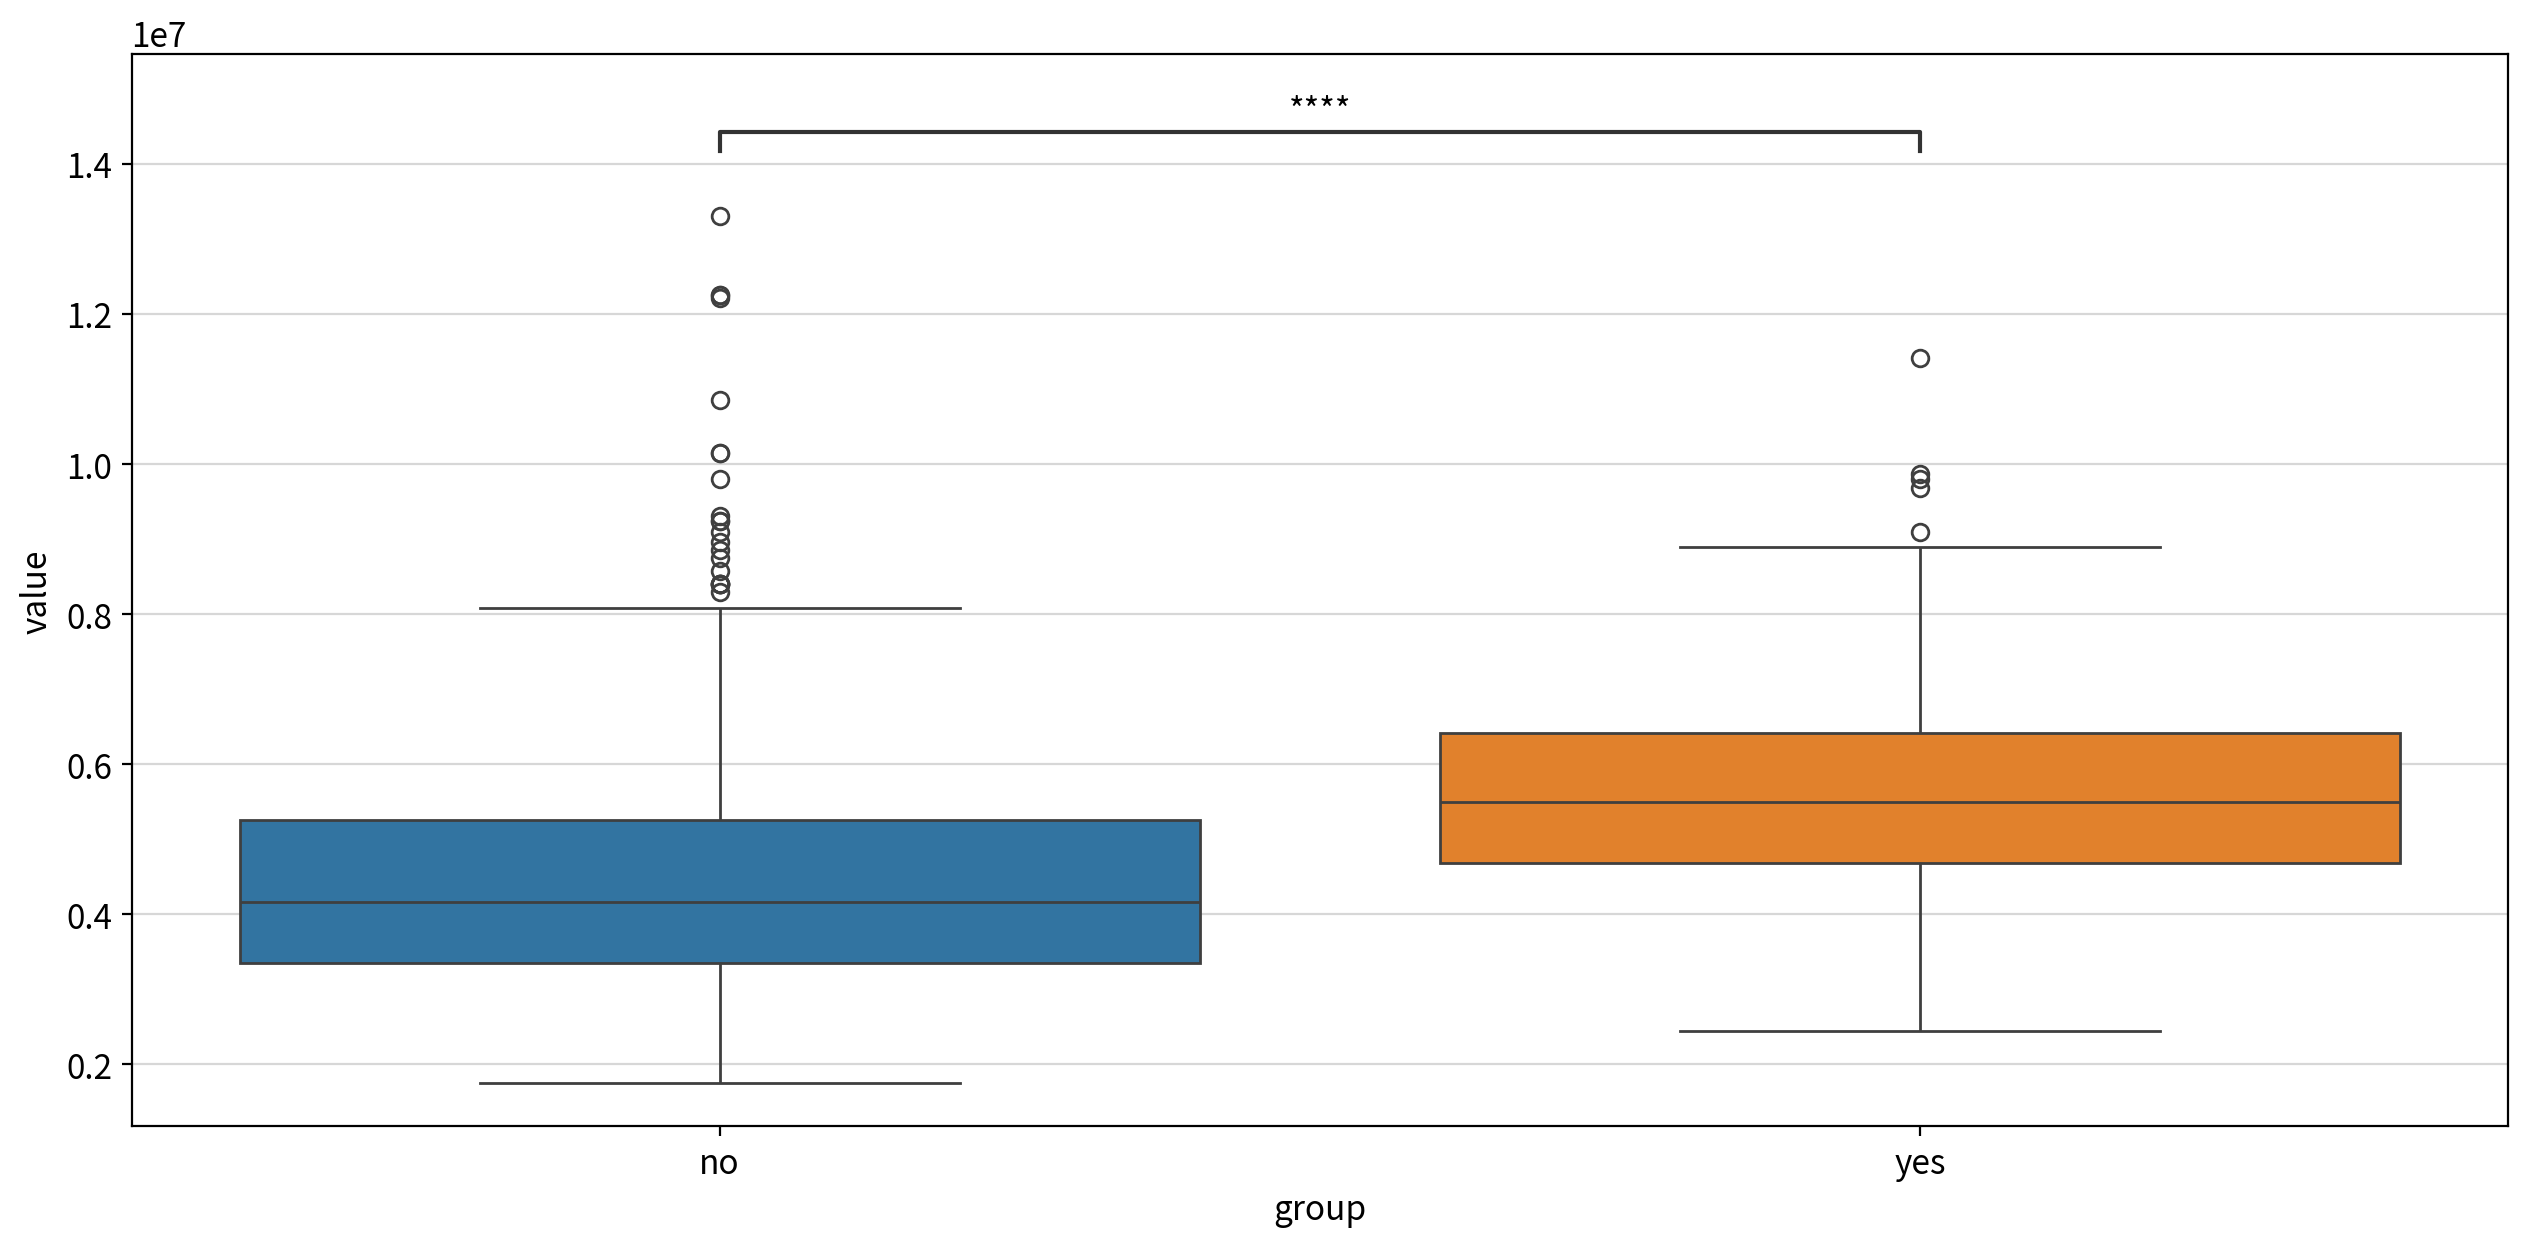

statistic  p-value  significant    result
test                alternative                                           
Mann-Whitney U test two-sided    11890.000    0.000         True  no ≠ yes
                    less         11890.000    0.000         True  no < yes
                    greater      11890.000    1.000        False  no ≤ yes

#### ▶︎ basement(지하실 유무) → price

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

no vs. yes: Mann-Whitney-Wilcoxon test two-sided, P_val:8.043e-08 U_stat=2.440e+04


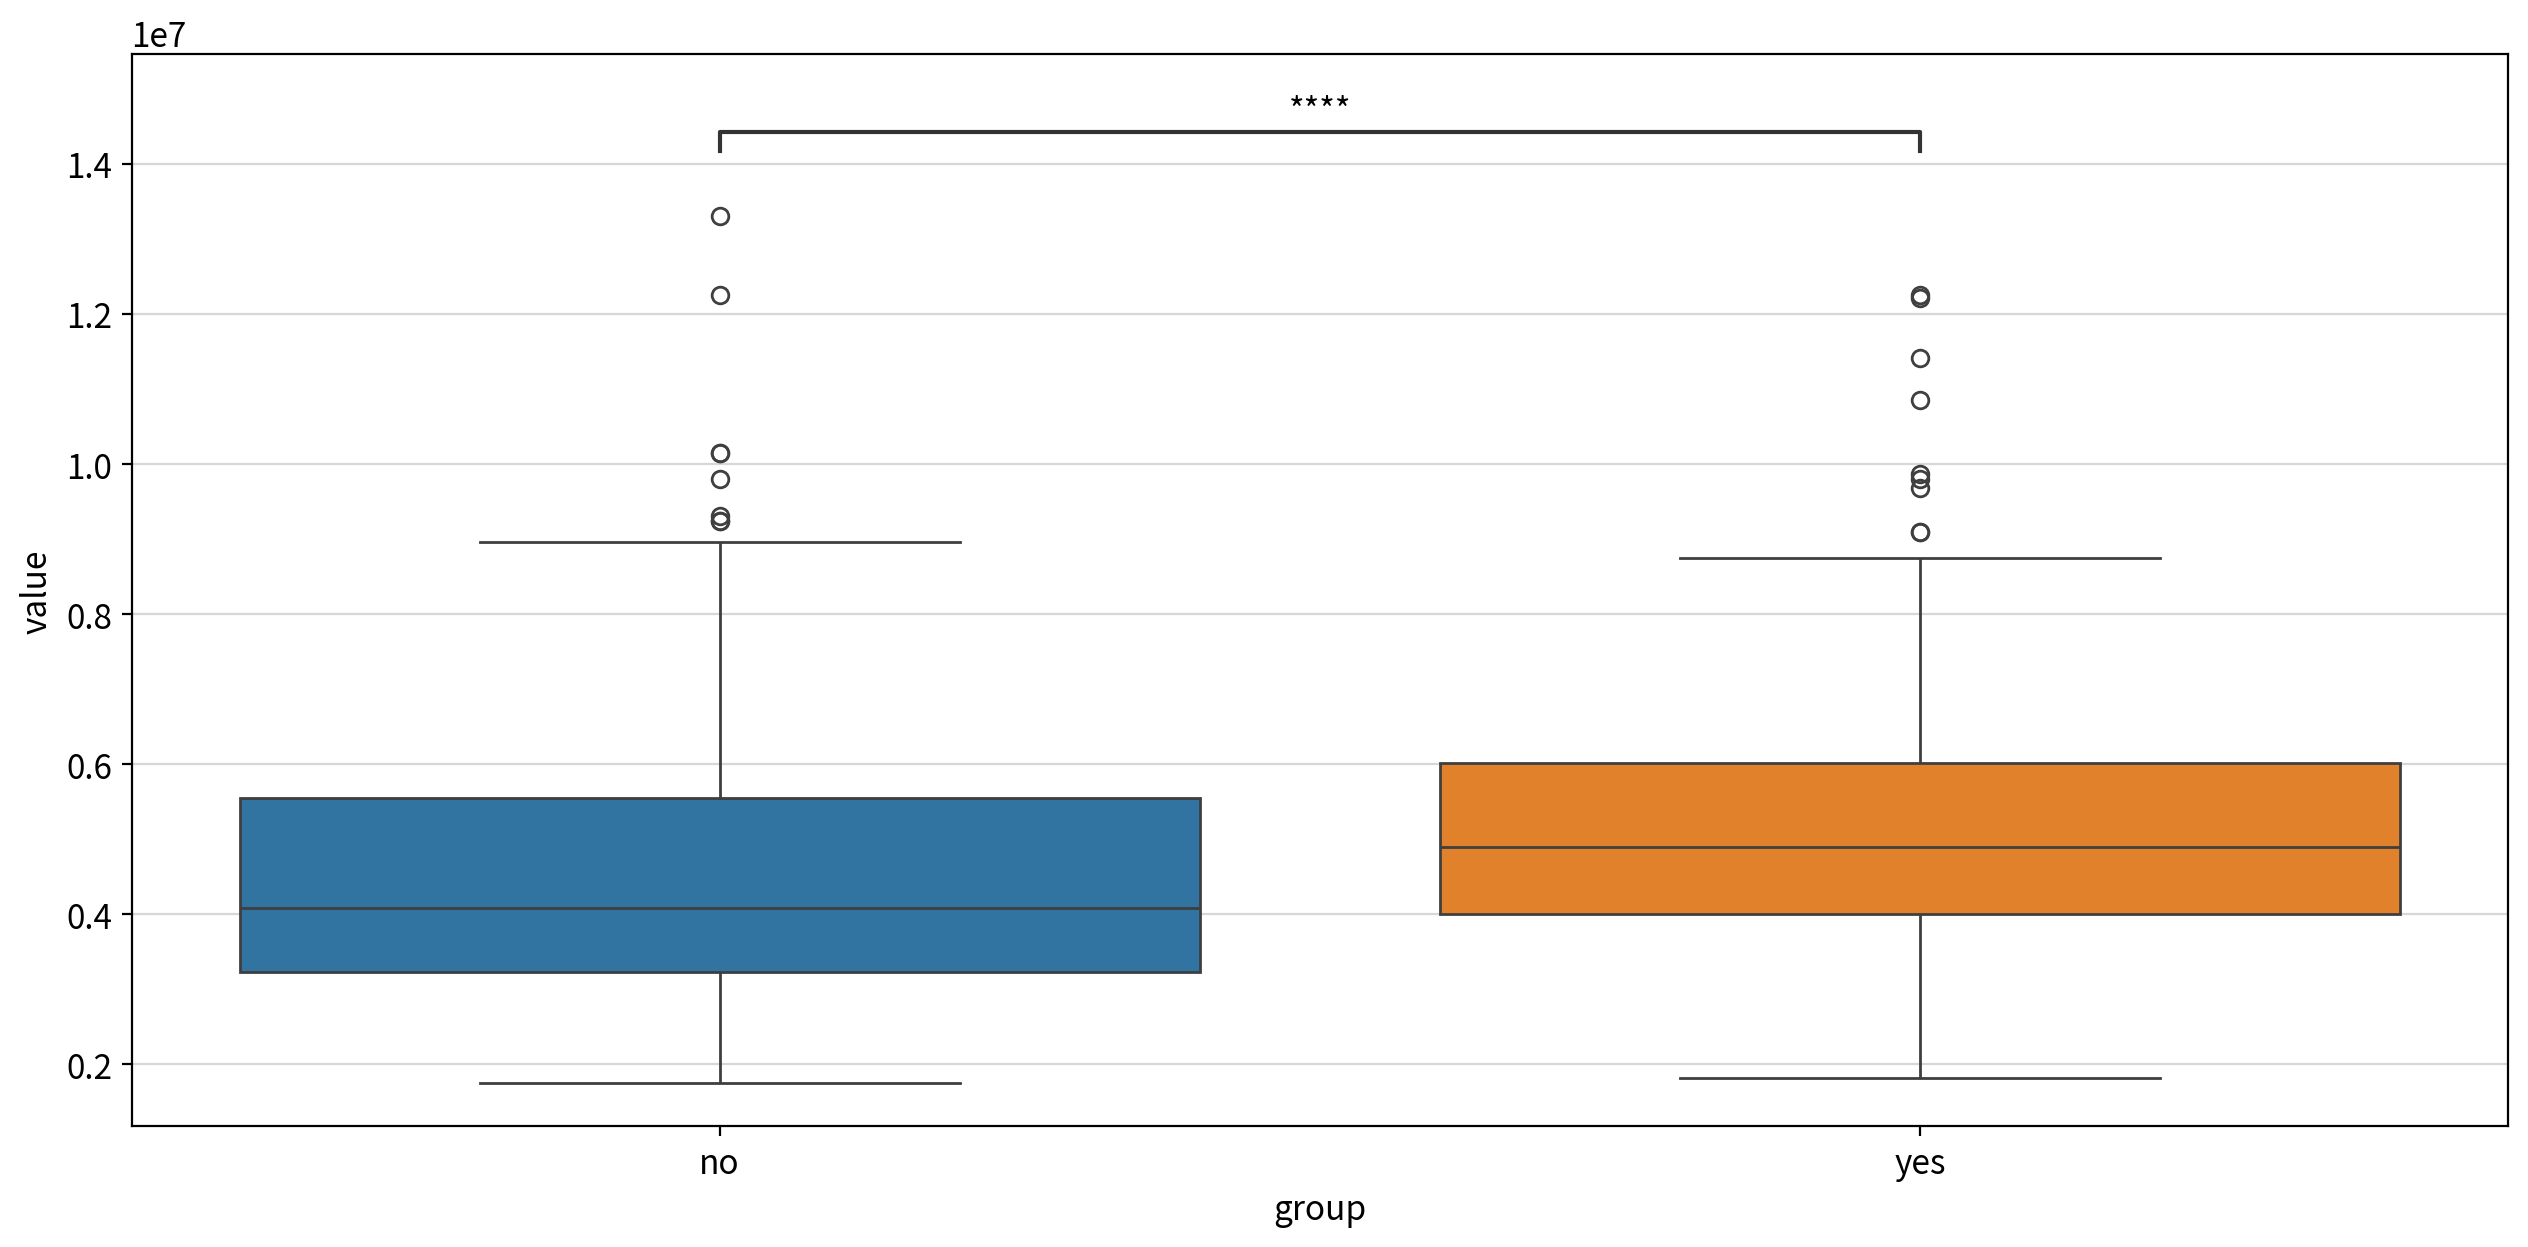

statistic  p-value  significant    result
test                alternative                                           
Mann-Whitney U test two-sided    24395.000    0.000         True  no ≠ yes
                    less         24395.000    0.000         True  no < yes
                    greater      24395.000    1.000        False  no ≤ yes

#### ▶︎ hotwaterheating(온수 난방) → price

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

no vs. yes: Mann-Whitney-Wilcoxon test two-sided, P_val:4.615e-02 U_stat=4.966e+03


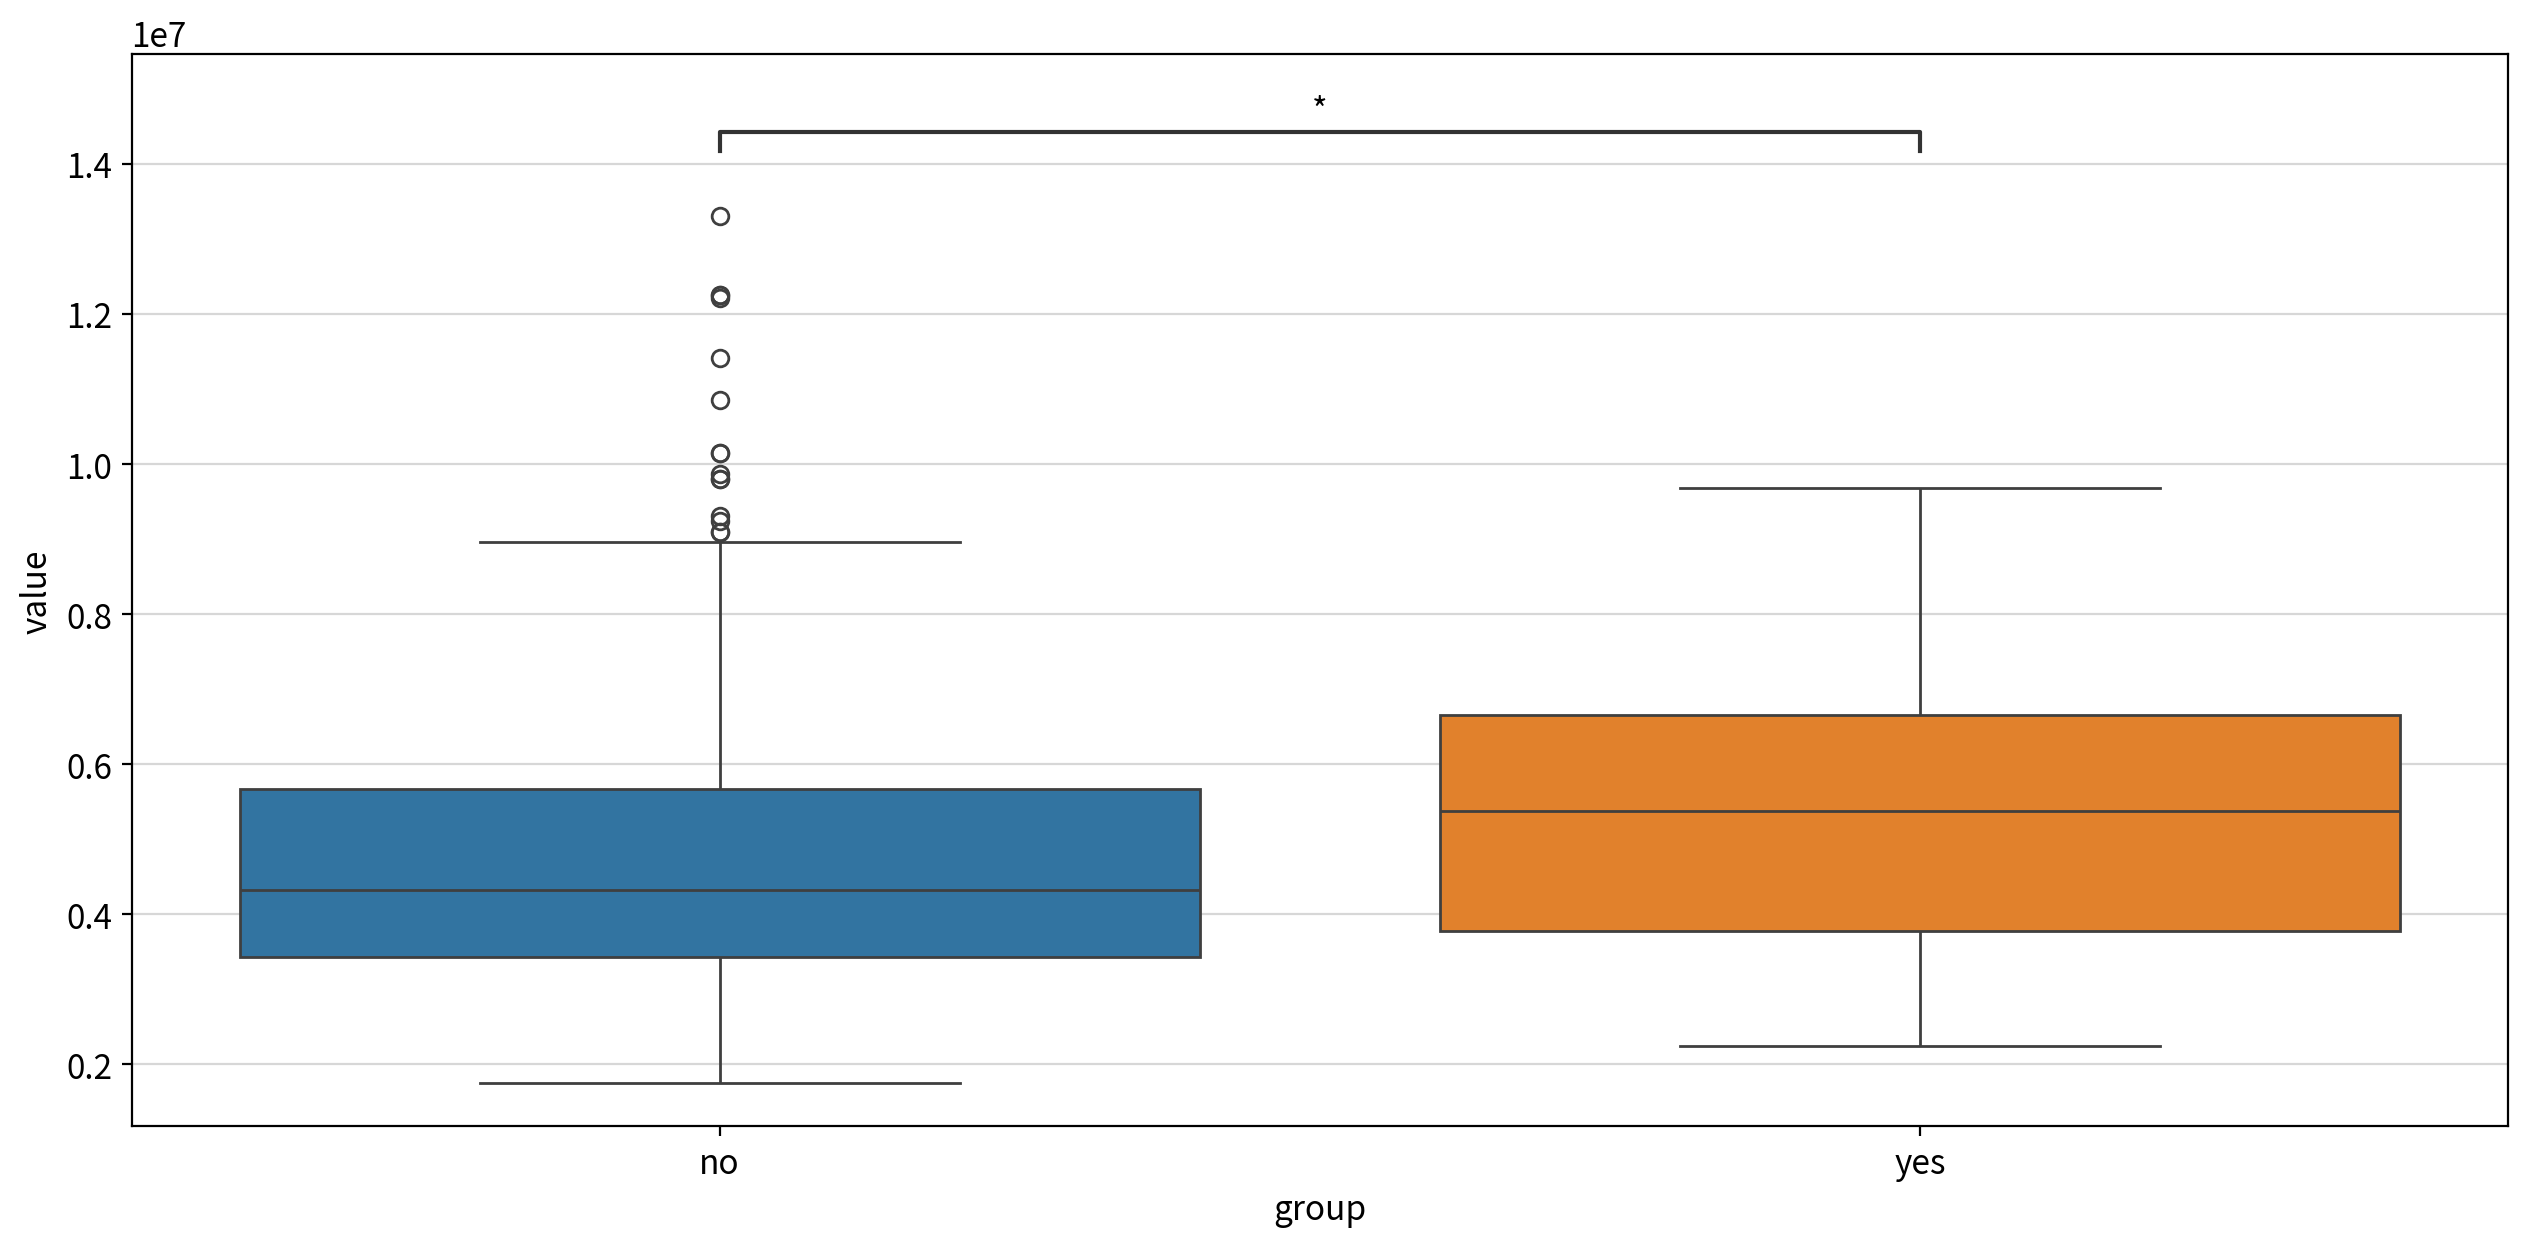

statistic  p-value  significant    result
test                alternative                                           
Mann-Whitney U test two-sided     4966.000    0.046         True  no ≠ yes
                    less          4966.000    0.023         True  no < yes
                    greater       4966.000    0.977        False  no ≤ yes

#### ▶︎ airconditioning(에어컨 유무) → price

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

no vs. yes: Mann-Whitney-Wilcoxon test two-sided, P_val:1.549e-26 U_stat=1.386e+04


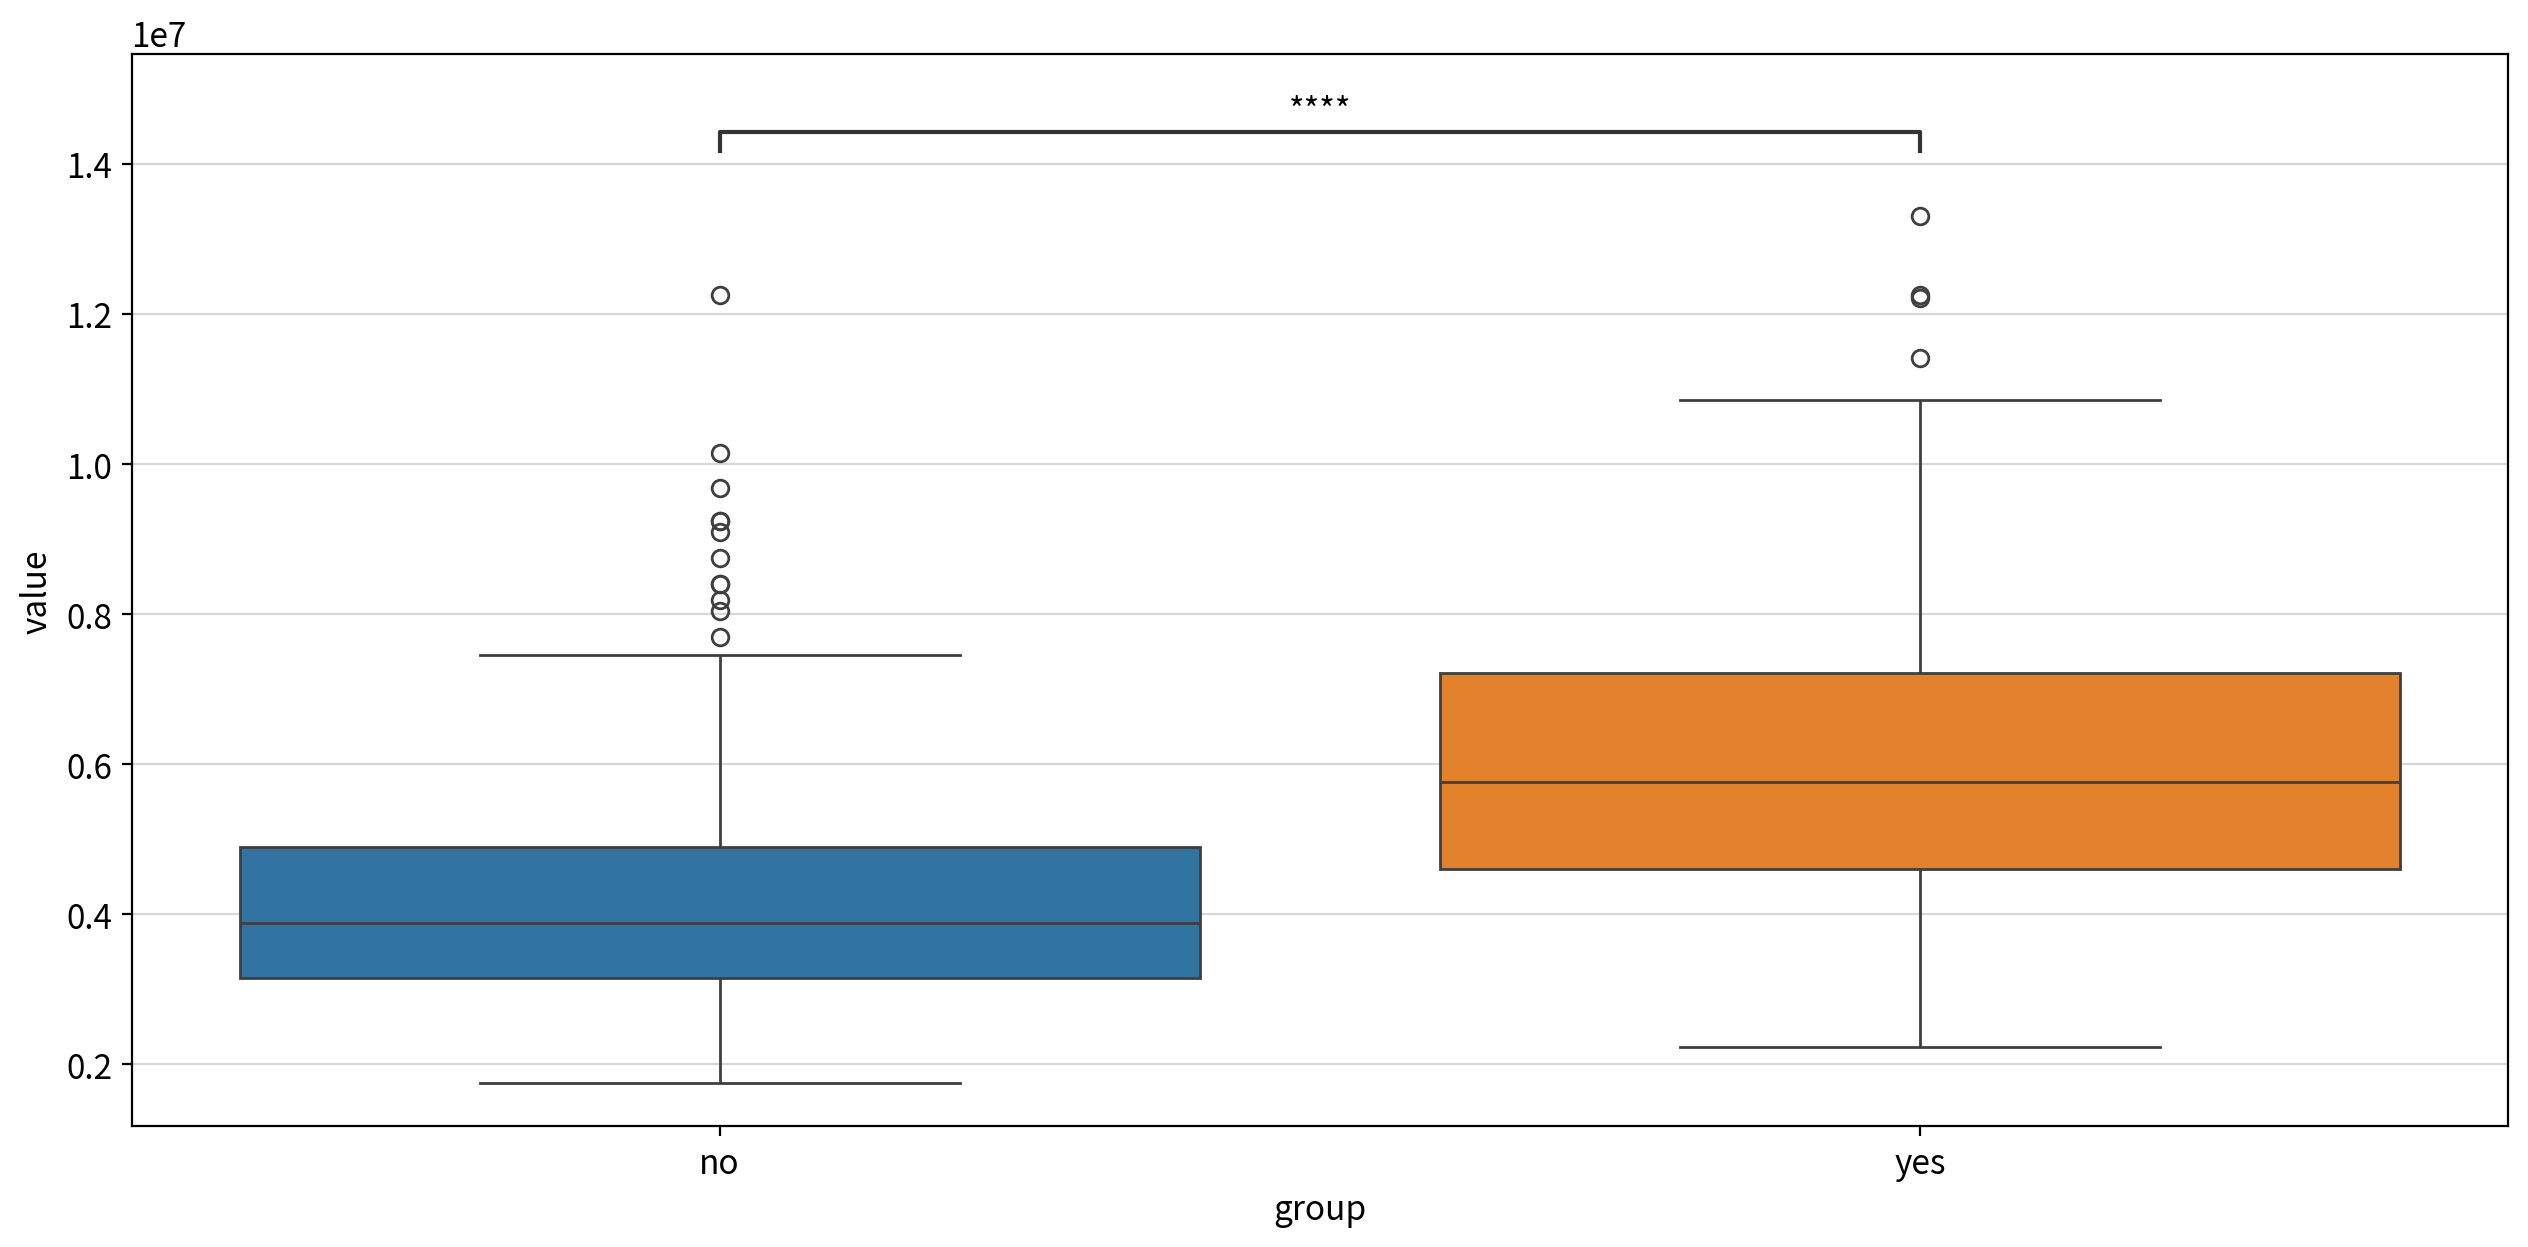

statistic  p-value  significant    result
test                alternative                                           
Mann-Whitney U test two-sided    13864.000    0.000         True  no ≠ yes
                    less         13864.000    0.000         True  no < yes
                    greater      13864.000    1.000        False  no ≤ yes

#### ▶︎ prefarea(선호 지역 여부) → price

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

no vs. yes: Mann-Whitney-Wilcoxon test two-sided, P_val:5.069e-16 U_stat=1.405e+04


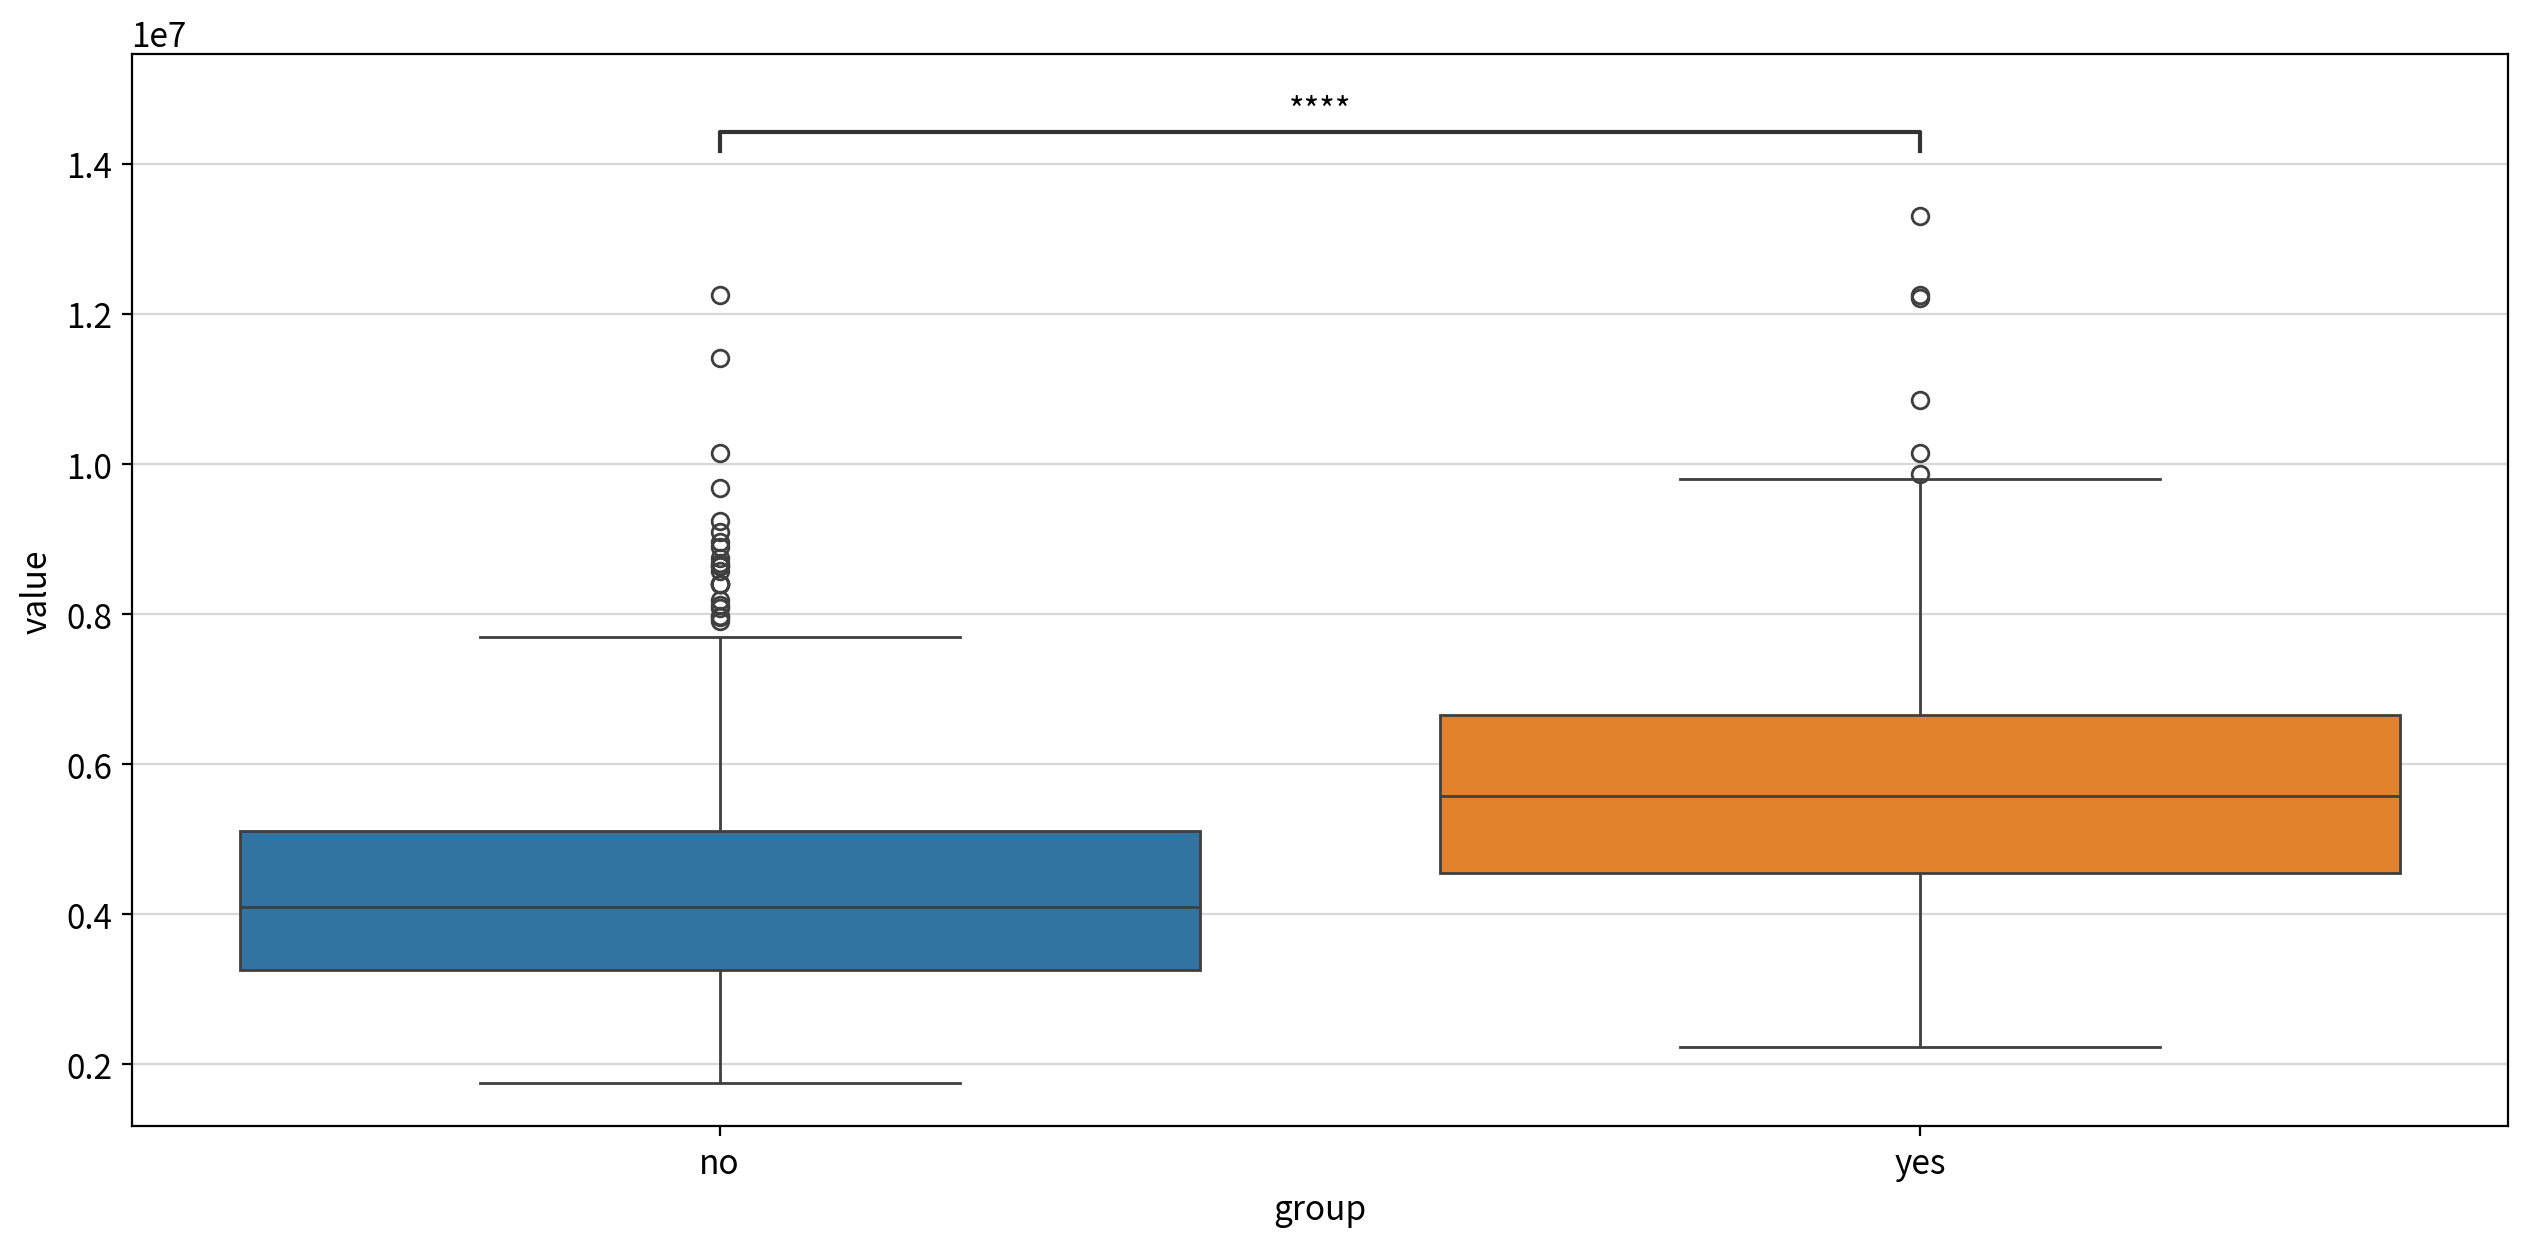

statistic  p-value  significant    result
test                alternative                                           
Mann-Whitney U test two-sided    14050.000    0.000         True  no ≠ yes
                    less         14050.000    0.000         True  no < yes
                    greater      14050.000    1.000        False  no ≤ yes

In [11]:
for n in nominal_cols:
    # 2개의 고유값만 존재하는 명목형 독립변수에 대해서만 검정을 수행한다.
    if len(df[n].unique()) == 2:
        # 빈 줄 출력용
        print()

        # 분석 단위 제목 출력
        display(Markdown(f"#### ▶︎ {n}({column_means[n]}) → {target}"))

        # 수집된 데이터가 long 타입이므로 검정 대상만 wide 타입으로 변환해야 한다.
        wide_df = my_prep.long2wide(df, hue=n, values=target)
        display(my_stats.test_independent(wide_df, 
                    group1=wide_df.columns[0], group2=wide_df.columns[1]))

#### 💡 인사이트

- 정규성 미충족으로 **Mann-Whitney U 검정**이 적용되었다.

| 변수 | p값 | 방향 | 채택 여부 |
|---|---|---|---|
| `airconditioning` | 0.000 | no < yes | ✅ **채택 (최우선)** |
| `prefarea` | 0.000 | no < yes | ✅ 채택 |
| `mainroad` | 0.000 | no < yes | ✅ 채택 |
| `guestroom` | 0.000 | no < yes | ✅ 채택 |
| `basement` | 0.000 | no < yes | ✅ 채택 |
| `hotwaterheating` | **0.046** | no < yes | 🟡 **보류** |

- 6종 모두 **yes 집단의 가격이 유의하게 높다** → 방향이 상식과 일치.
- `hotwaterheating`만 p가 0.05에 근접하고 **yes 표본이 25건(4.6%)** 뿐 → 단독 근거로는 약하므로 보류.

### 3. ANOVA (x: 3집단 명목형 독립변수 → y: 종속변수)

- 3개 이상의 고유값이 존재하는 명목형 독립변수에 대해서만 검정을 수행한다.
  - 3개 이상의 고유값을 갖는 명목형이 없을 경우 출력 결과가 없을 수 있다.
- 시각화는 보고서 포함 여부에 따라 선택적으로 수행한다.
  - 여기서는 출력 결과 간소화를 위해 시각화는 생략함

In [12]:
for n in nominal_cols:
    # 3개 이상의 고유값이 존재하는 명목형 독립변수에 대해서만 검정을 수행한다.
    if len(df[n].unique()) >= 3:
        print() # 빈 줄 출력용

        # 분석 단위 제목 출력
        display(Markdown(f"#### ▶︎ {n}({column_means[n]}) → {target}"))

        # origin이 아닌 df를 사용해야 서열척도로 지정한 범주 순서가 반영된다.
        display(my_stats.anova_oneway(df, y=target, between=n))
        
        # 사후검정
        display(my_stats.posthoc_oneway(df, y=target, between=n, plot=False))

#### ▶︎ furnishingstatus(가구 비치 상태) → price

,test,Source,ddof1,ddof2,F,p_unc,np2,effect_size
0,welch_anova,furnishingstatus,2,311.332,25.892,0.000,0.094,Medium


비교한 조합 쌍: 3개
유의한 쌍: 3개
평균 차이가 가장 큰 쌍: (unfurnished) vs (furnished) → 차이 1481864.539, 효과크기 Medium, p-value 0.000
평균 차이가 가장 작은 쌍: (semi-furnished) vs (furnished) → 차이 588171.771, 효과크기 Small, p-value 0.014


,test,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges,significant,effect_size
0,Games-Howell,unfurnished,semi-furnished,4013831.461,4907524.229,-893692.768,166900.820,-5.355,366.077,0.000,-0.540,True,Medium
1,Games-Howell,unfurnished,furnished,4013831.461,5495696.000,-1481864.539,220596.844,-6.718,264.711,0.000,-0.776,True,Medium
2,Games-Howell,semi-furnished,furnished,4907524.229,5495696.000,-588171.771,208011.686,-2.828,235.718,0.014,-0.324,True,Small


#### 💡 인사이트

| 변수 | 집단 차이 | 효과크기 | 사후검정 구분력 | 채택 여부 |
|---|---|---|---|---|
| `furnishingstatus` | 유의 | **Medium** (np2=0.094) | **높음 — 3쌍 모두 구분** | ✅ 채택 |

- 3개 범주가 서로 완전히 구분되고, **등급 순서와 평균 순서가 일치**한다 (unfurnished < semi-furnished < furnished).
- 효과크기가 Medium으로 **명목형 중 설명력이 가장 크다** → 우선 투입 대상.

## #04. 다변량 분석

### 1. 독립변수간 상관 분석

In [13]:
corr = my_stats.multi_correlation(df, columns=continuous_cols, plot=False)
my_stats.correlation_summary(corr)

,area,bedrooms,bathrooms,stories,parking
area,1.000,0.176,0.214,0.058,0.353
bedrooms,0.176,1.000,0.377,0.504,0.147
bathrooms,0.214,0.377,1.000,0.309,0.174
stories,0.058,0.504,0.309,1.000,0.018
parking,0.353,0.147,0.174,0.018,1.000


,max-y,max-coef,count,columns
x,,,,
bedrooms,stories,0.504,0,-
stories,bedrooms,0.504,0,-
bathrooms,bedrooms,0.377,0,-
area,parking,0.353,0,-
parking,area,0.353,0,-


#### 💡 인사이트

- 서로 상관인 변수: **없음** (최대 `bedrooms`–`stories` 0.504로 기준 0.7 미만, `count`가 전부 0)
- 판정: **공선성 신호 없음 → 연속형 5종을 모두 유지**하고 대표변수 선정이 불필요하다.

## #05. 최종 변수 선택

| 채택여부 | 변수 | 검정방법 | 유의수준 (p) | 효과크기 | 비대칭신호 | 공선성 신호 | 근거 |
|---|---|---|---|---|---|---|---|
| ✅ 채택 | `area` | Spearman | $< 0.05$ | ρ=+0.603 (Moderate) | 우편향 / log1p 필요 | **X** | 연속형 중 설명력 최상위 → 1순위 |
| ✅ 채택 | `furnishingstatus` | Welch ANOVA | $< 0.05$ | np2=0.094 (Medium) | 해당 없음 | **X** | 명목형 중 설명력 최상위, 3범주 모두 구분 |
| ✅ 채택 | `bathrooms` | Spearman | $< 0.05$ | ρ=+0.480 (Moderate) | 이산값 / 변환 불필요 | **X** | 유일하게 선형 관계 확인 |
| ✅ 채택 | `bedrooms` | Spearman | $< 0.05$ | ρ=+0.391 (Moderate) | 이산값 / 변환 불필요 | **X** | 관계 유의, 중복 없음 |
| ✅ 채택 | `parking` | Spearman | $< 0.05$ | ρ=+0.365 (Moderate) | 이산값 / 변환 불필요 | **X** | 관계 유의, 중복 없음 |
| ✅ 채택 | `stories` | Spearman | $< 0.05$ | ρ=+0.363 (Moderate) | 이산값 / 변환 불필요 | **X** | 관계 유의. 단 **영향력 있는 이상치** 존재 |
| ✅ 채택 | `airconditioning` | Mann-Whitney U | $< 0.05$ | — | 해당 없음 | **X** | 2집단 차이 유의 (p값 최소) |
| ✅ 채택 | `prefarea` | Mann-Whitney U | $< 0.05$ | — | 해당 없음 | **X** | 2집단 차이 유의 |
| ✅ 채택 | `mainroad` | Mann-Whitney U | $< 0.05$ | — | 해당 없음 | **X** | 2집단 차이 유의 |
| ✅ 채택 | `guestroom` | Mann-Whitney U | $< 0.05$ | — | 해당 없음 | **X** | 2집단 차이 유의 |
| ✅ 채택 | `basement` | Mann-Whitney U | $< 0.05$ | — | 해당 없음 | **X** | 2집단 차이 유의 |
| 🟡 후보 | `hotwaterheating` | Mann-Whitney U | 0.046 | — | 해당 없음 | **X** | 유의하나 **yes 25건(4.6%)** 소수 표본 → 계수 유의성으로 최종 판정 |

- **제외 변수 없음** — 12종 모두 `price`와의 관계가 유의하고 공선성 신호도 없다.
- 전처리 대상은 **`price`·`area`의 로그 변환** 두 가지뿐이다.